## Implementación de CROP3

Compración de PSNR, SSIM y ACC para los modelos crop2, crop3 con delta corrigiendo la fuente 

2026-06-08 00:01:33.691834: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 00:01:33.692343: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 00:01:33.695181: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 00:01:33.702169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780887693.713948  277494 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780887693.71

Usando fashion como dataset


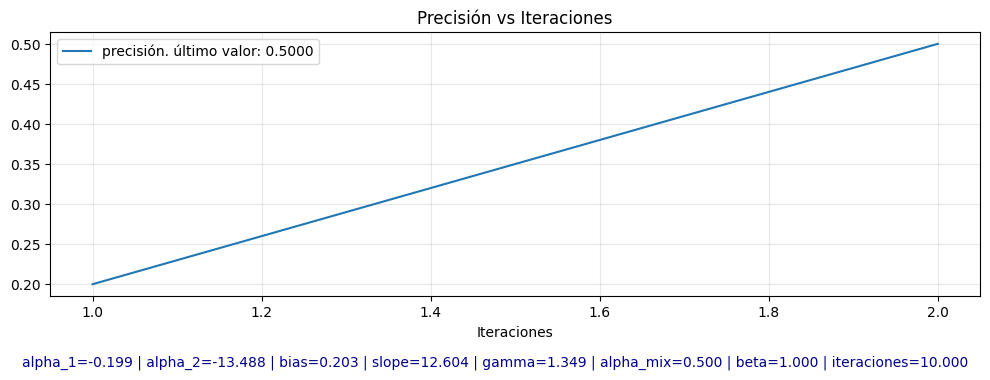

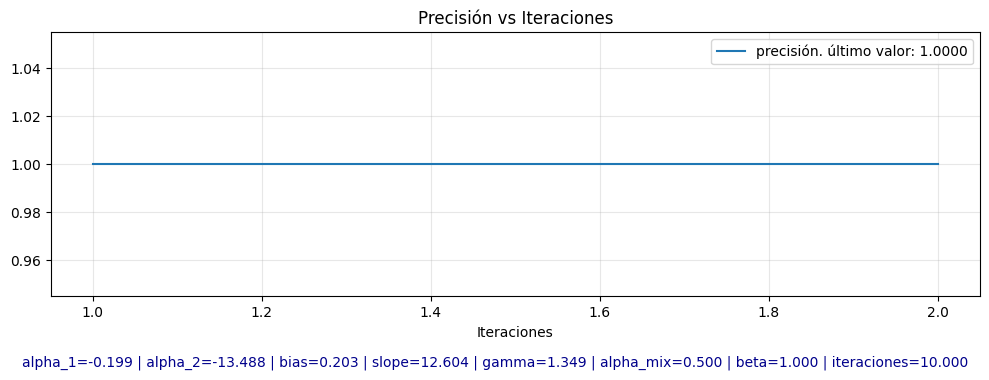

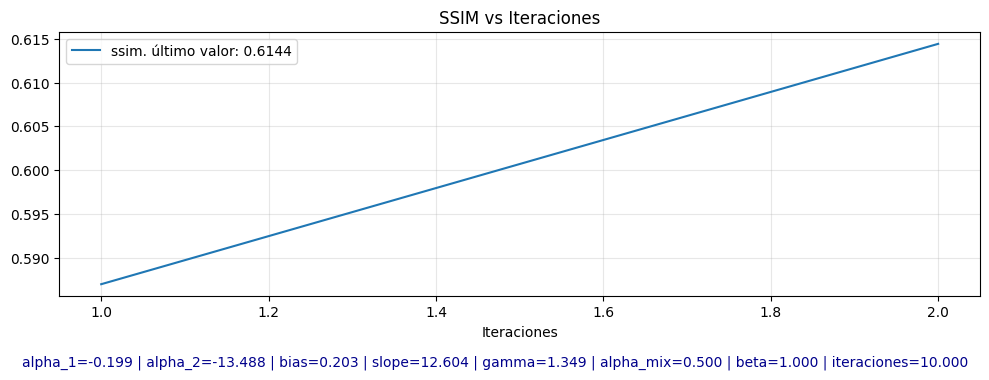

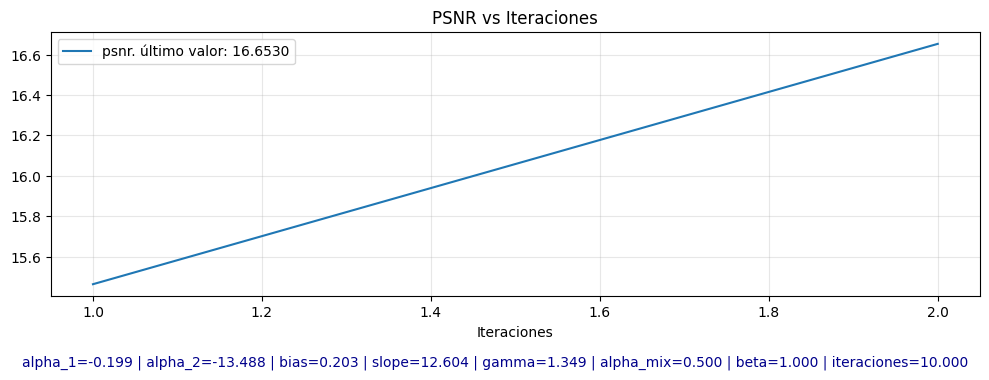


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -0.199
alpha_2     : -13.488
bias        : 0.203
slope       : 12.604
gamma       : 1.349
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.653  std:2.234
mask_bpsnr       : mean: 11.173  std:1.760
ssim             : mean: 0.614  std:0.128
acc_at_least_one : 1.000
acc_both         : 0.500



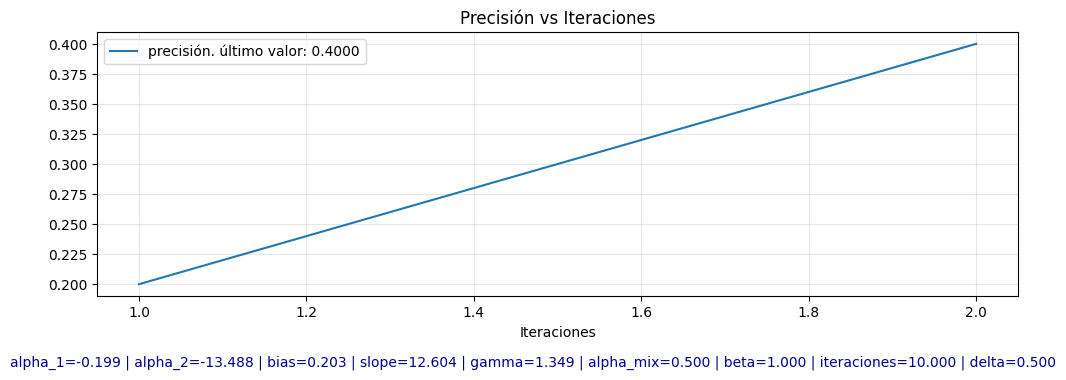

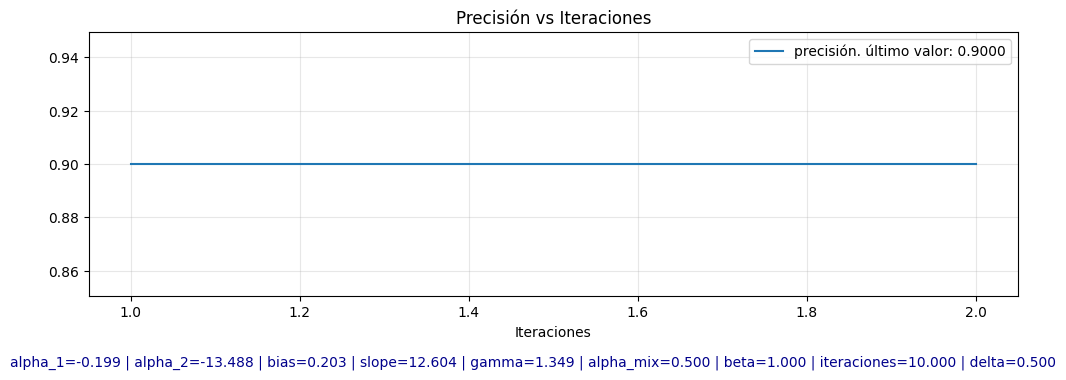

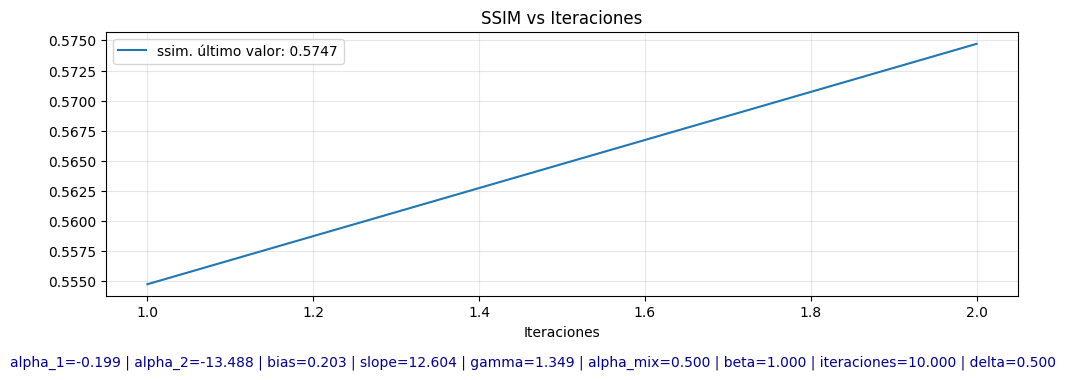

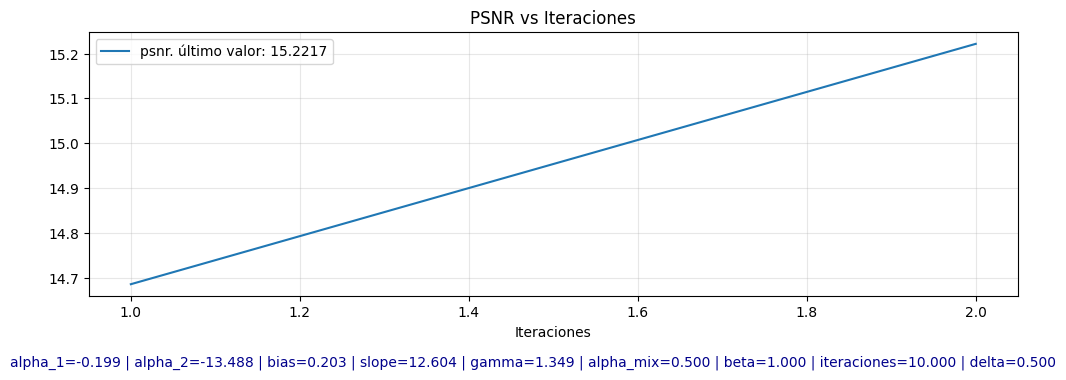


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -0.199
alpha_2     : -13.488
bias        : 0.203
slope       : 12.604
gamma       : 1.349
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.500

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.222  std:2.451
mask_bpsnr       : mean: 9.170  std:2.005
ssim             : mean: 0.575  std:0.134
acc_at_least_one : 0.900
acc_both         : 0.400



In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS =2
N_PICTURES = 10

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 256

MNIST_PARAMS={'alpha_1': -1.061219644037281, 
        'alpha_2': -5.93265175032368, 
        'bias': 0.2181251530229756, 
        'slope': 12.884957541103851, 
        'gamma': 0.3294146902334417}

FASHION_PARAMS={'alpha_1': -0.19868397094671308, 
        'alpha_2': -13.487772584723764, 
        'bias': 0.2025587756051315, 
        'slope': 12.603926712541048, 
        'gamma': 1.348637346498534}
#optimizando ssim

FASHION_PARAMS_SSIM={'alpha_1': -3.67958442342705, 
        'alpha_2': -15.077895121548808, 
        'bias': 0.20255676463340044, 
        'slope': 14.379147657210677, 
        'gamma': 1.569064516257034}


MNIST_PARAMS_SSIM={'alpha_1': -1.9353908509805846, 
                   'alpha_2': -5.702371423422697,
                     'bias': 0.25485332997650295,
                       'slope': 18.19613632092573,
                         'gamma': 1.2494901799145723}



cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]



c2 = Crop2(cvae=cvae,predictor=predictor)


metrics2 = c2.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params=FASHION_PARAMS,
    show_all_curves=True
    )



params = {**FASHION_PARAMS, 'delta': 0.5}
c3 = Crop3EstimationCorrection(cvae=cvae,predictor=predictor)


metrics3ec = c3.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params=params,
    show_all_curves=True
    )




#mejores parametros para Crop3MaskCorrection  optimizando acc_both.

#params={'gamma': 1.136128192066129, 'delta': -1.7913722978884388}

#mejores parametros para Crop3MaskCorrection  optimizando SSIM.

#params={'gamma': 0.32977989566222726, 'delta': 0.7689584803518953}

#----------------------------------------------------------------------

#mejores parametros para Crop3EstimationCorrection  optimizando acc_both.
#params={'gamma': 1.265852455556597, 'delta': 0.3429787390624981}

#mejores parametros para Crop3EstimationCorrection  optimizando SSIM.
#params={'gamma': 1.5420520651370637, 'delta': 0.4771720136717561}





Usando fashion como dataset
Run 1/20


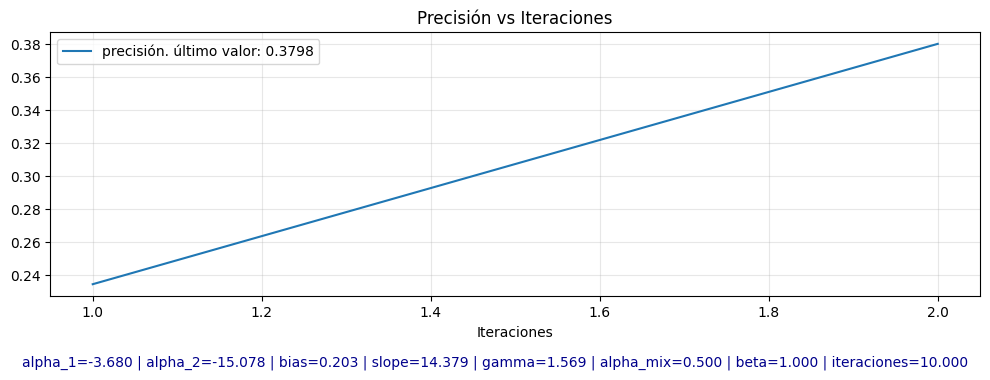

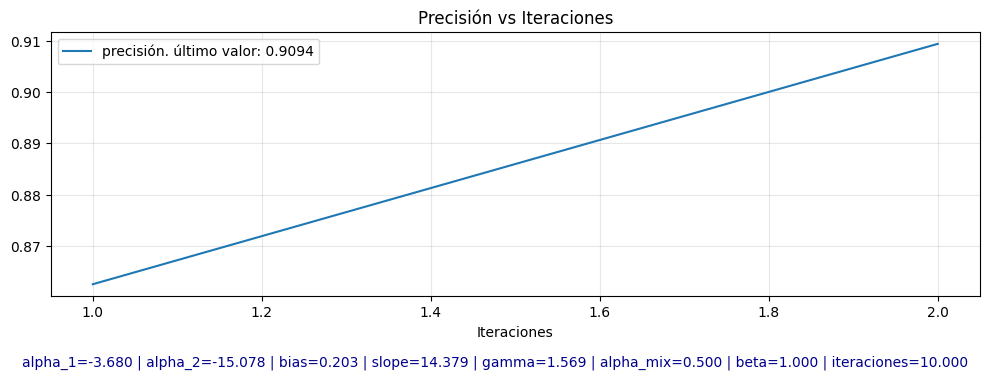

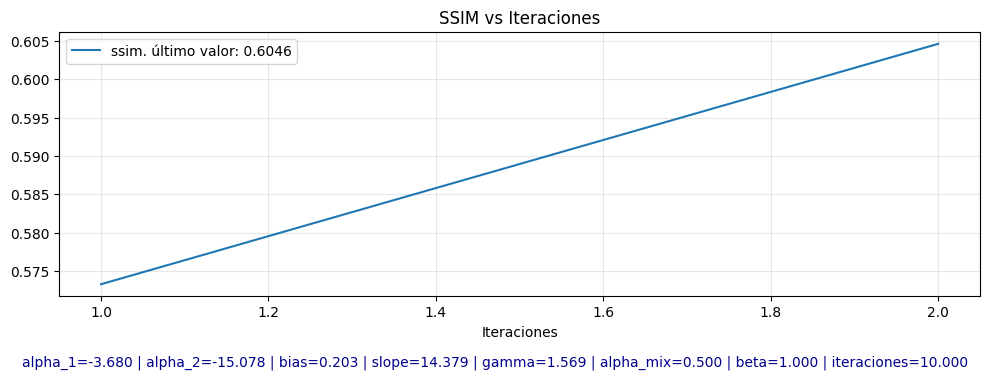

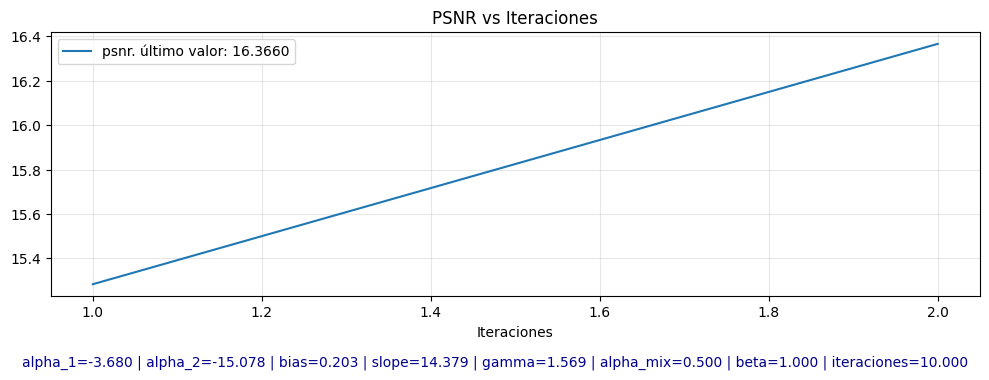


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.366  std:1.844
mask_bpsnr       : mean: 11.597  std:1.641
ssim             : mean: 0.605  std:0.087
acc_at_least_one : 0.909
acc_both         : 0.380



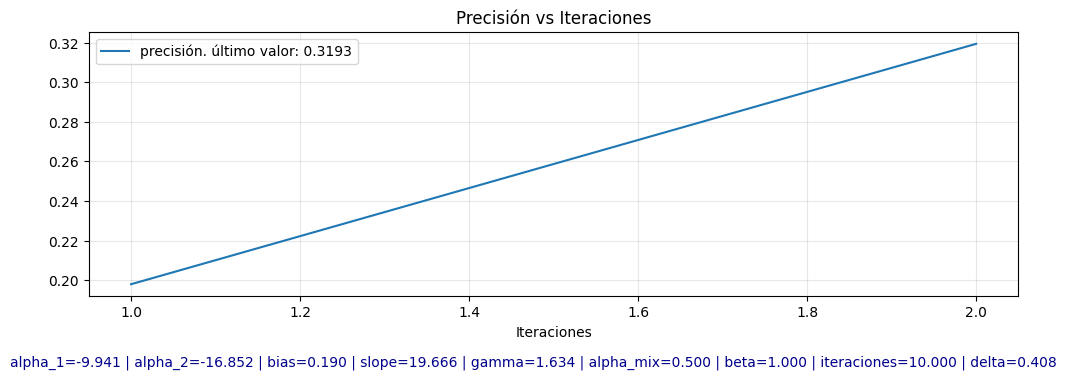

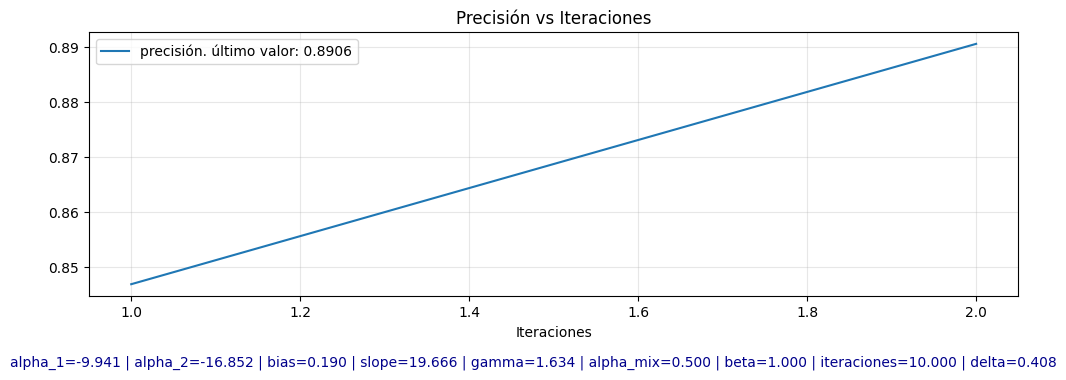

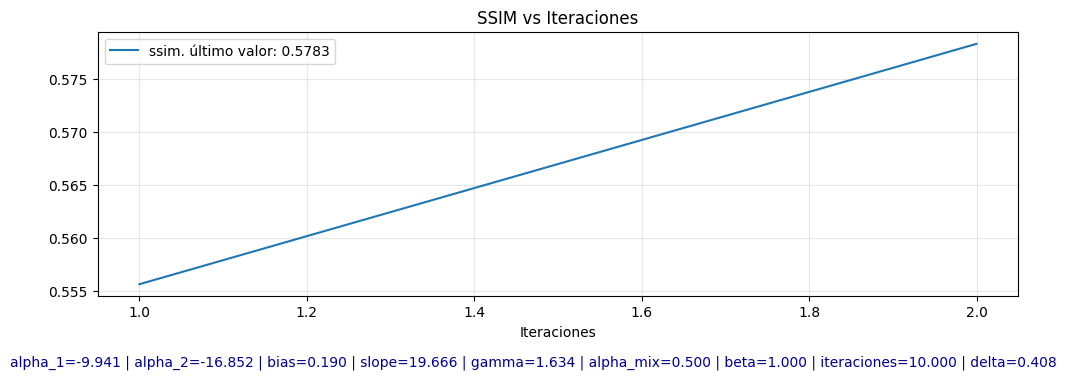

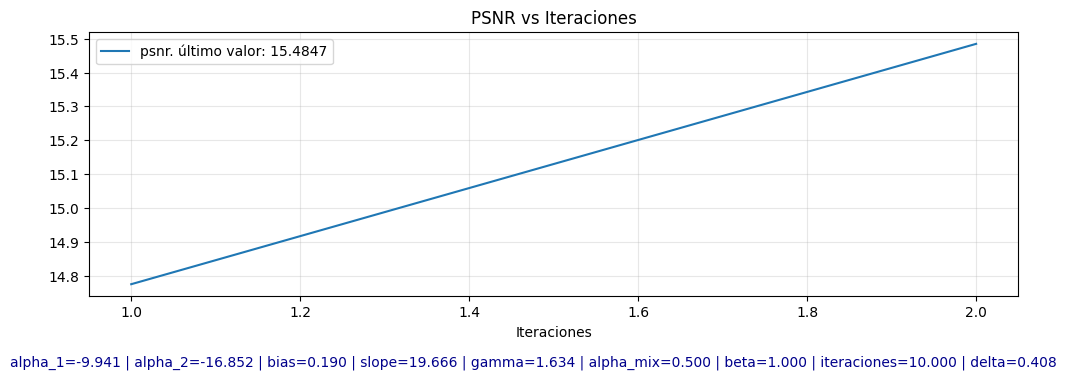


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.485  std:2.004
mask_bpsnr       : mean: 9.705  std:1.571
ssim             : mean: 0.578  std:0.089
acc_at_least_one : 0.891
acc_both         : 0.319

Run 2/20


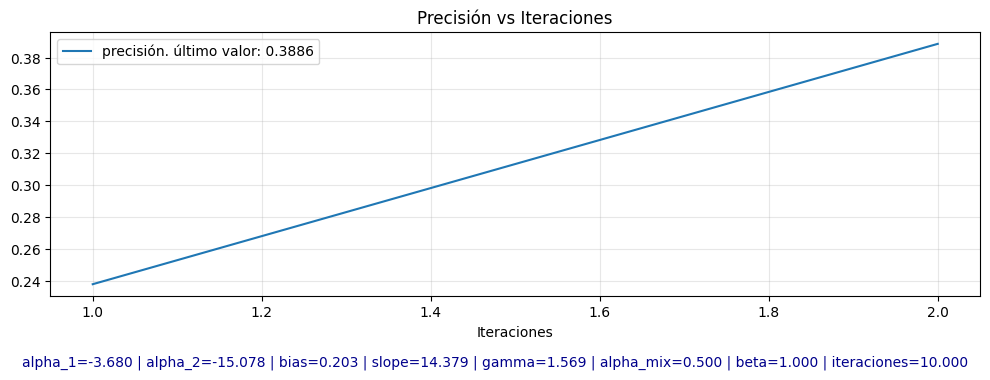

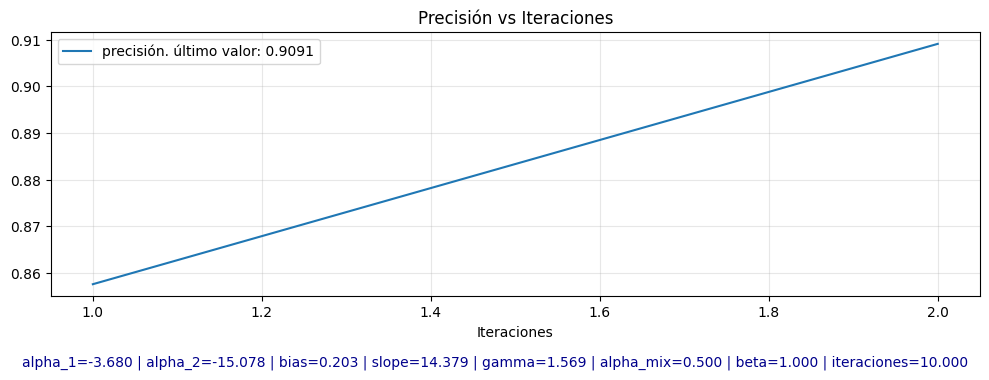

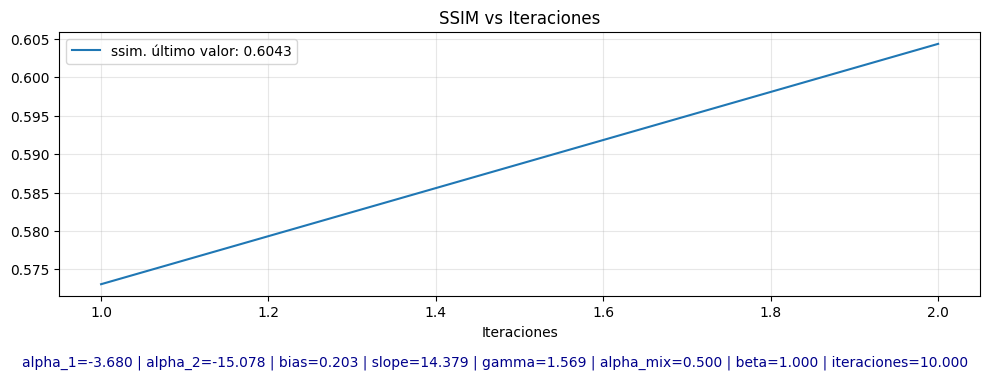

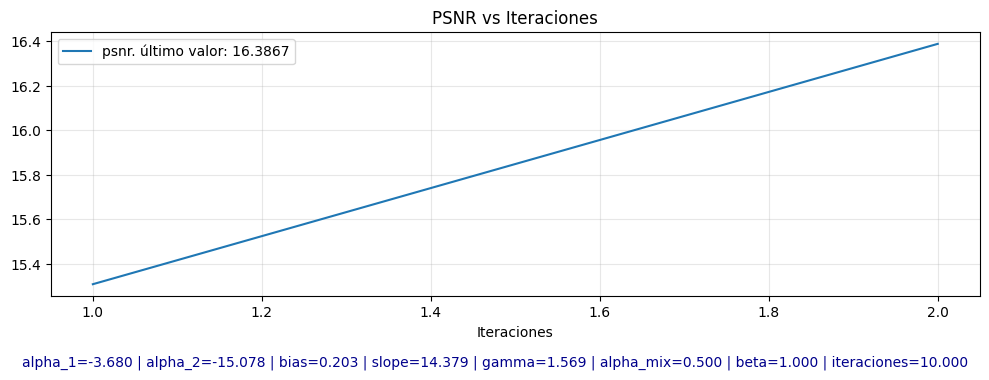


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.387  std:1.868
mask_bpsnr       : mean: 11.610  std:1.636
ssim             : mean: 0.604  std:0.088
acc_at_least_one : 0.909
acc_both         : 0.389



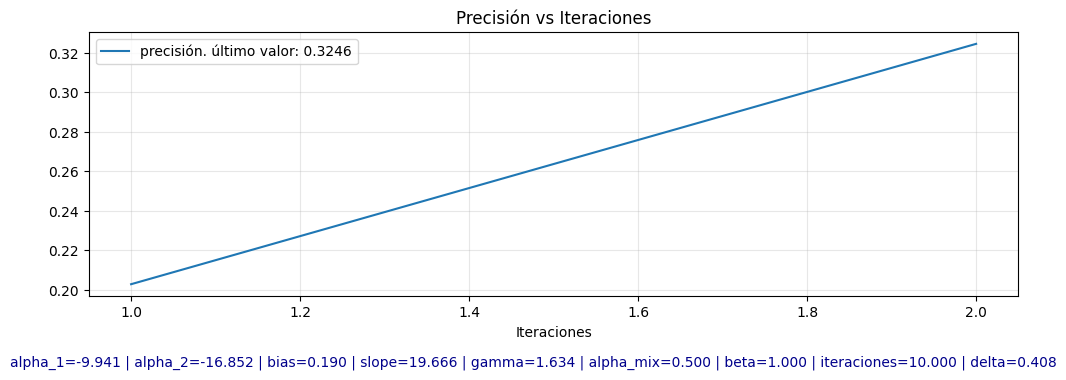

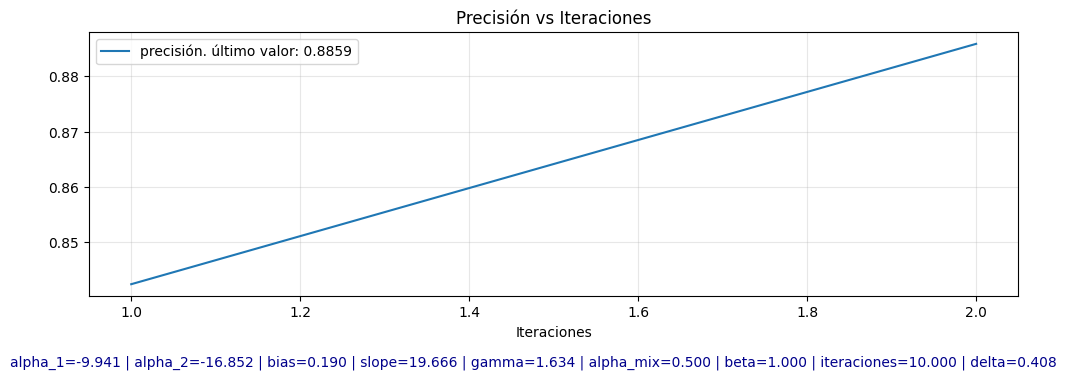

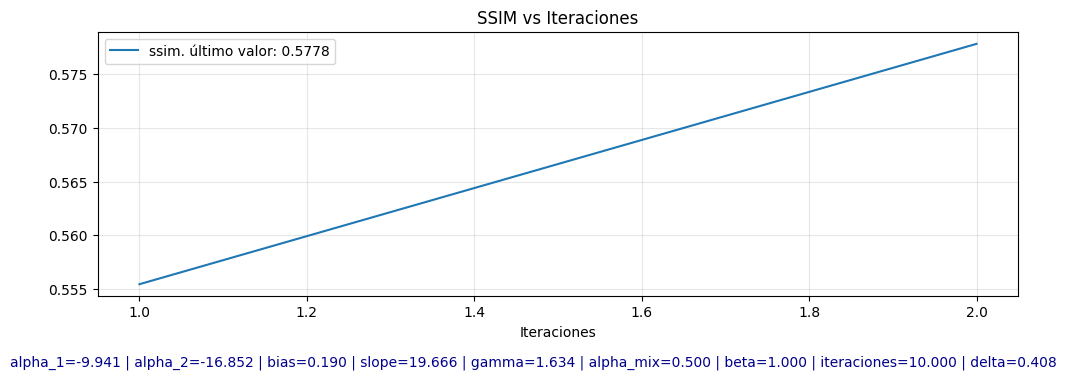

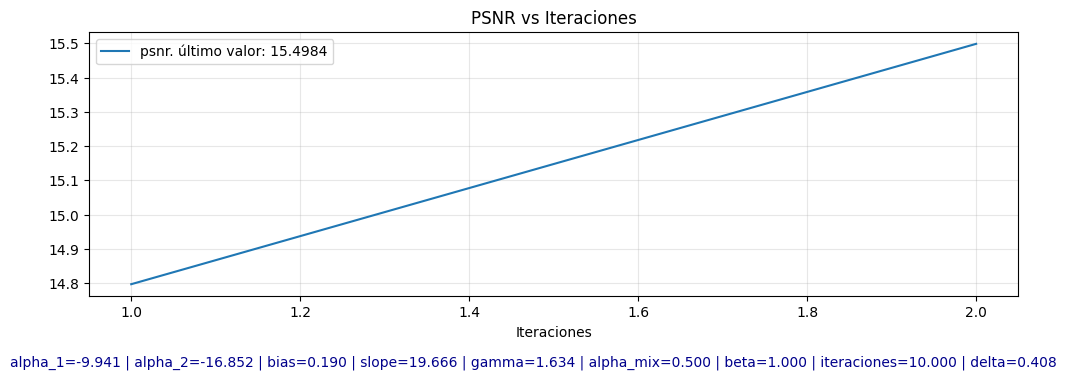


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.498  std:2.027
mask_bpsnr       : mean: 9.721  std:1.581
ssim             : mean: 0.578  std:0.090
acc_at_least_one : 0.886
acc_both         : 0.325

Run 3/20


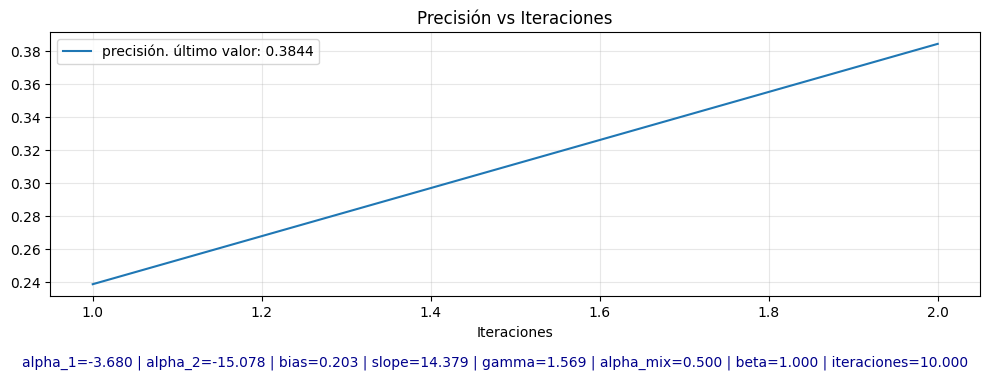

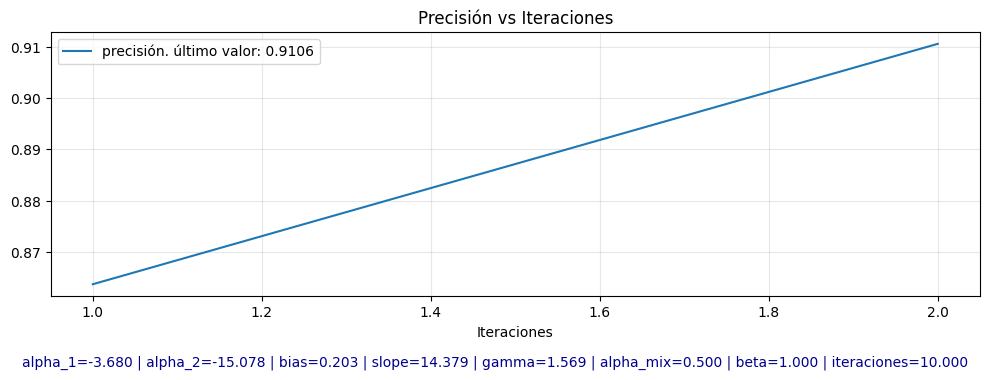

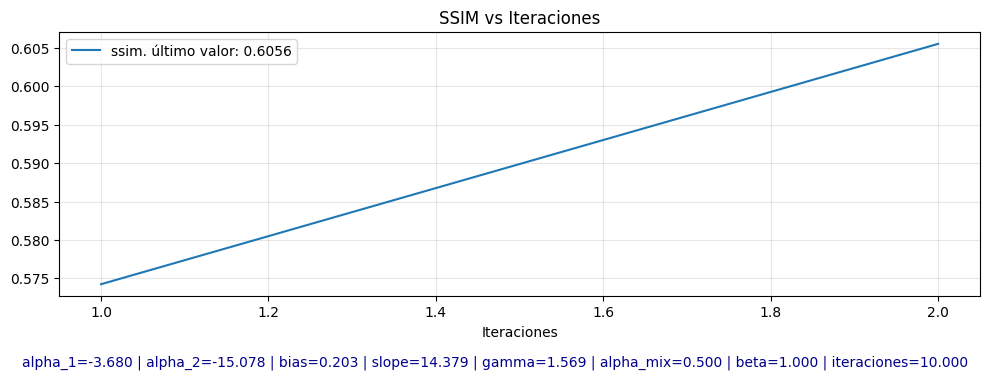

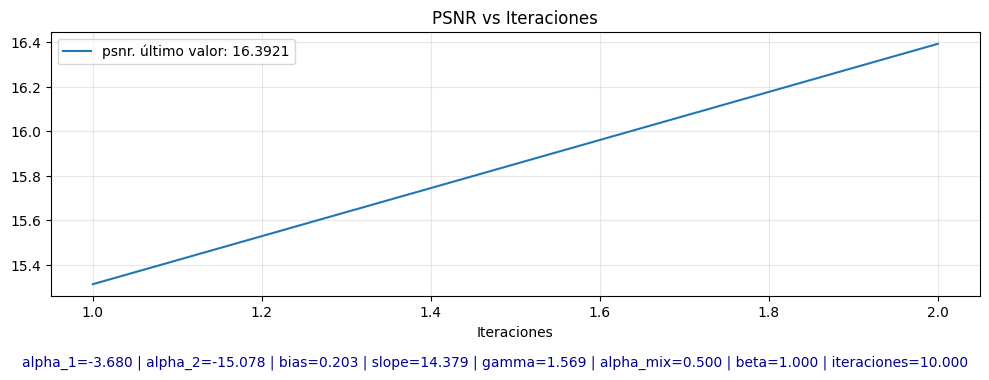


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.392  std:1.869
mask_bpsnr       : mean: 11.604  std:1.647
ssim             : mean: 0.606  std:0.088
acc_at_least_one : 0.911
acc_both         : 0.384



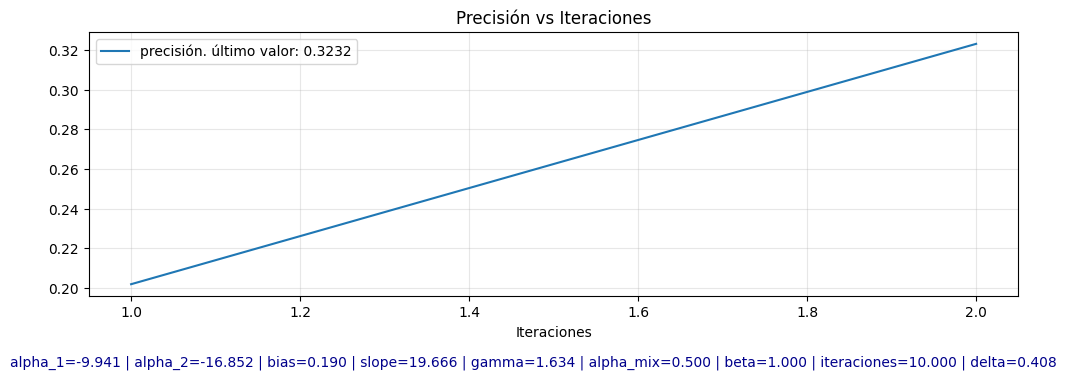

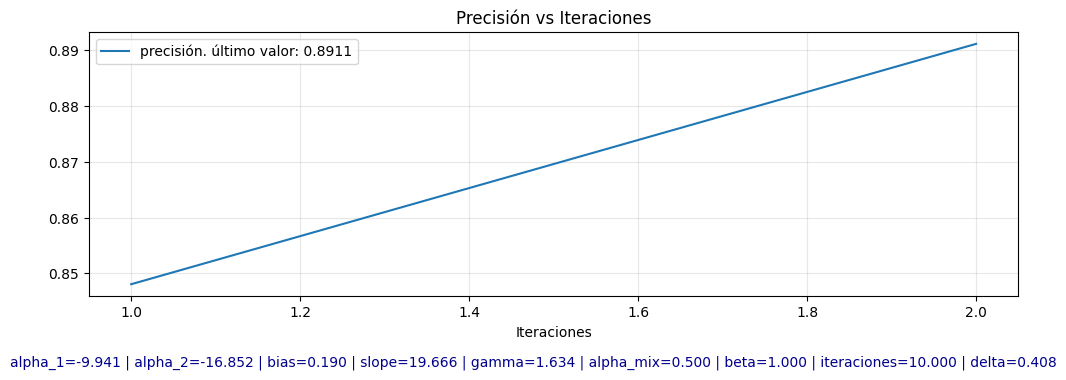

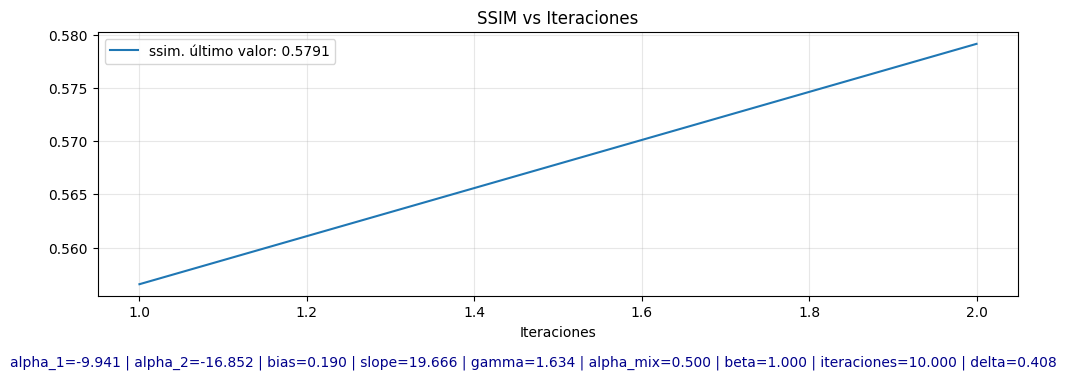

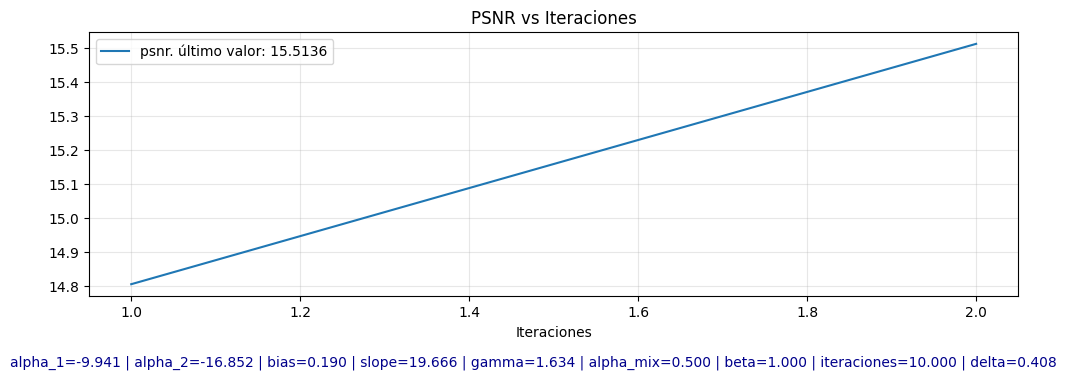


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.514  std:2.026
mask_bpsnr       : mean: 9.723  std:1.603
ssim             : mean: 0.579  std:0.090
acc_at_least_one : 0.891
acc_both         : 0.323

Run 4/20


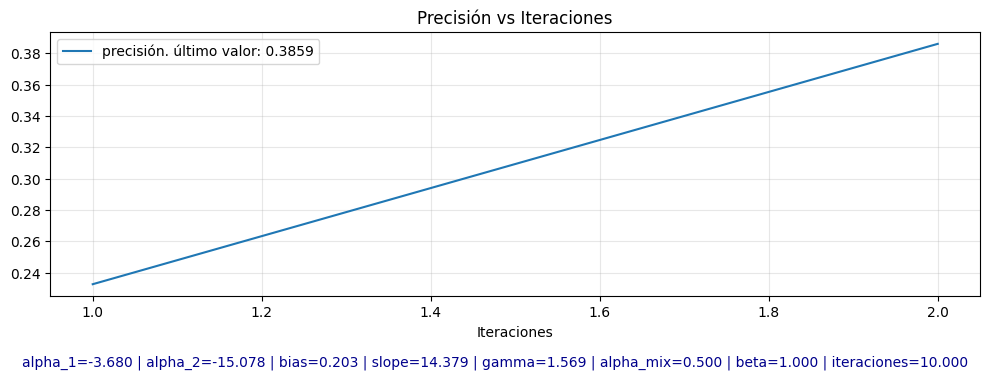

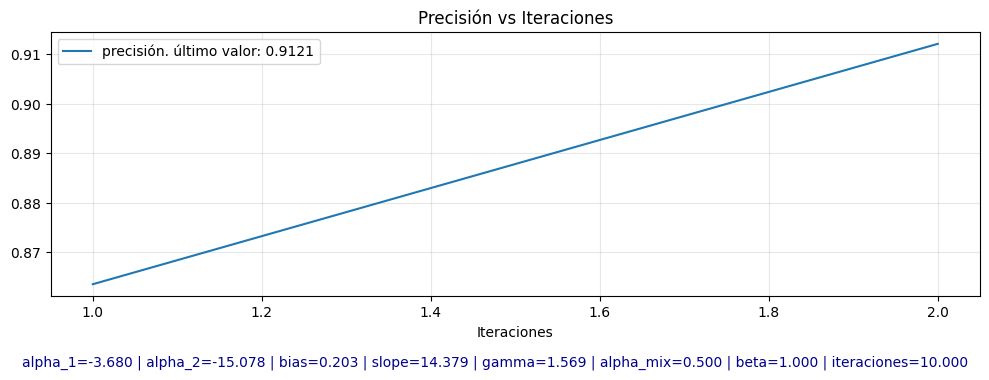

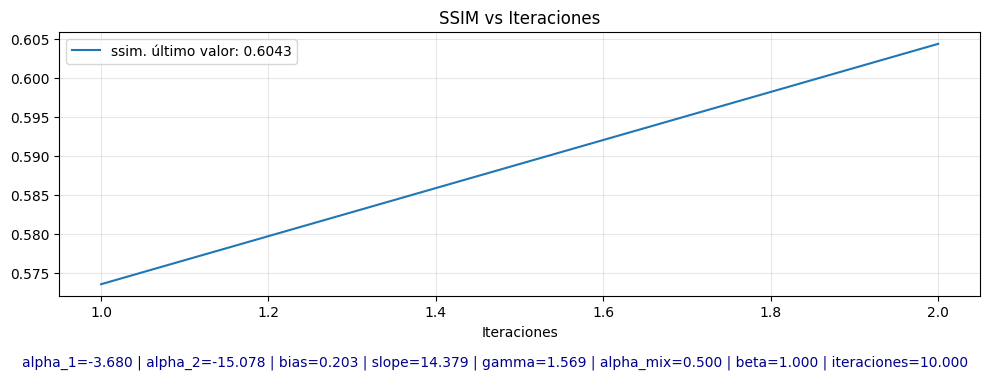

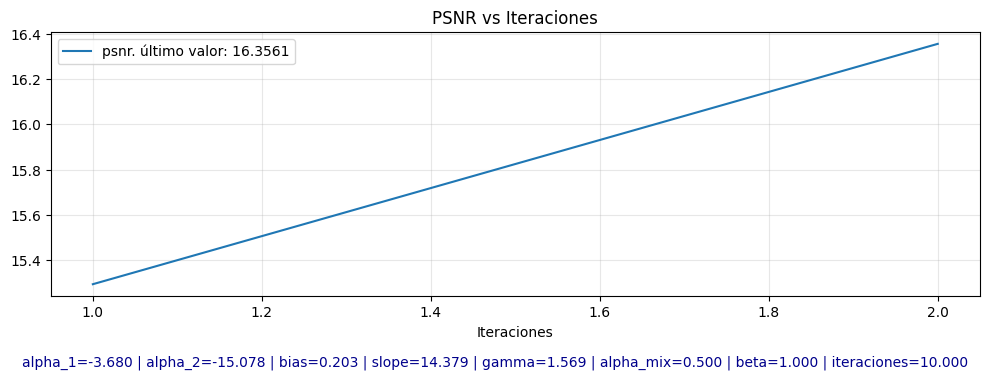


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.356  std:1.863
mask_bpsnr       : mean: 11.599  std:1.639
ssim             : mean: 0.604  std:0.086
acc_at_least_one : 0.912
acc_both         : 0.386



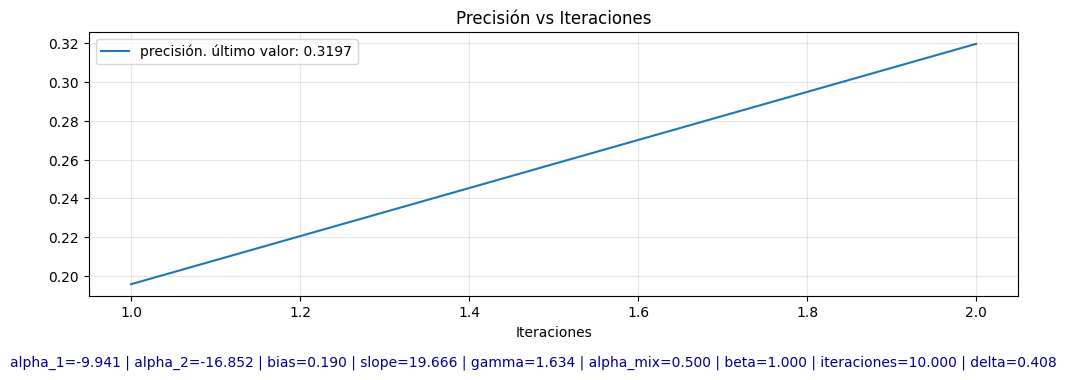

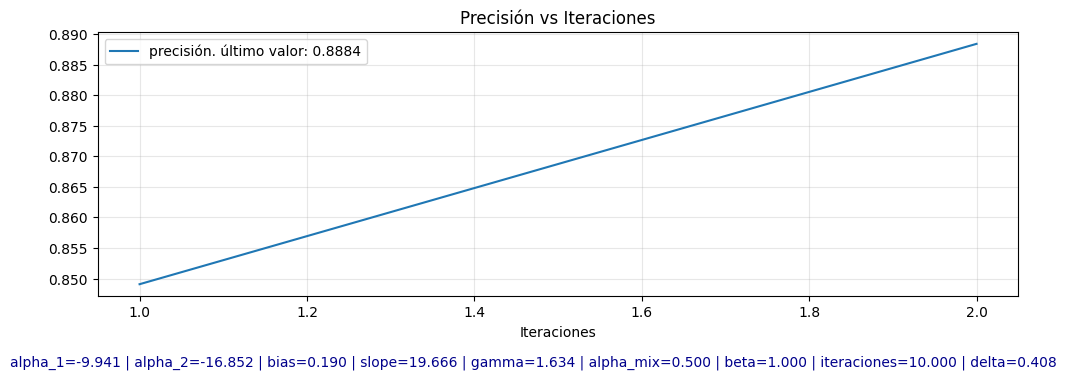

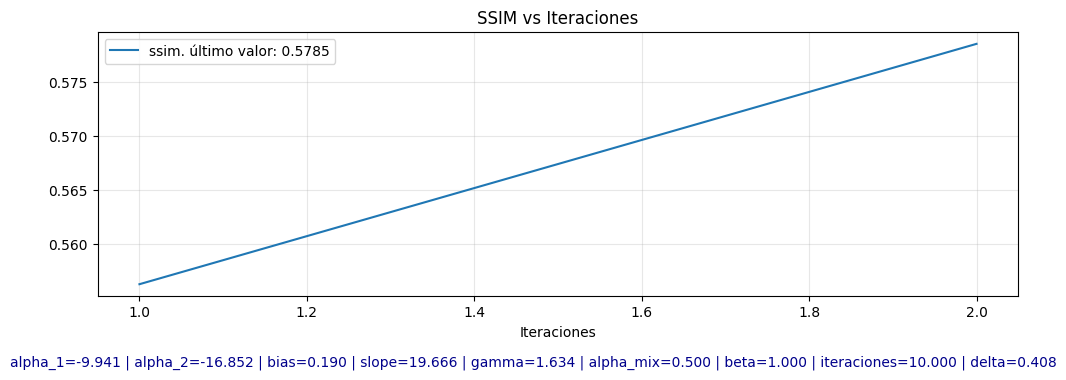

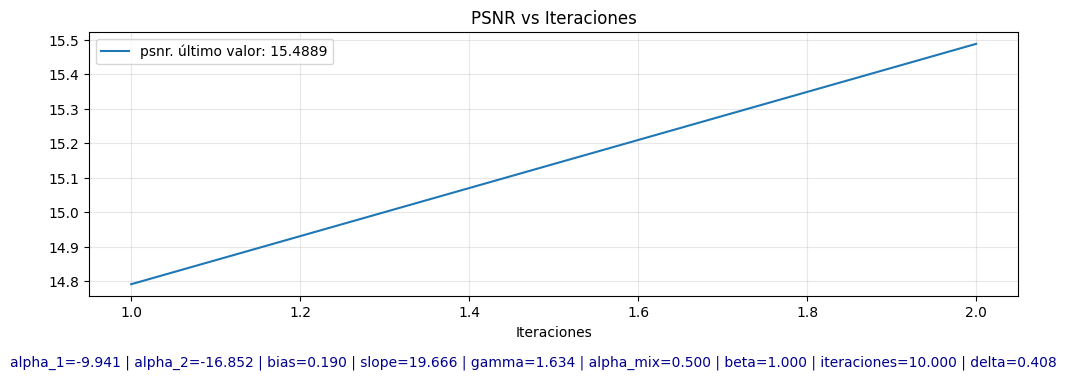


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.489  std:2.016
mask_bpsnr       : mean: 9.720  std:1.589
ssim             : mean: 0.579  std:0.089
acc_at_least_one : 0.888
acc_both         : 0.320

Run 5/20


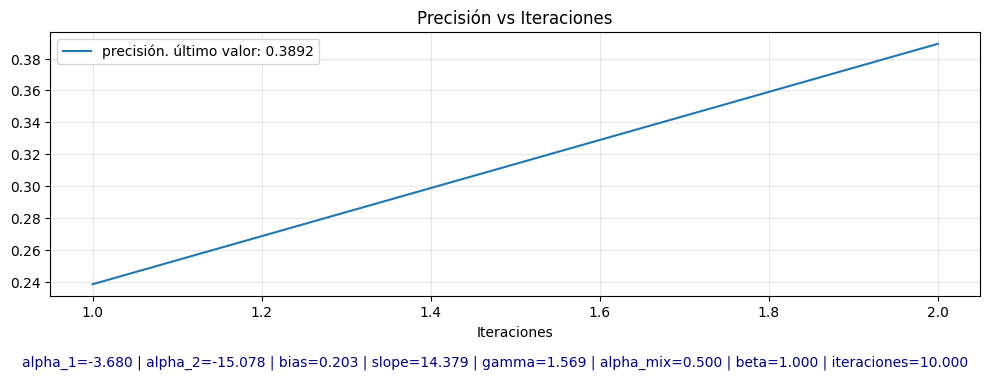

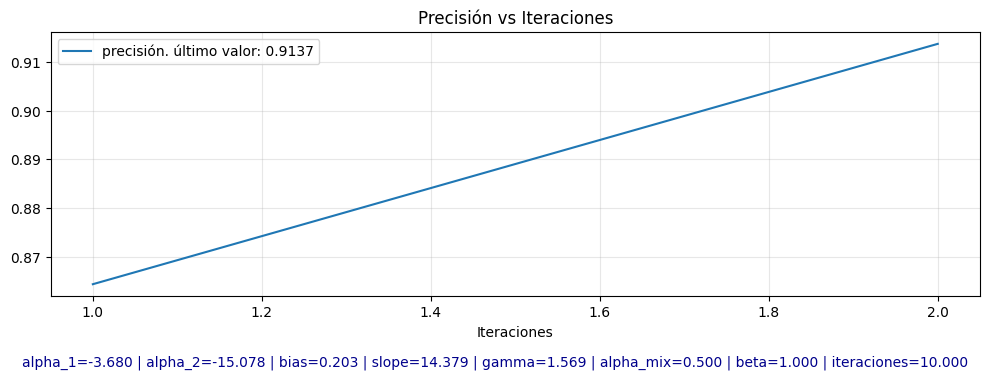

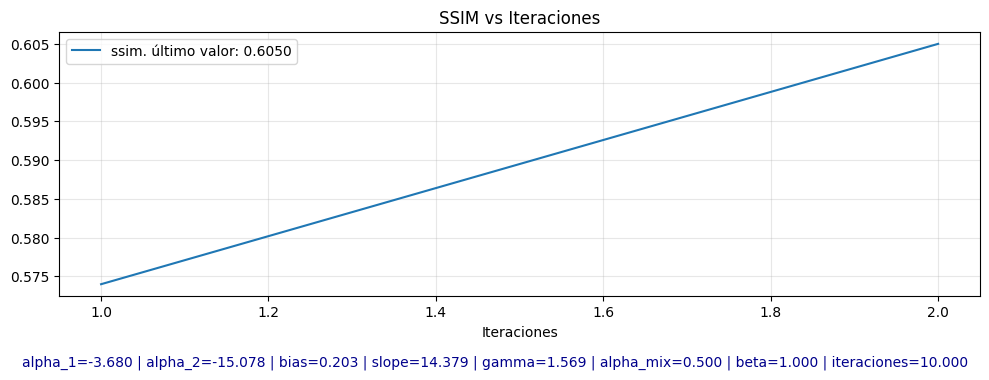

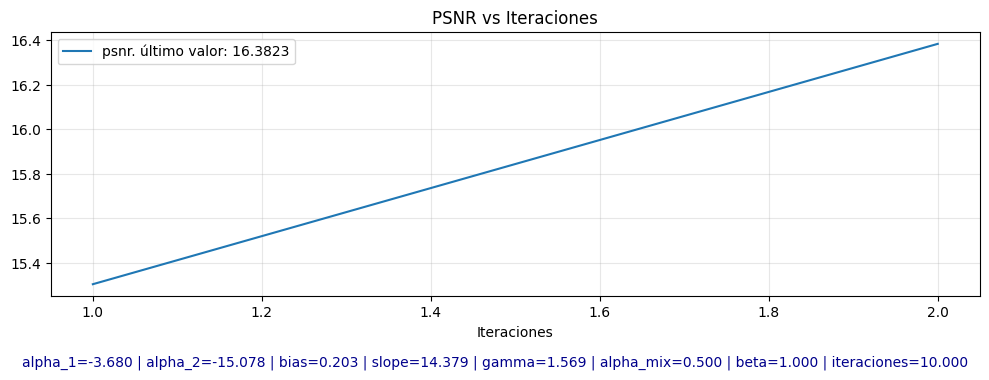


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.382  std:1.844
mask_bpsnr       : mean: 11.591  std:1.625
ssim             : mean: 0.605  std:0.087
acc_at_least_one : 0.914
acc_both         : 0.389



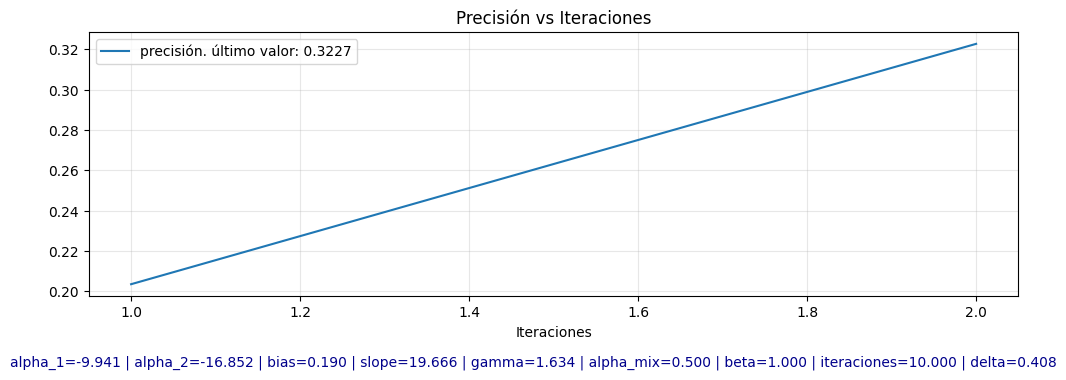

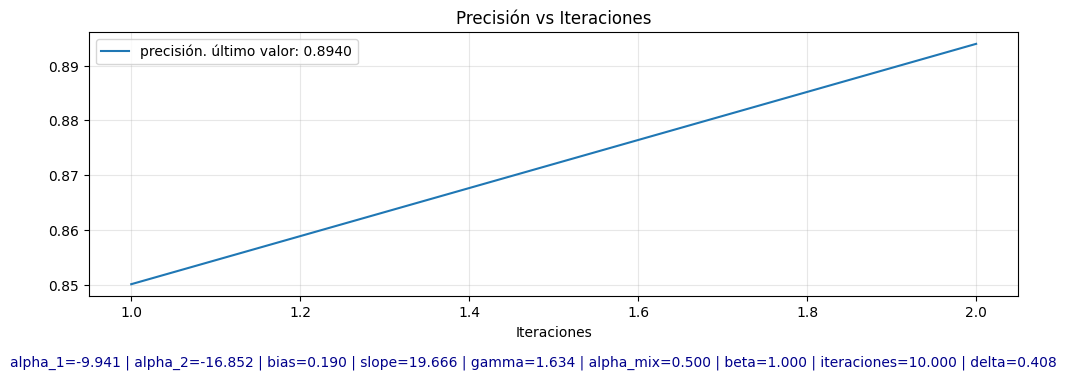

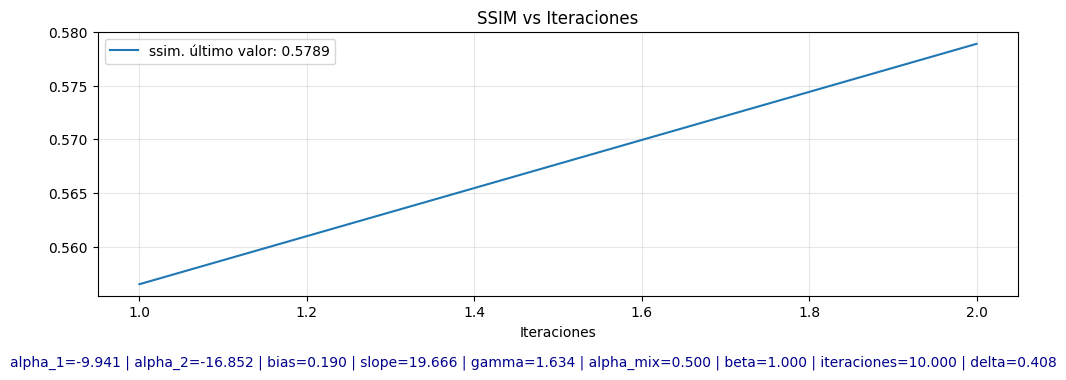

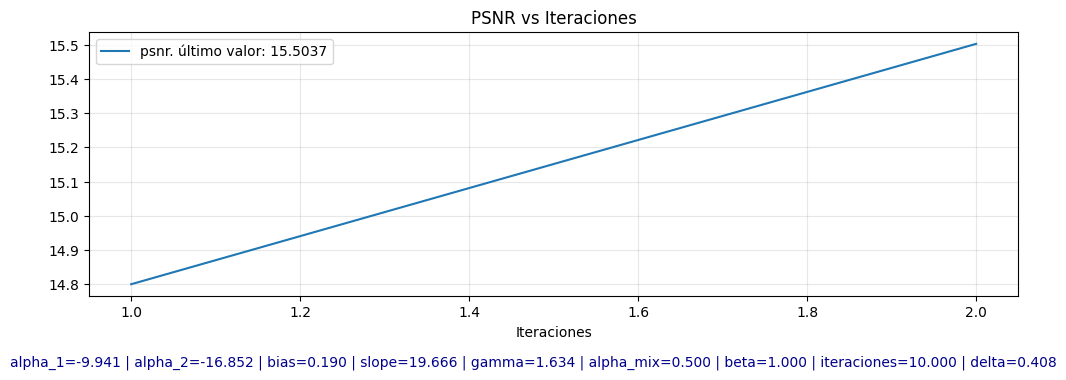


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.504  std:2.008
mask_bpsnr       : mean: 9.720  std:1.589
ssim             : mean: 0.579  std:0.090
acc_at_least_one : 0.894
acc_both         : 0.323

Run 6/20


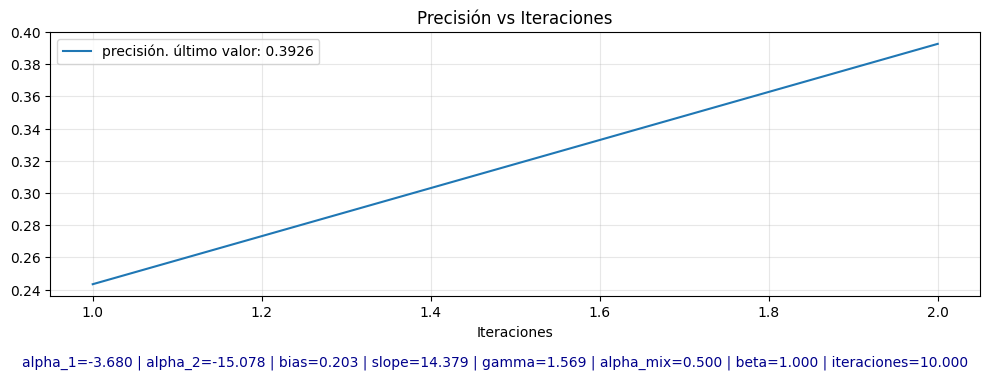

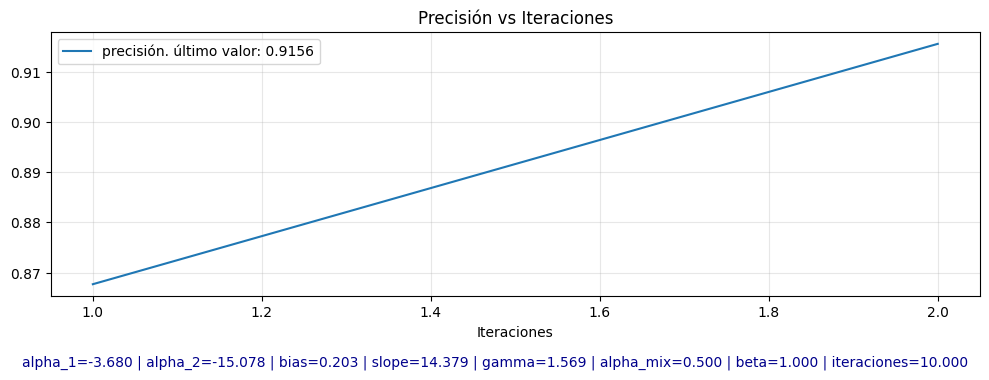

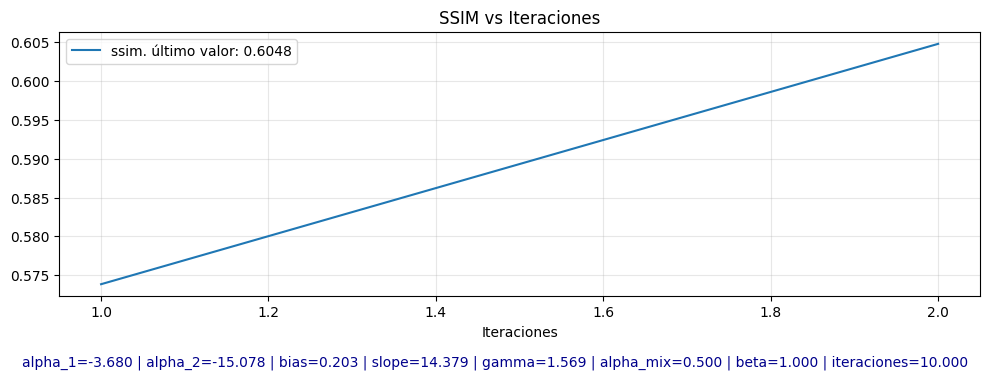

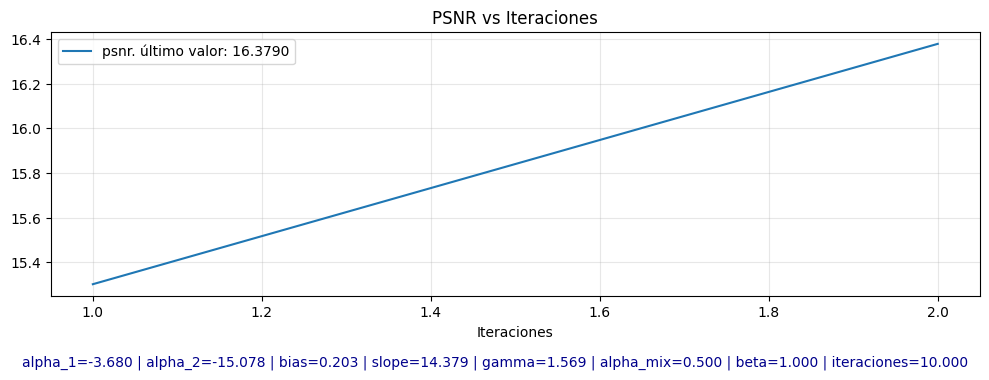


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.379  std:1.841
mask_bpsnr       : mean: 11.597  std:1.629
ssim             : mean: 0.605  std:0.087
acc_at_least_one : 0.916
acc_both         : 0.393



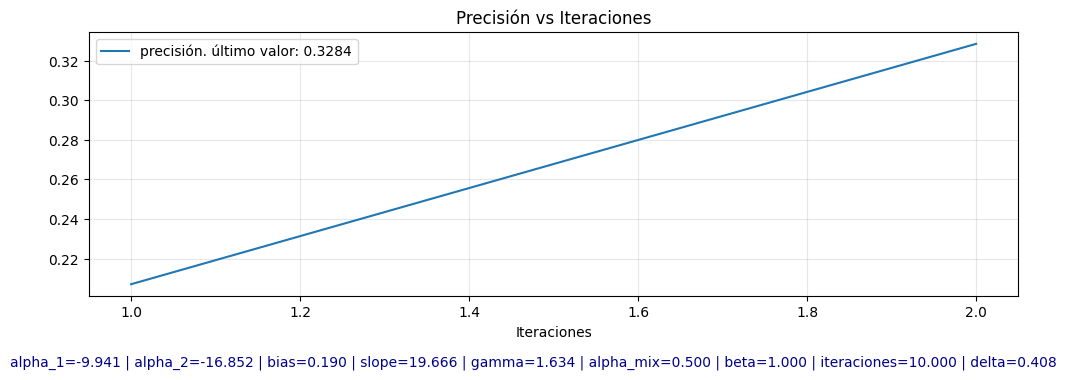

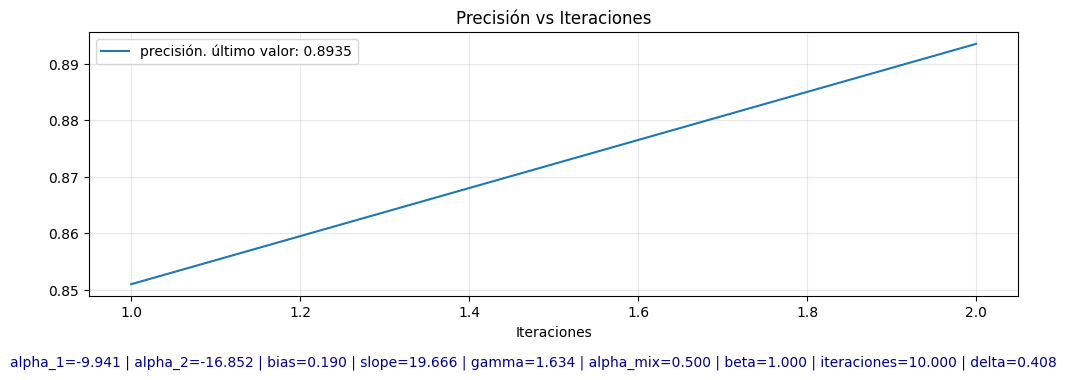

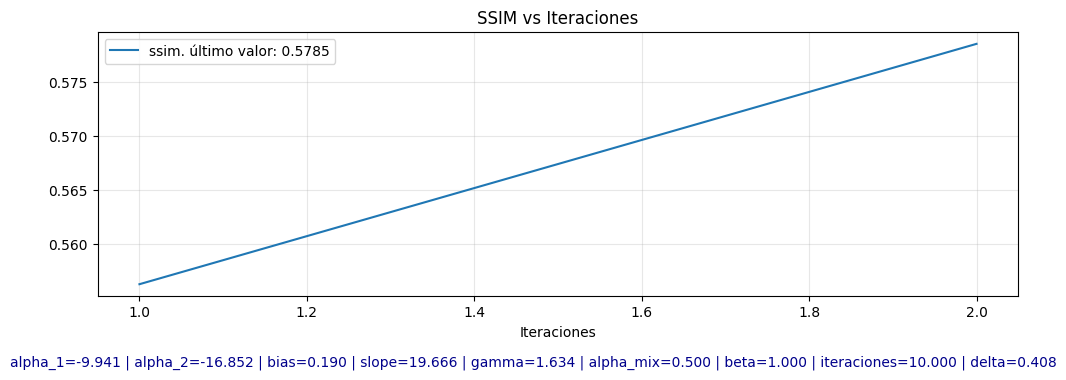

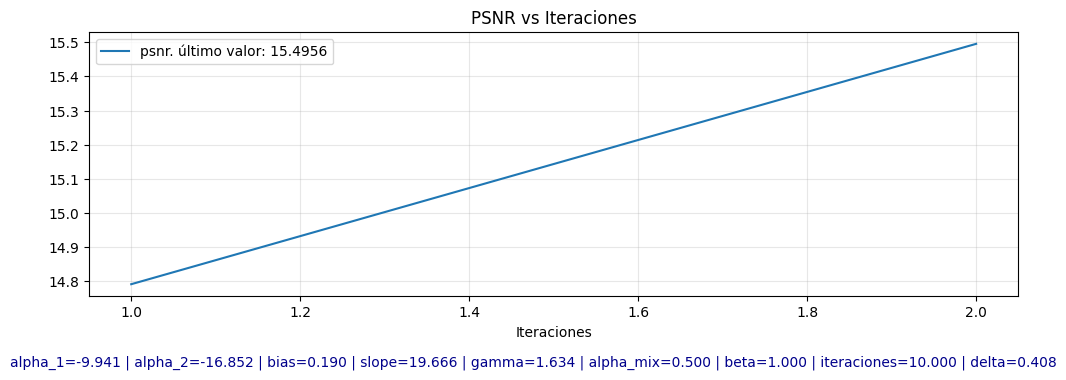


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.496  std:2.011
mask_bpsnr       : mean: 9.712  std:1.584
ssim             : mean: 0.579  std:0.091
acc_at_least_one : 0.893
acc_both         : 0.328

Run 7/20


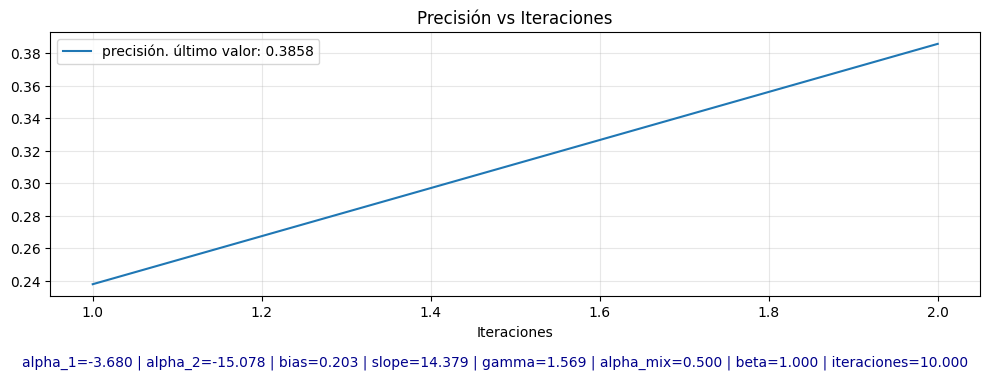

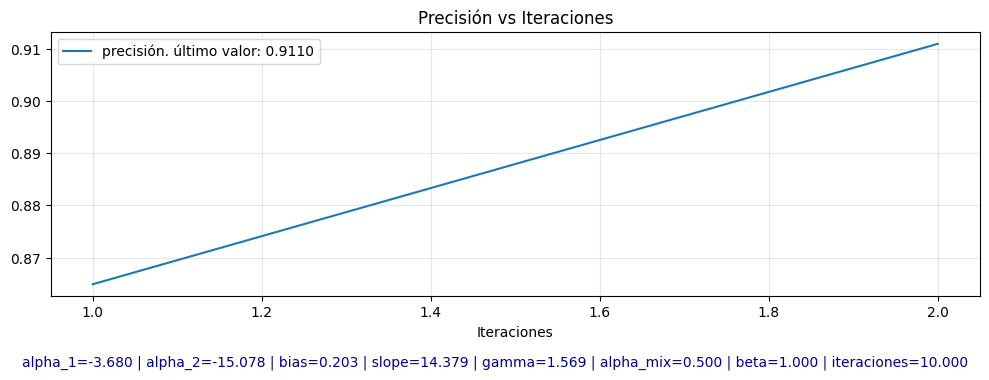

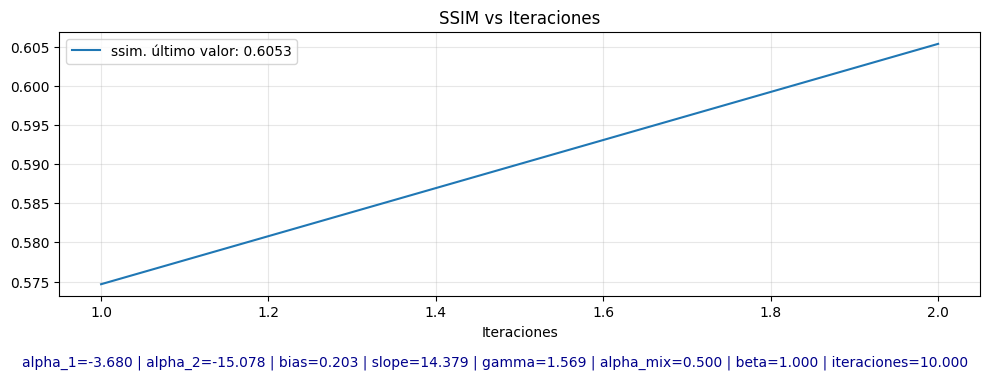

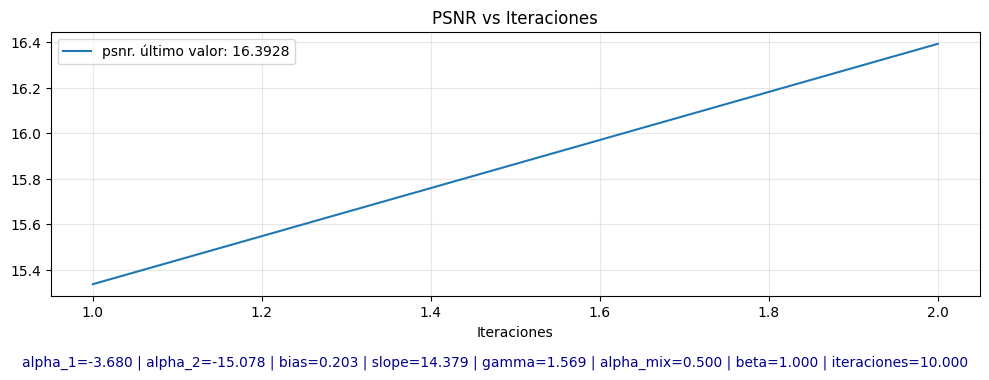


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.393  std:1.858
mask_bpsnr       : mean: 11.596  std:1.623
ssim             : mean: 0.605  std:0.088
acc_at_least_one : 0.911
acc_both         : 0.386



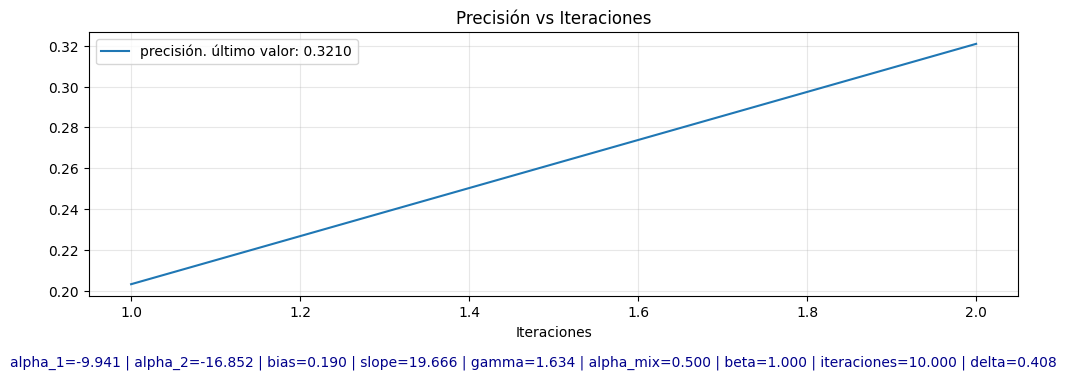

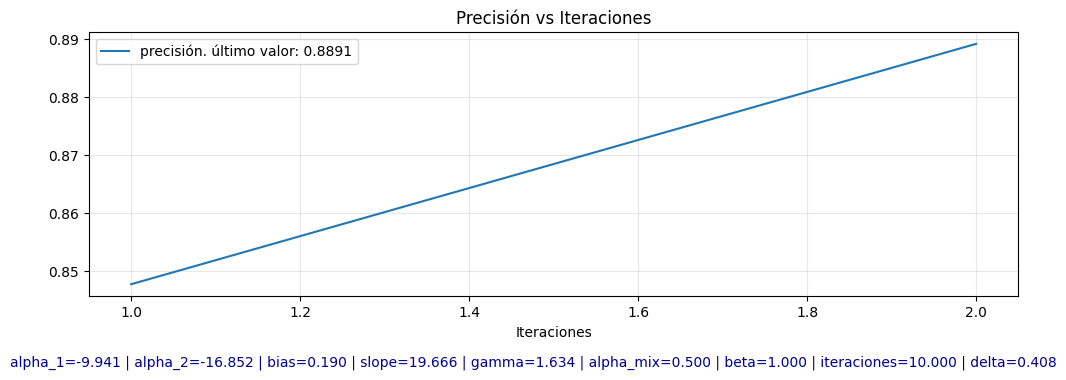

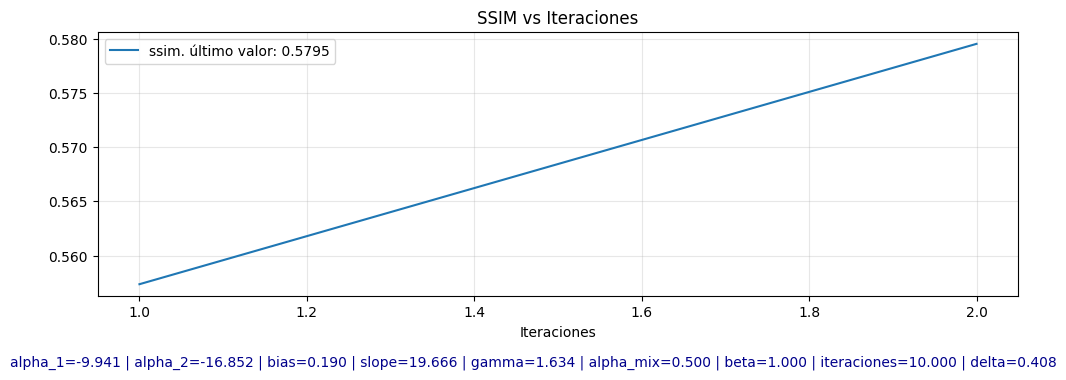

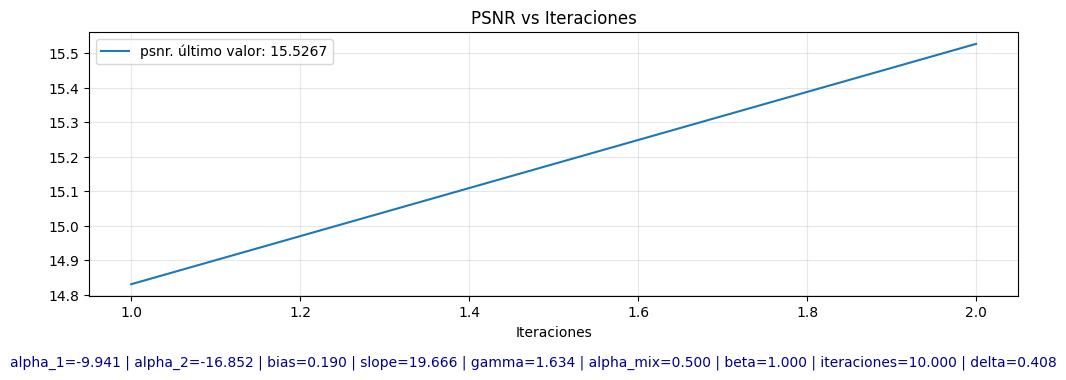


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.527  std:2.023
mask_bpsnr       : mean: 9.723  std:1.585
ssim             : mean: 0.580  std:0.090
acc_at_least_one : 0.889
acc_both         : 0.321

Run 8/20


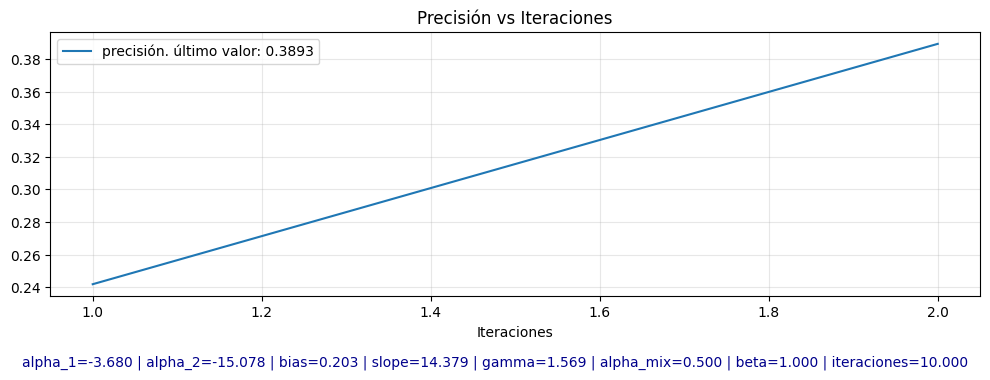

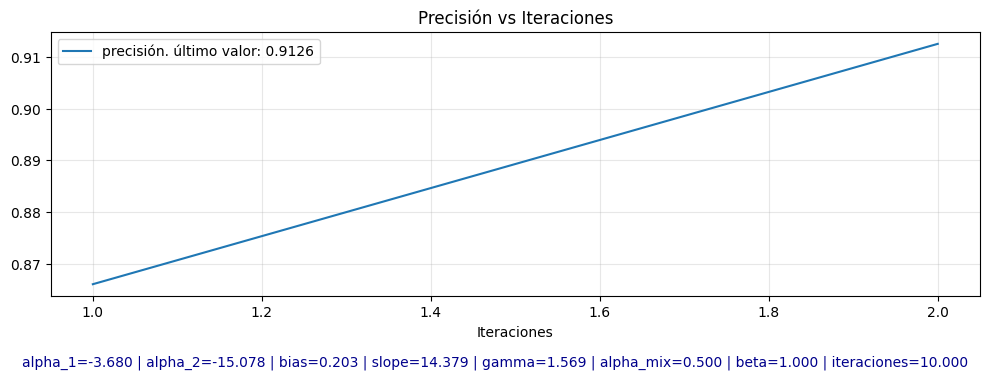

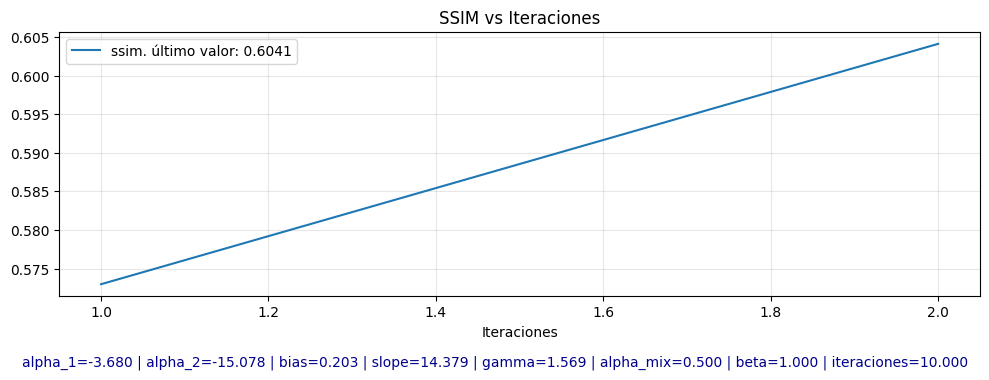

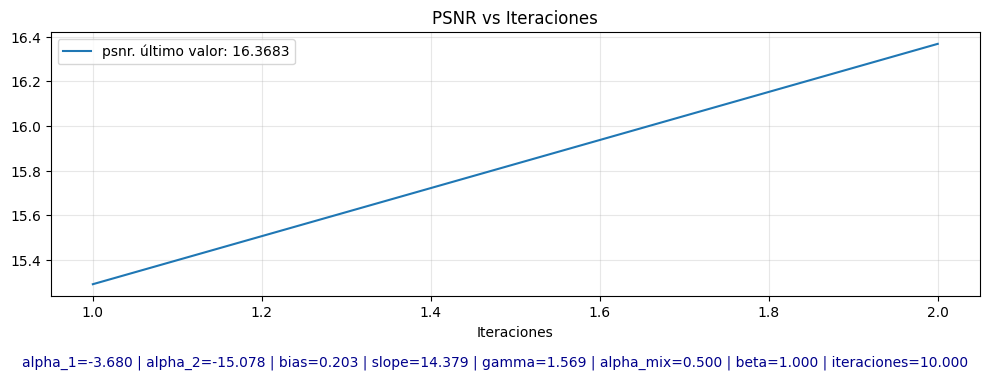


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.368  std:1.843
mask_bpsnr       : mean: 11.588  std:1.618
ssim             : mean: 0.604  std:0.087
acc_at_least_one : 0.913
acc_both         : 0.389



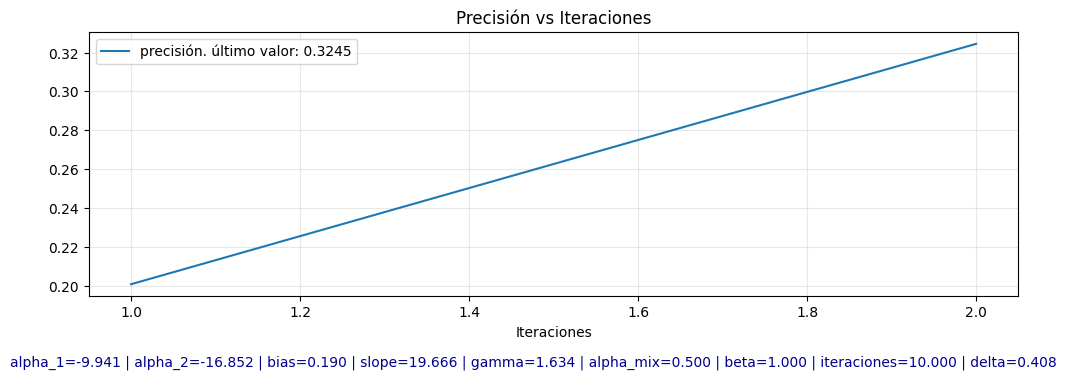

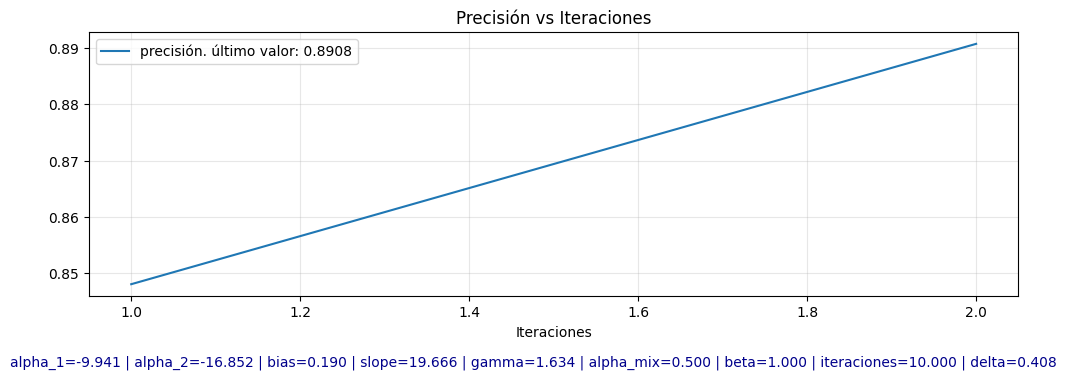

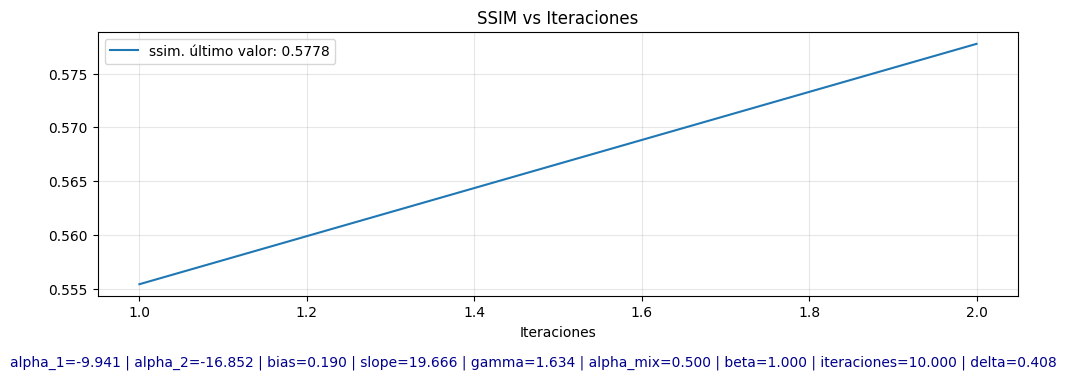

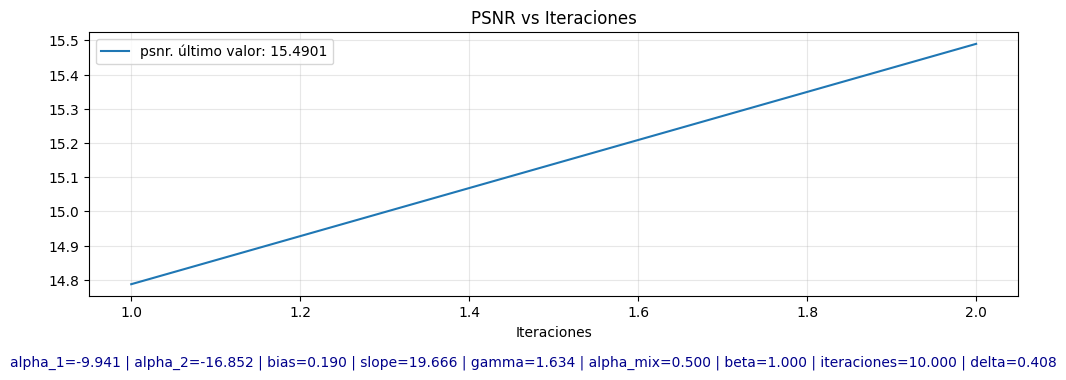


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.490  std:2.003
mask_bpsnr       : mean: 9.720  std:1.566
ssim             : mean: 0.578  std:0.090
acc_at_least_one : 0.891
acc_both         : 0.325

Run 9/20


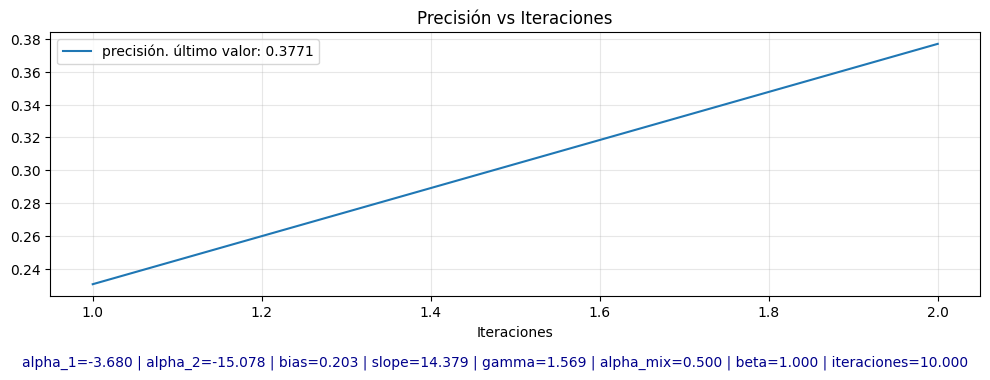

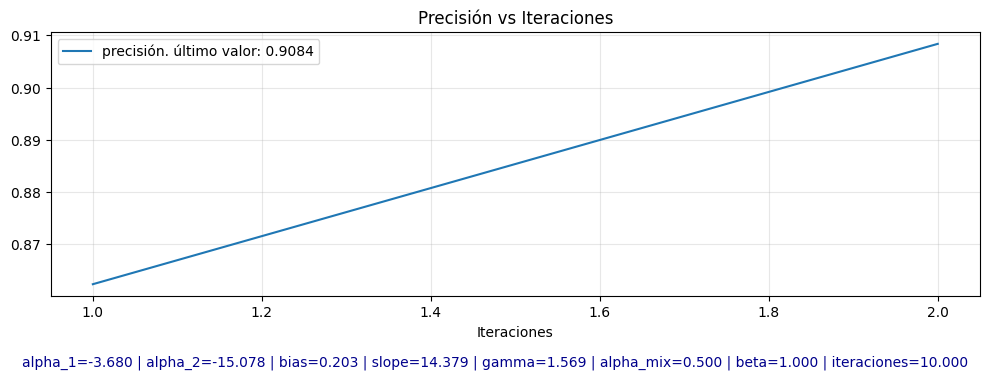

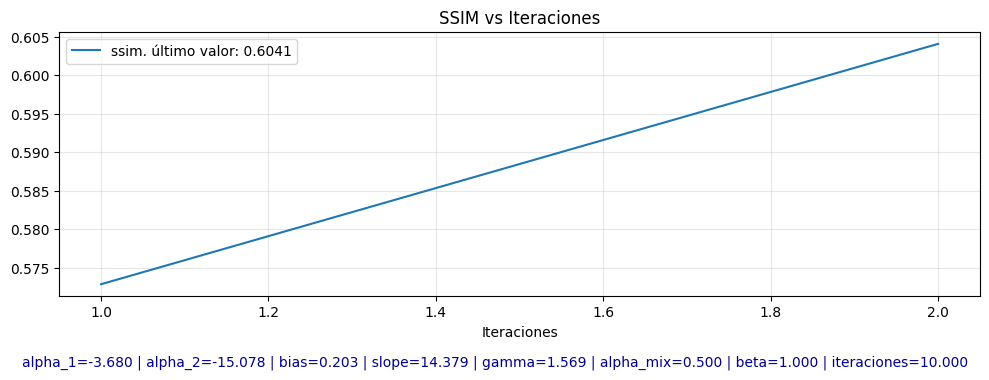

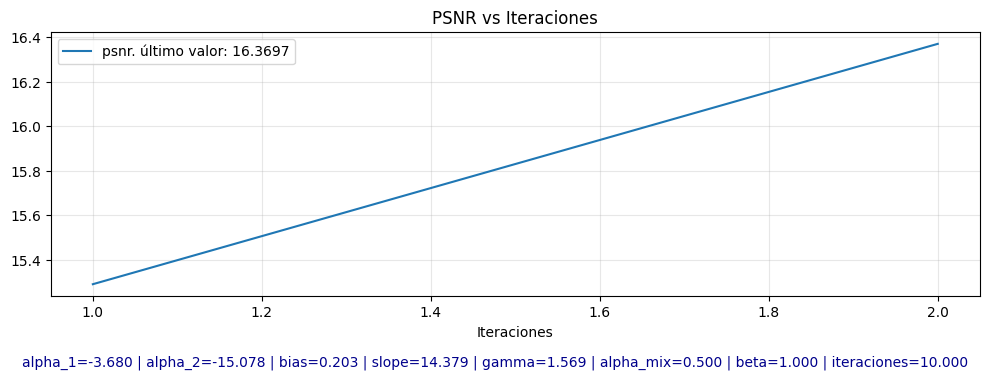


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.370  std:1.842
mask_bpsnr       : mean: 11.591  std:1.632
ssim             : mean: 0.604  std:0.086
acc_at_least_one : 0.908
acc_both         : 0.377



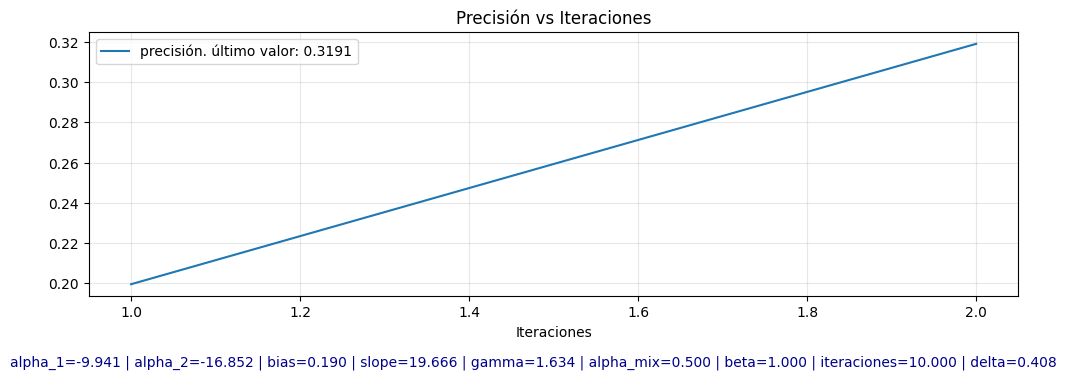

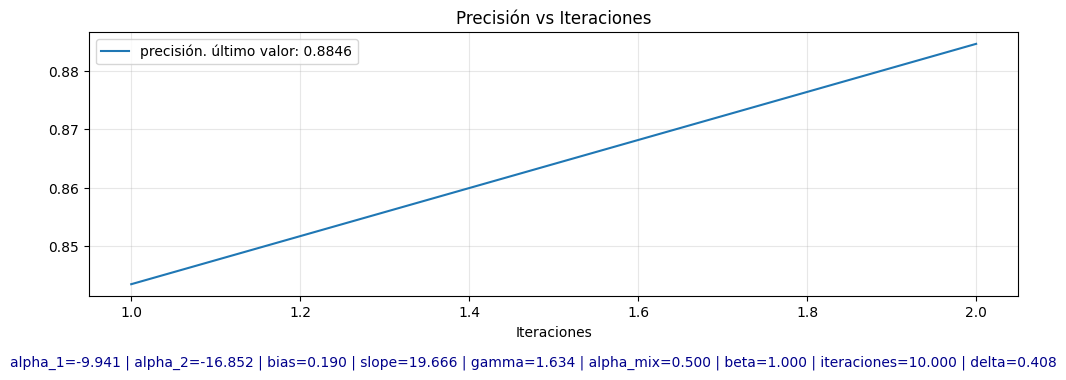

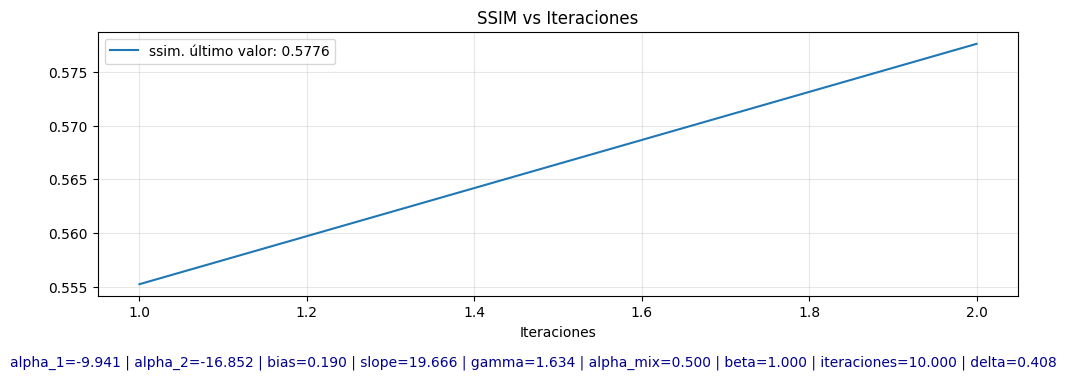

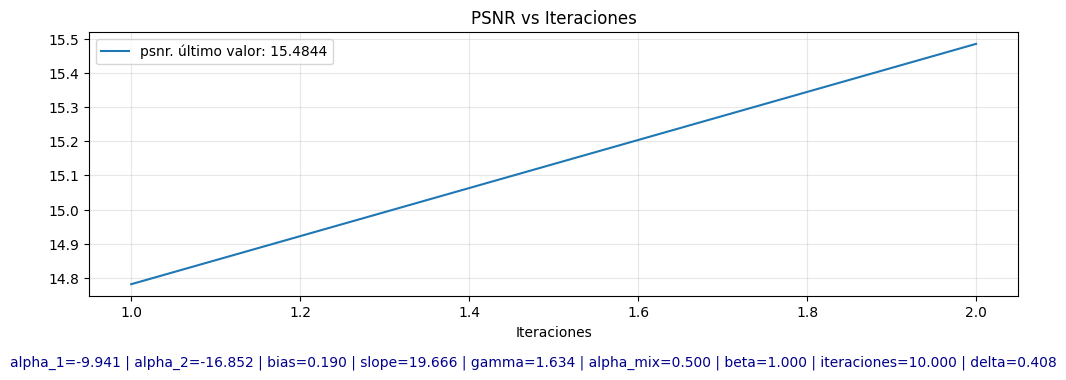


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.484  std:1.991
mask_bpsnr       : mean: 9.697  std:1.576
ssim             : mean: 0.578  std:0.088
acc_at_least_one : 0.885
acc_both         : 0.319

Run 10/20


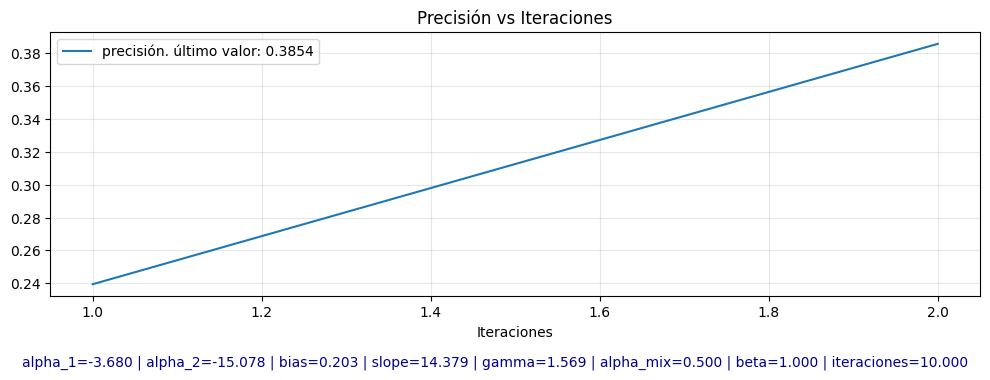

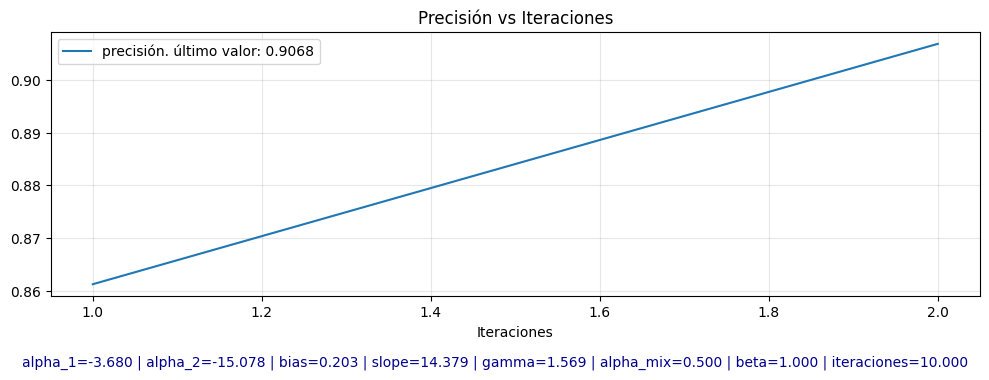

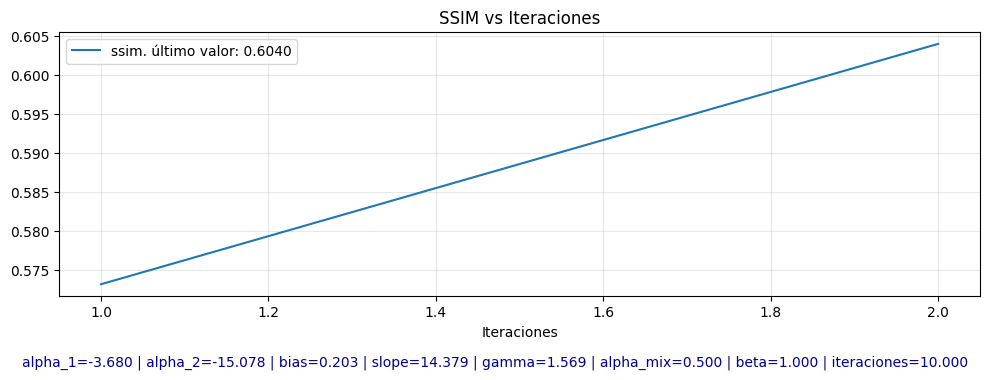

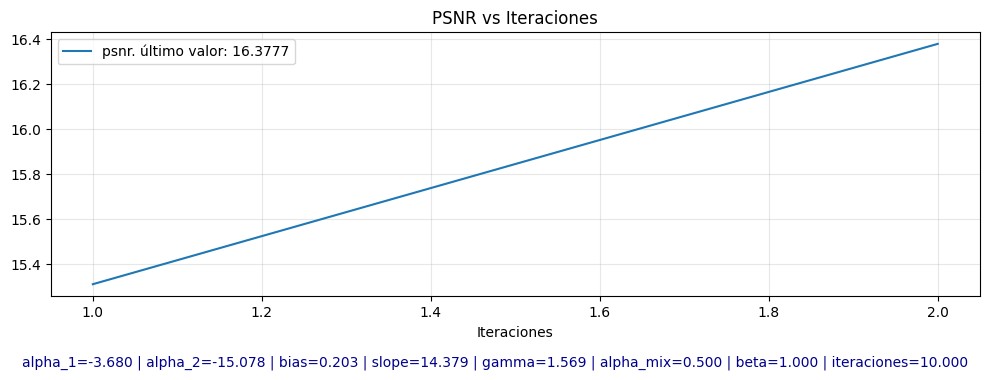


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.378  std:1.859
mask_bpsnr       : mean: 11.582  std:1.629
ssim             : mean: 0.604  std:0.087
acc_at_least_one : 0.907
acc_both         : 0.385



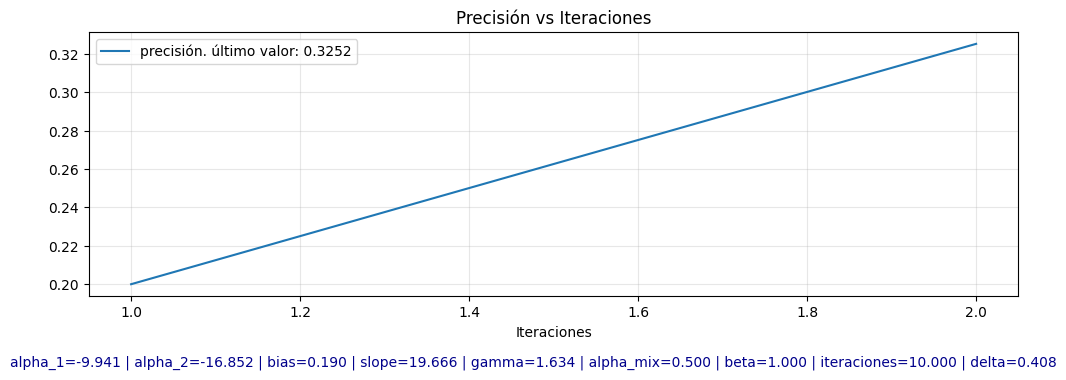

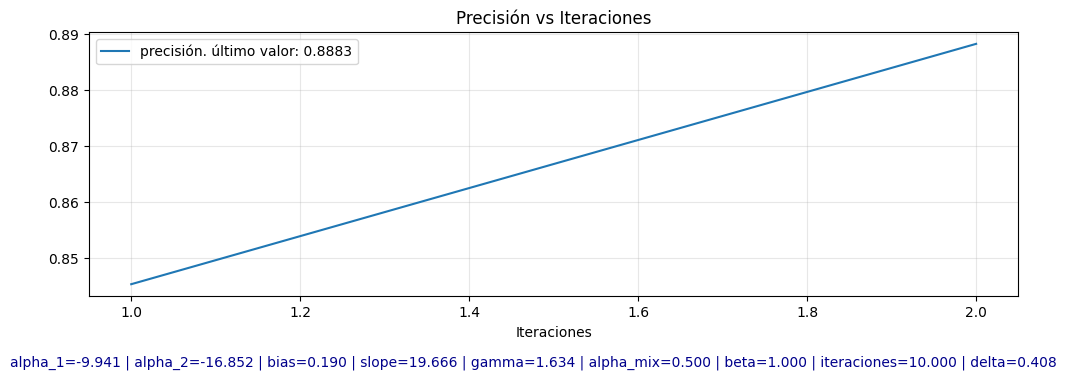

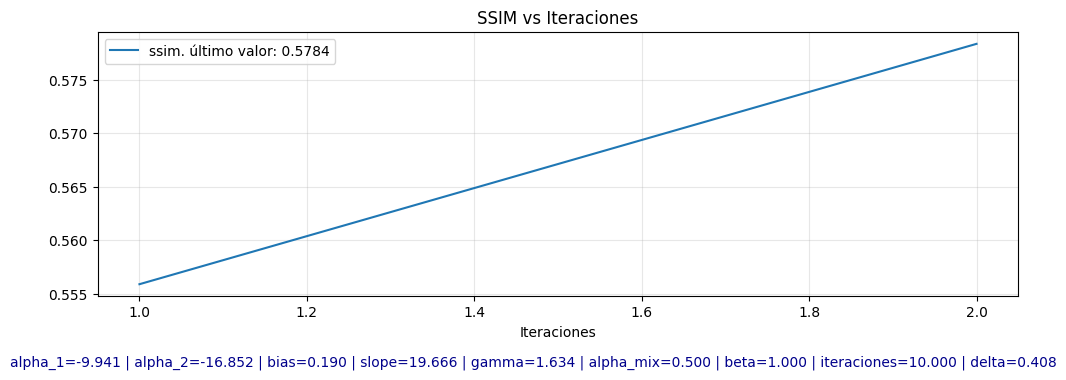

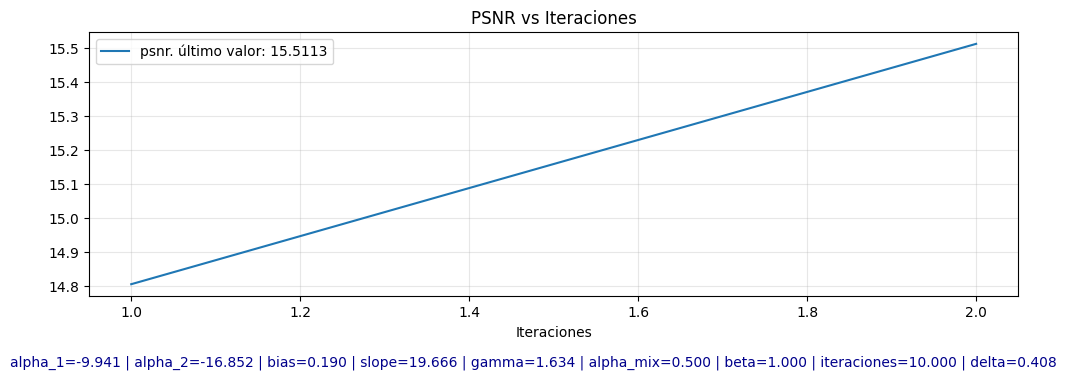


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.511  std:2.034
mask_bpsnr       : mean: 9.713  std:1.579
ssim             : mean: 0.578  std:0.090
acc_at_least_one : 0.888
acc_both         : 0.325

Run 11/20


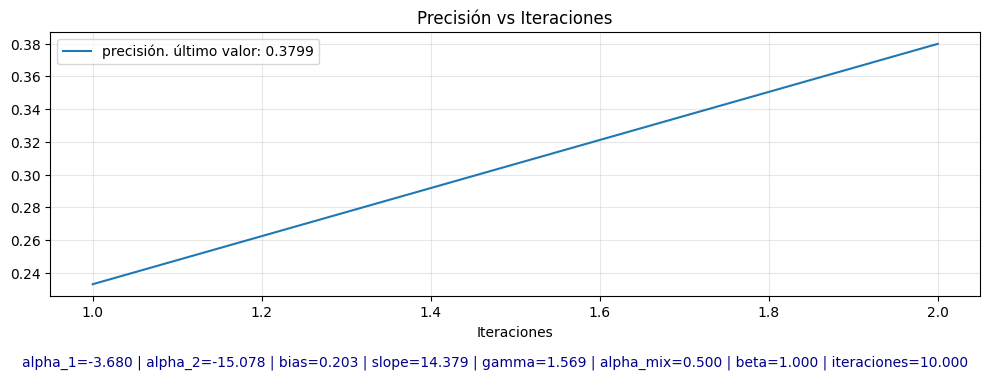

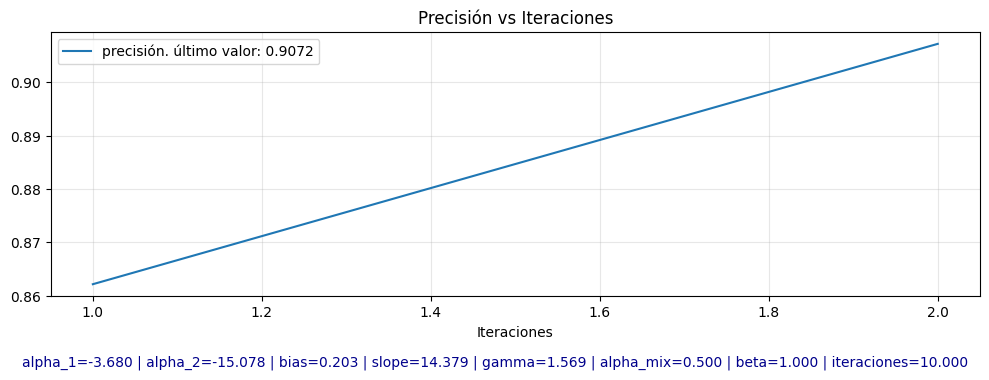

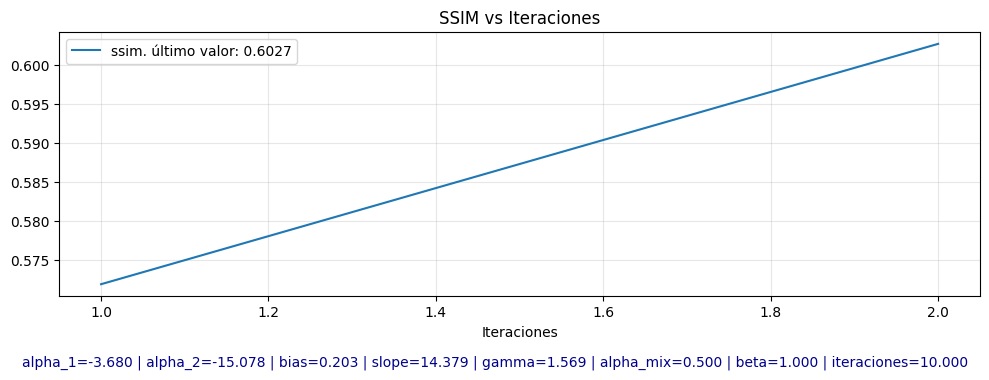

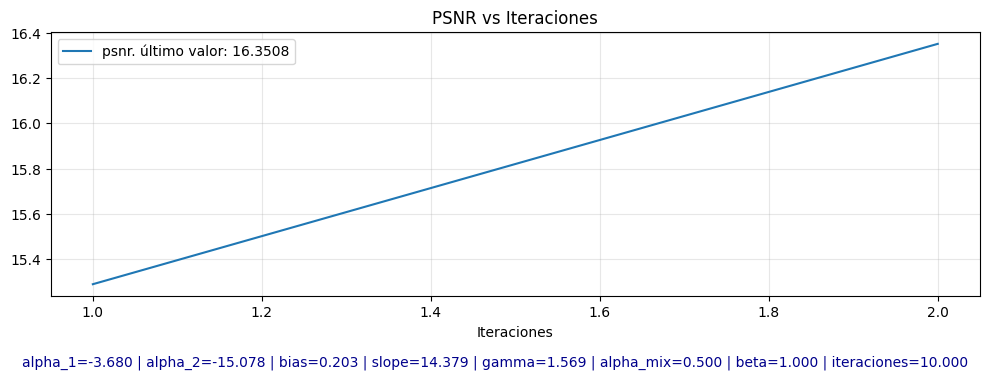


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.351  std:1.847
mask_bpsnr       : mean: 11.582  std:1.613
ssim             : mean: 0.603  std:0.086
acc_at_least_one : 0.907
acc_both         : 0.380



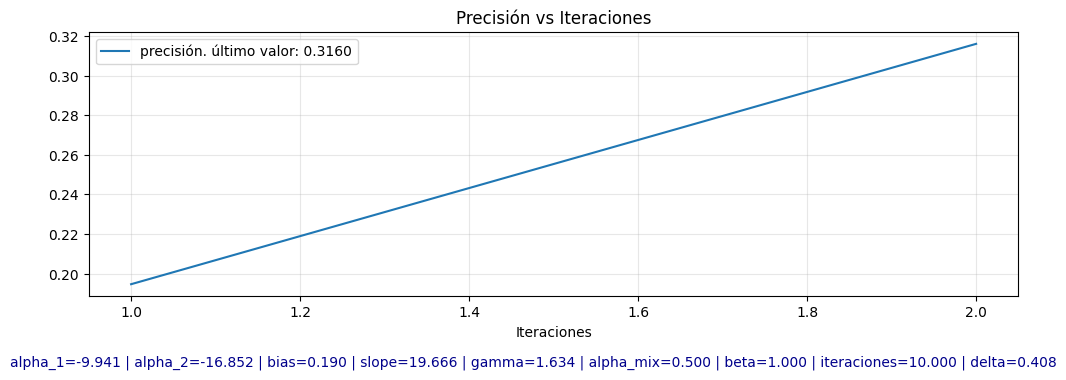

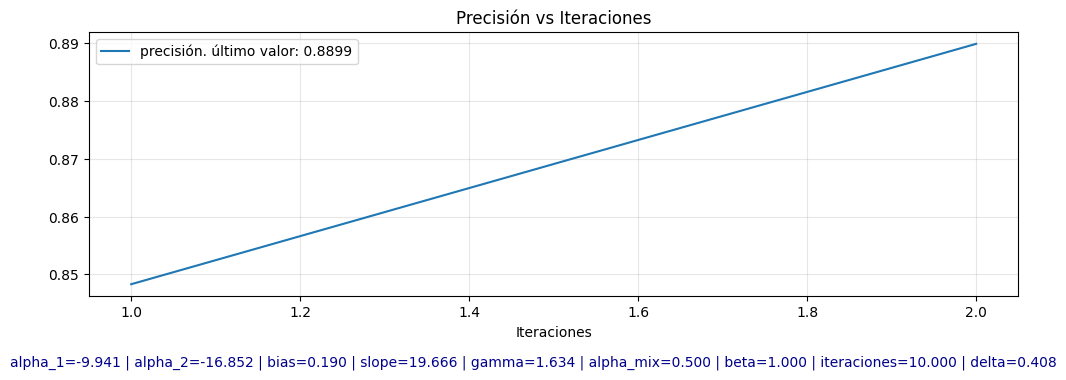

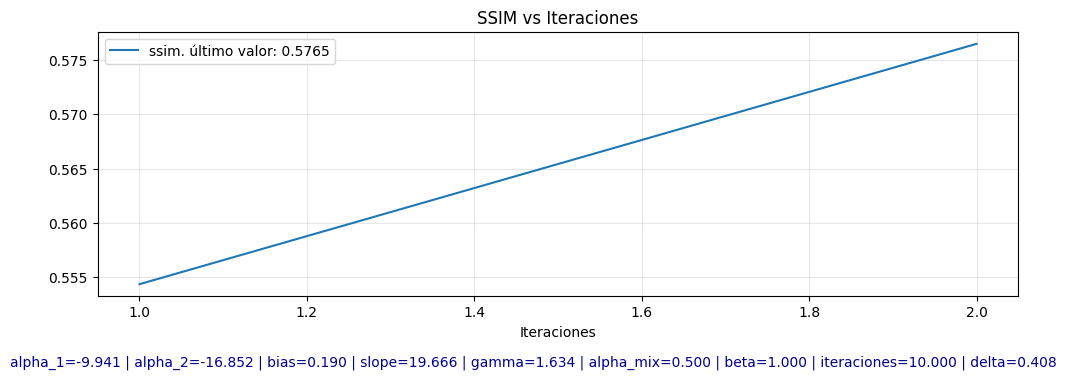

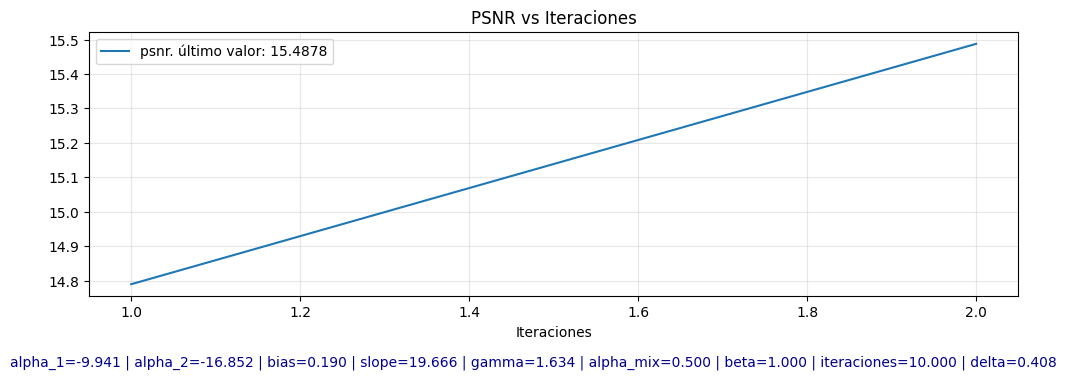


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.488  std:2.005
mask_bpsnr       : mean: 9.699  std:1.584
ssim             : mean: 0.576  std:0.089
acc_at_least_one : 0.890
acc_both         : 0.316

Run 12/20


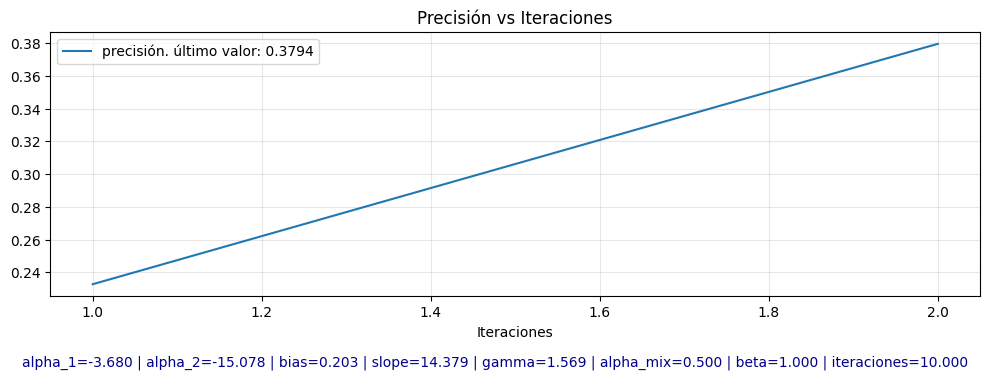

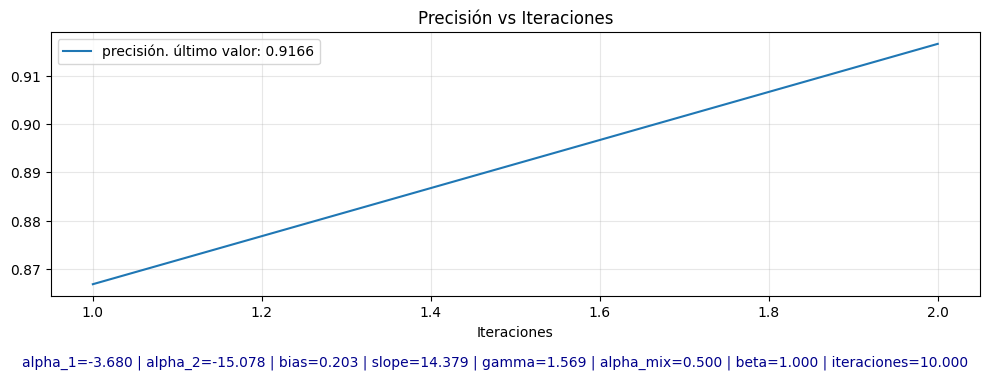

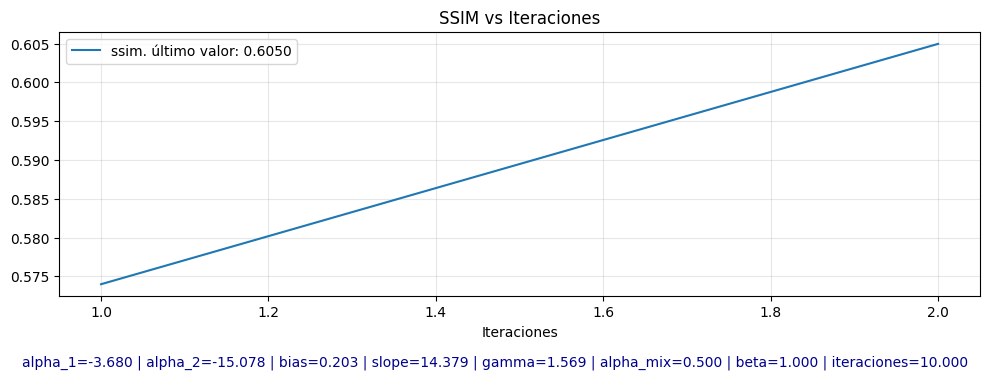

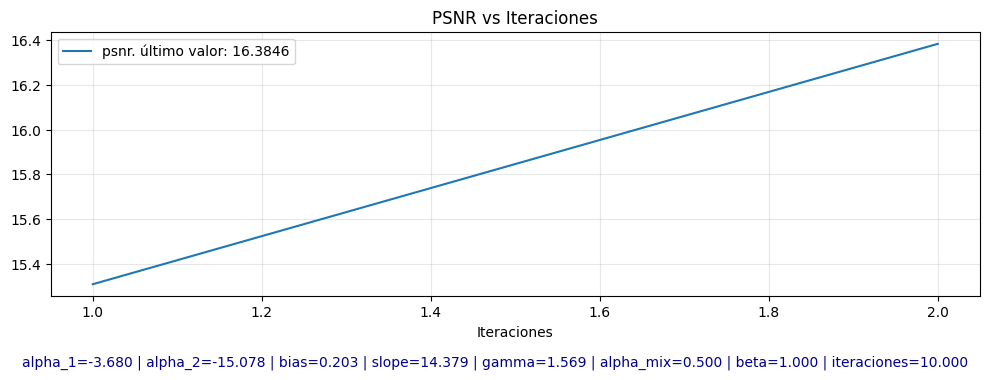


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.385  std:1.855
mask_bpsnr       : mean: 11.605  std:1.633
ssim             : mean: 0.605  std:0.088
acc_at_least_one : 0.917
acc_both         : 0.379



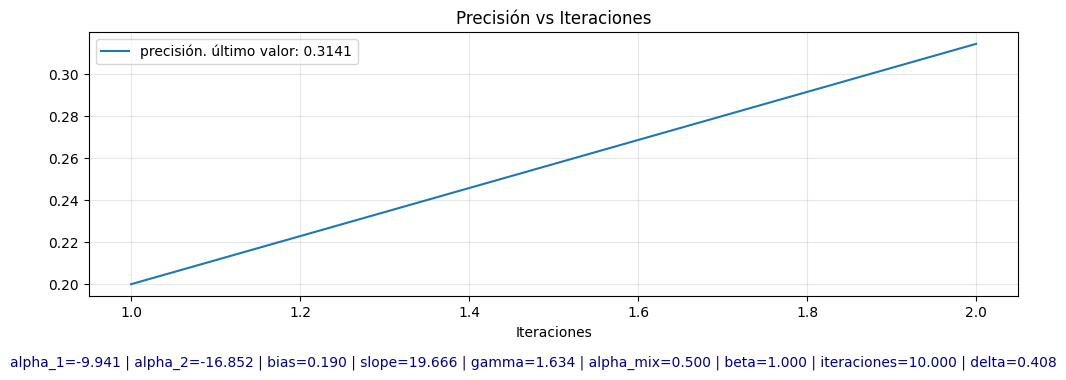

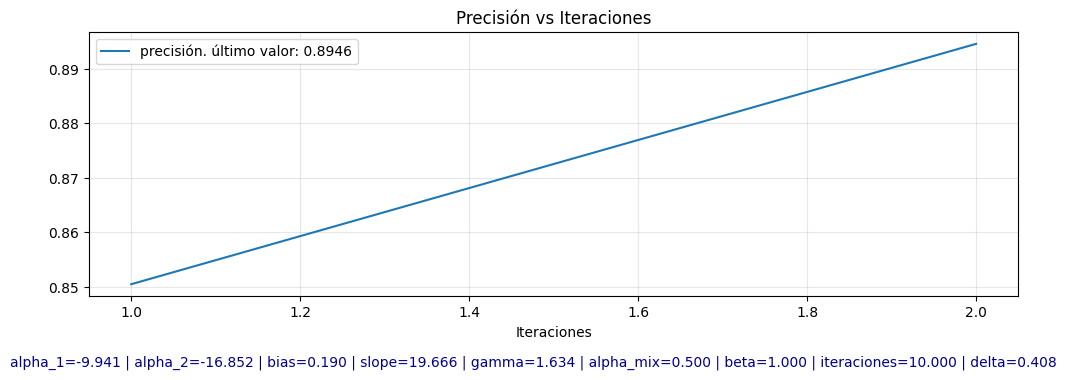

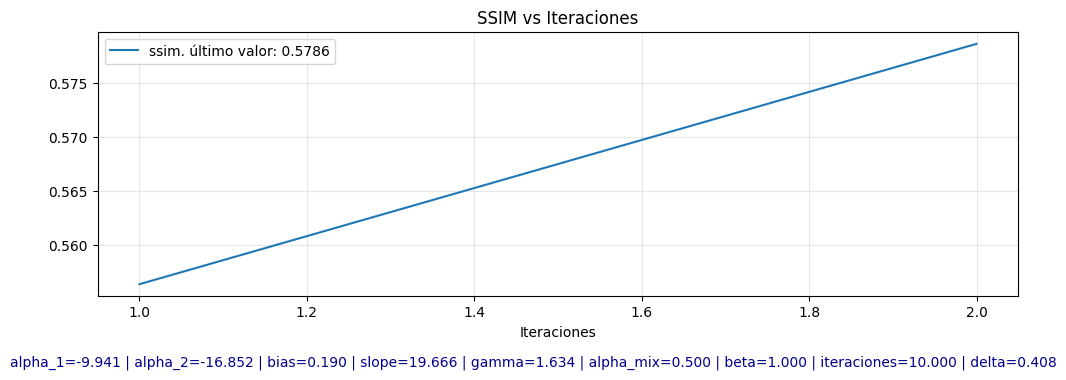

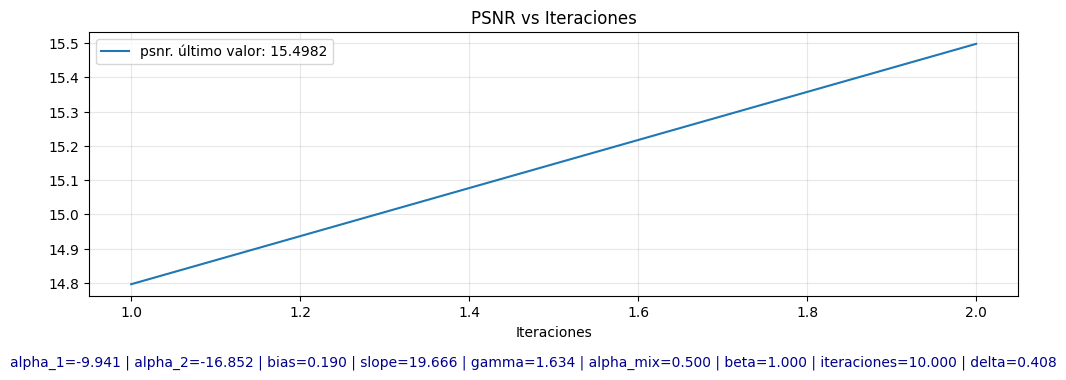


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.498  std:2.026
mask_bpsnr       : mean: 9.718  std:1.586
ssim             : mean: 0.579  std:0.091
acc_at_least_one : 0.895
acc_both         : 0.314

Run 13/20


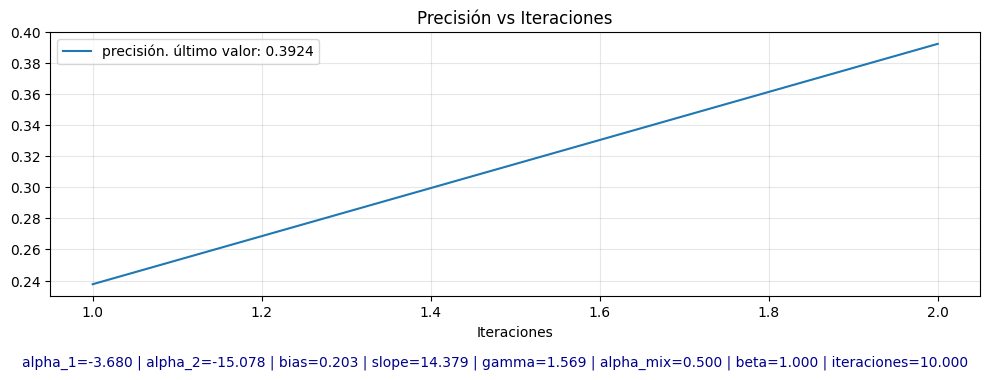

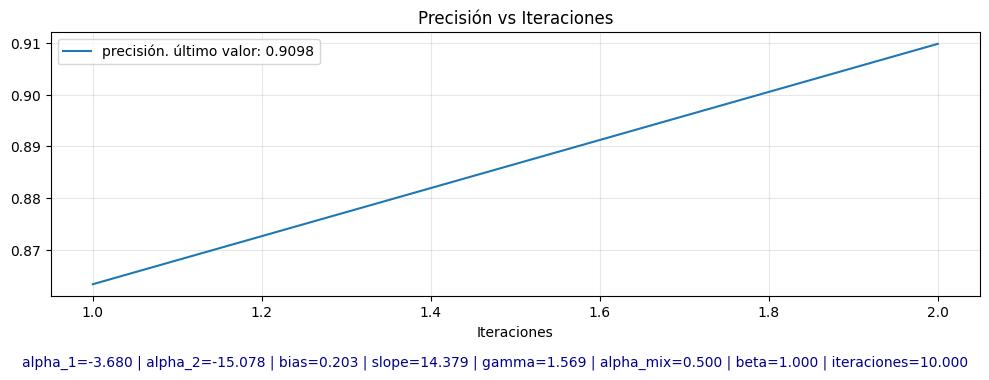

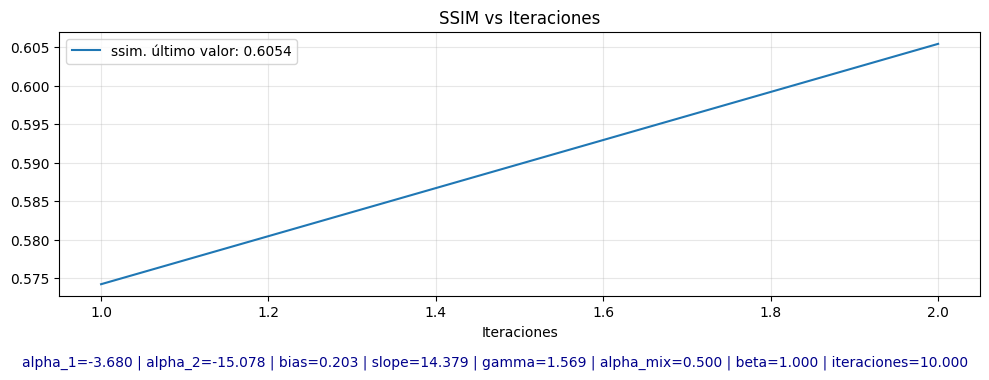

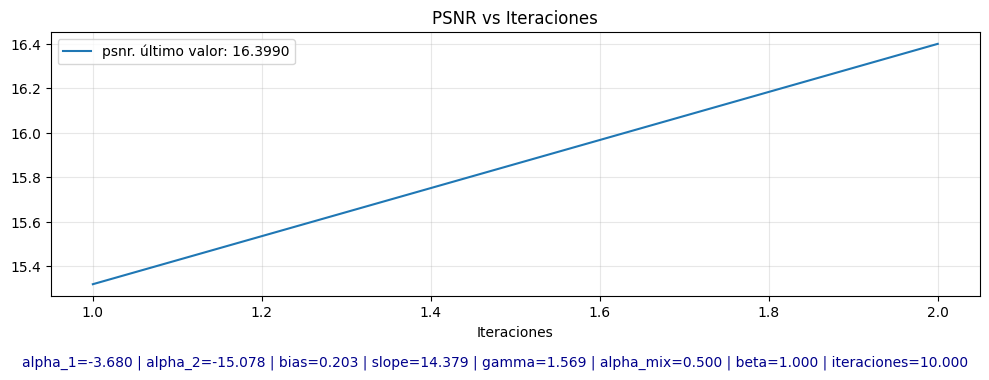


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.399  std:1.827
mask_bpsnr       : mean: 11.614  std:1.614
ssim             : mean: 0.605  std:0.087
acc_at_least_one : 0.910
acc_both         : 0.392



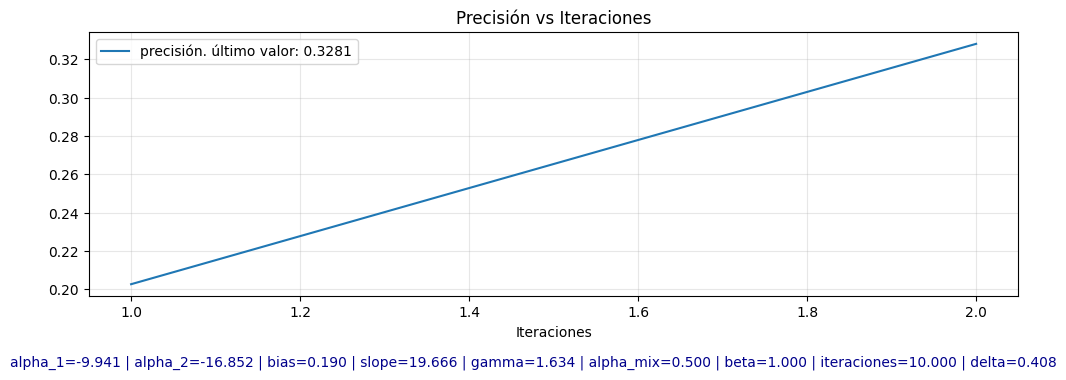

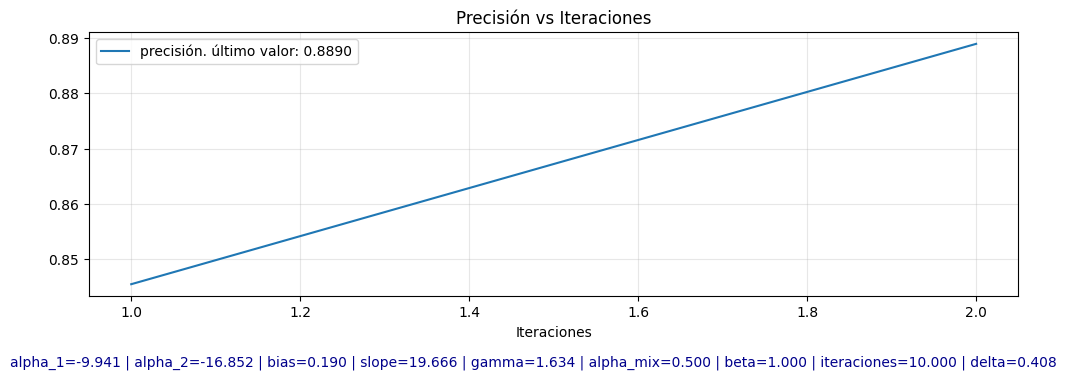

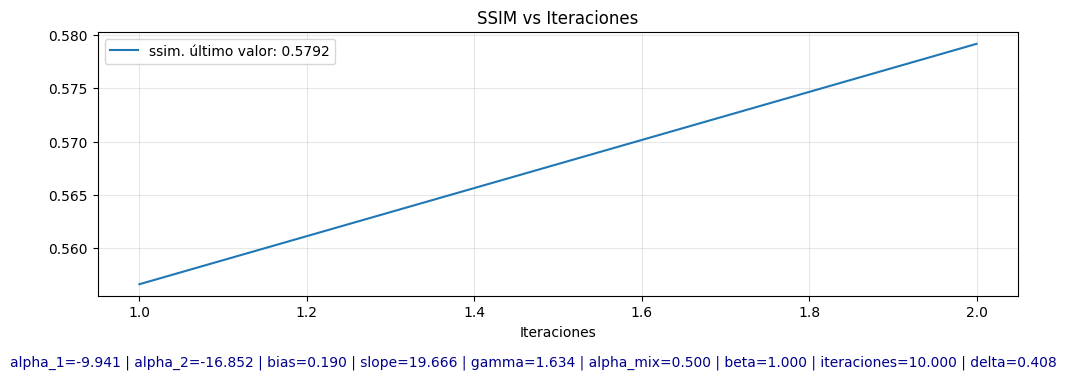

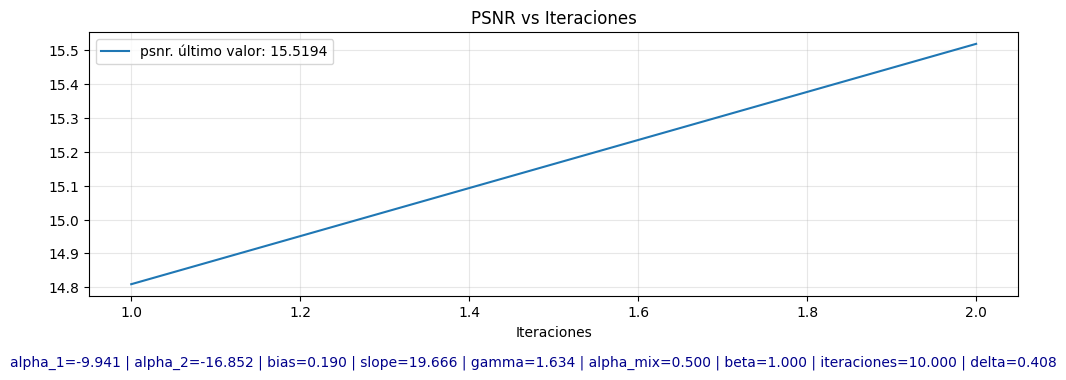


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.519  std:1.987
mask_bpsnr       : mean: 9.734  std:1.594
ssim             : mean: 0.579  std:0.090
acc_at_least_one : 0.889
acc_both         : 0.328

Run 14/20


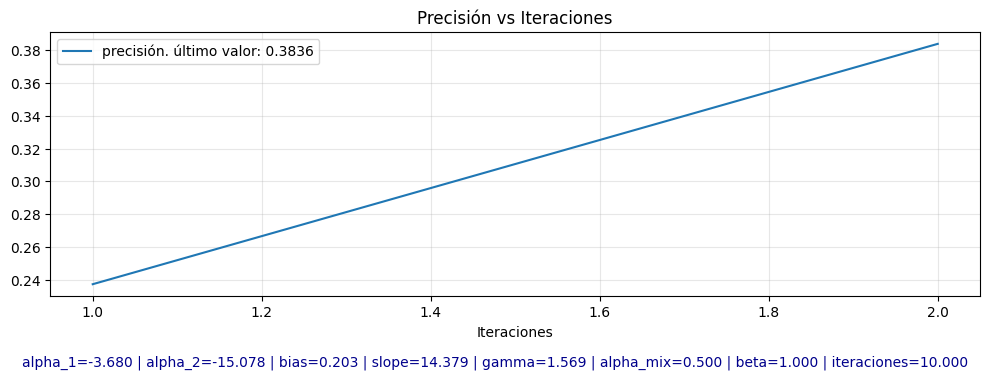

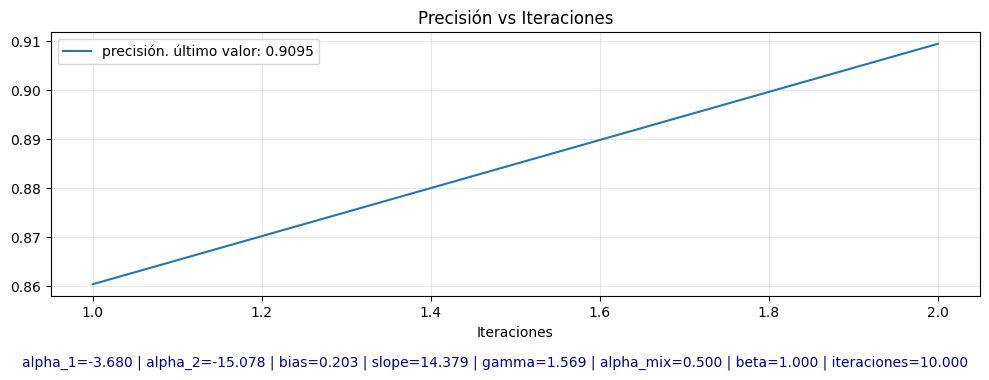

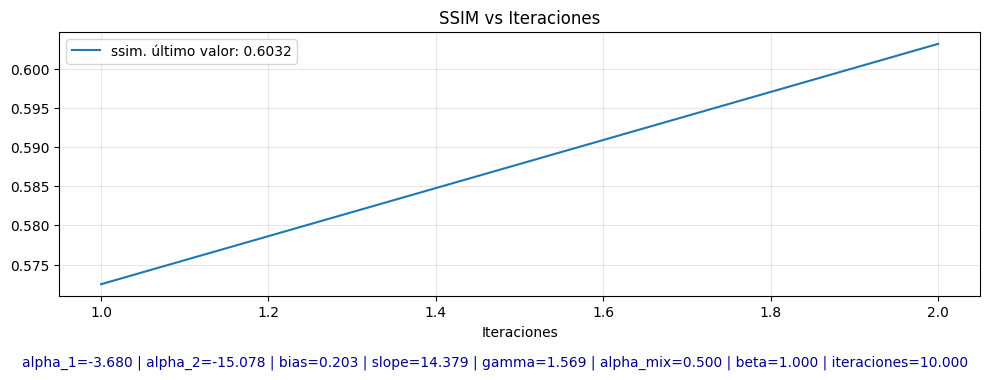

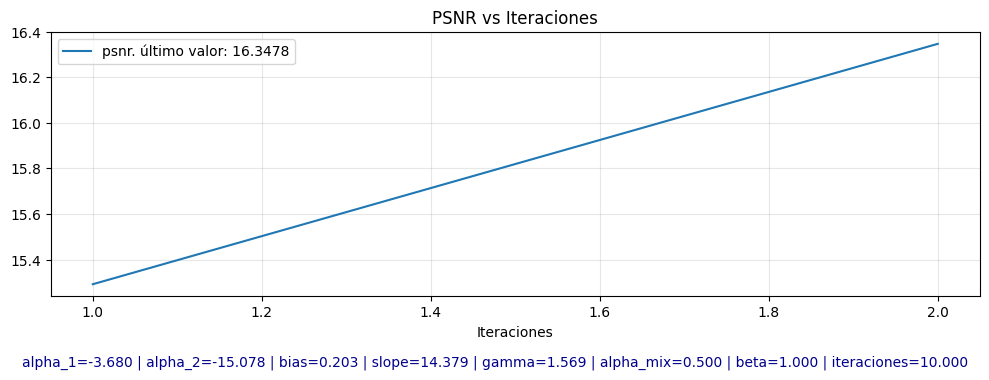


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.348  std:1.830
mask_bpsnr       : mean: 11.573  std:1.632
ssim             : mean: 0.603  std:0.086
acc_at_least_one : 0.909
acc_both         : 0.384



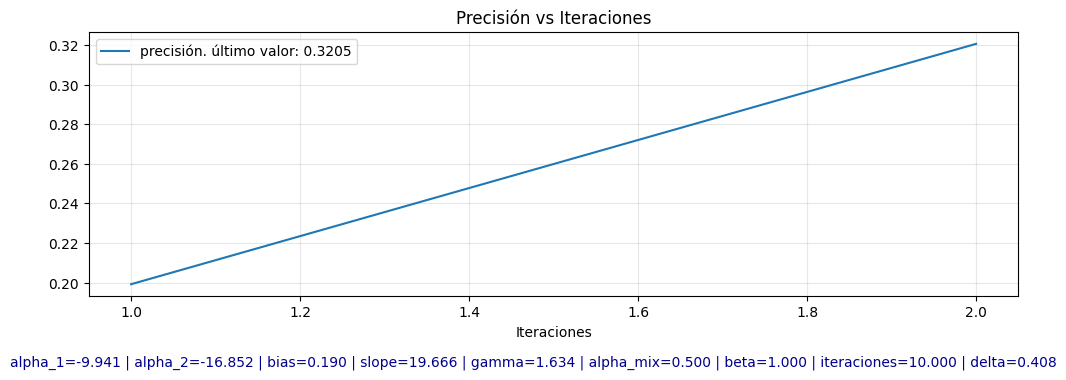

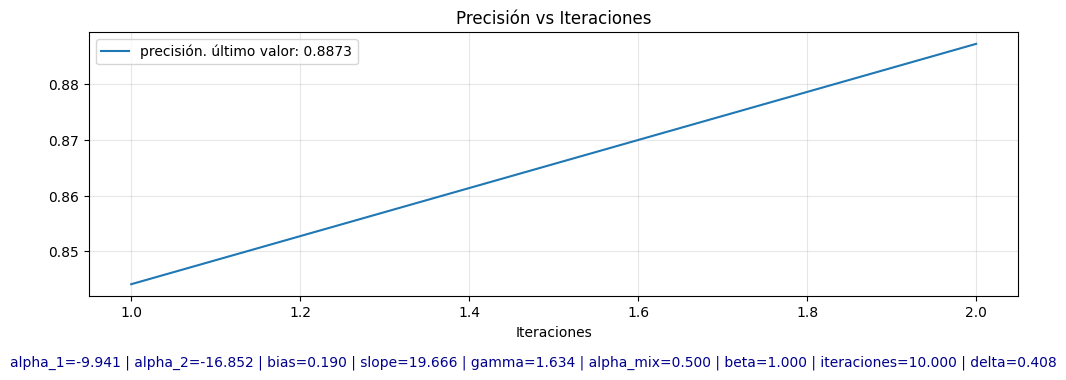

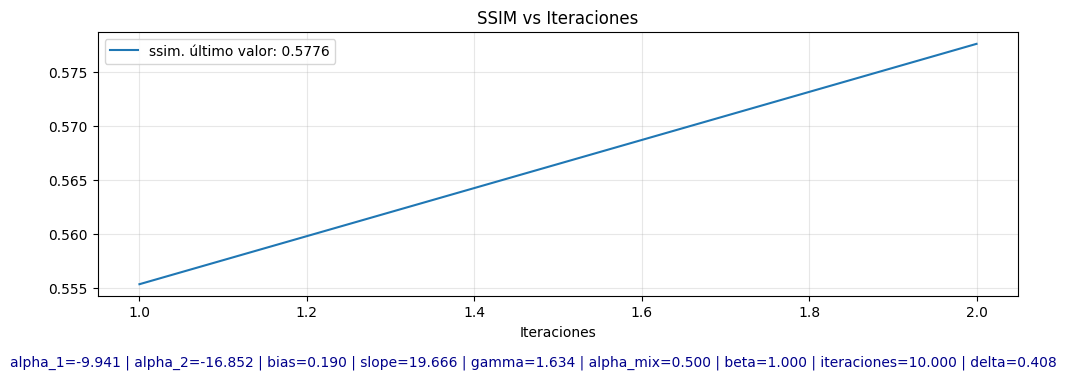

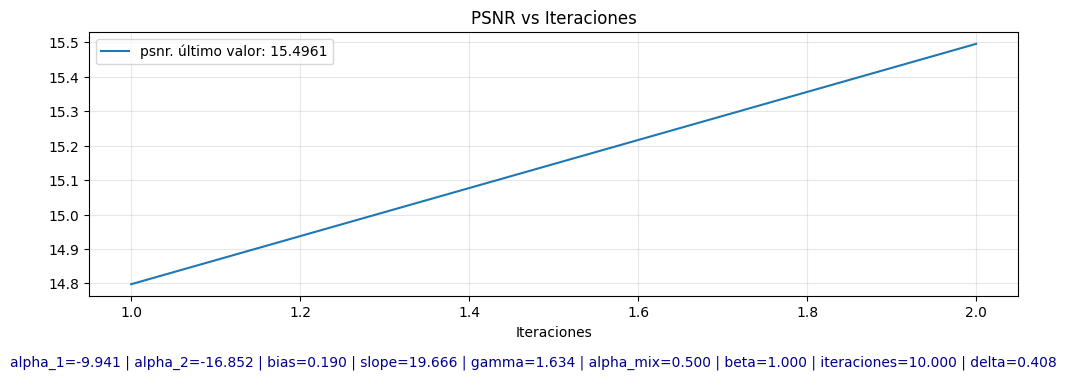


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.496  std:1.987
mask_bpsnr       : mean: 9.718  std:1.565
ssim             : mean: 0.578  std:0.089
acc_at_least_one : 0.887
acc_both         : 0.321

Run 15/20


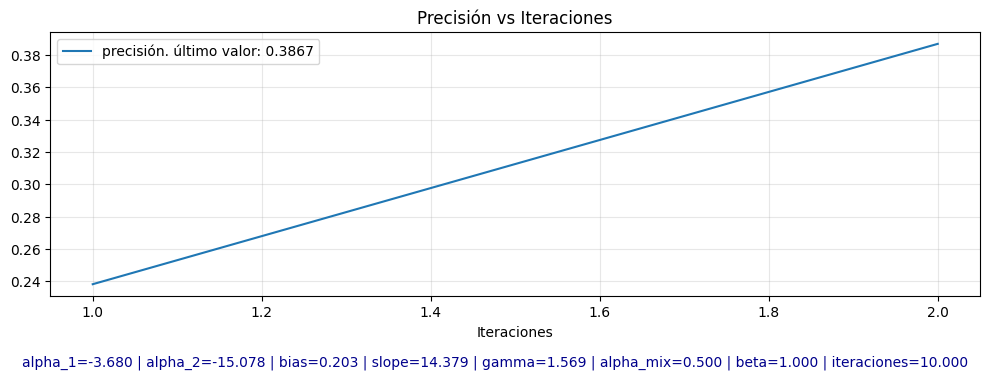

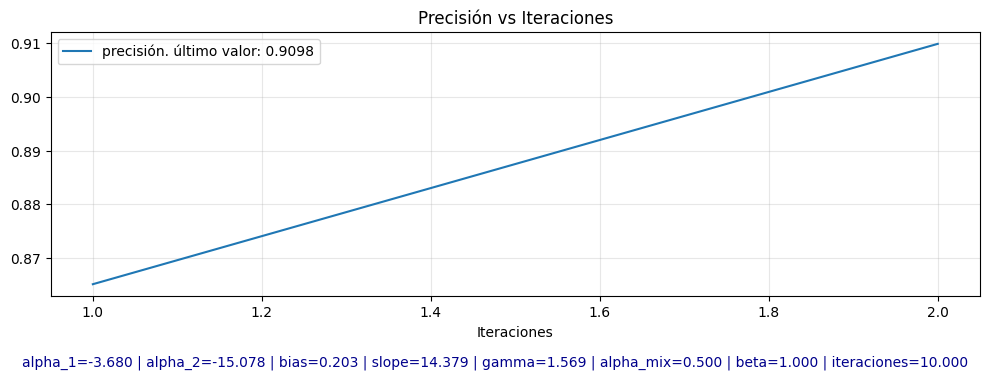

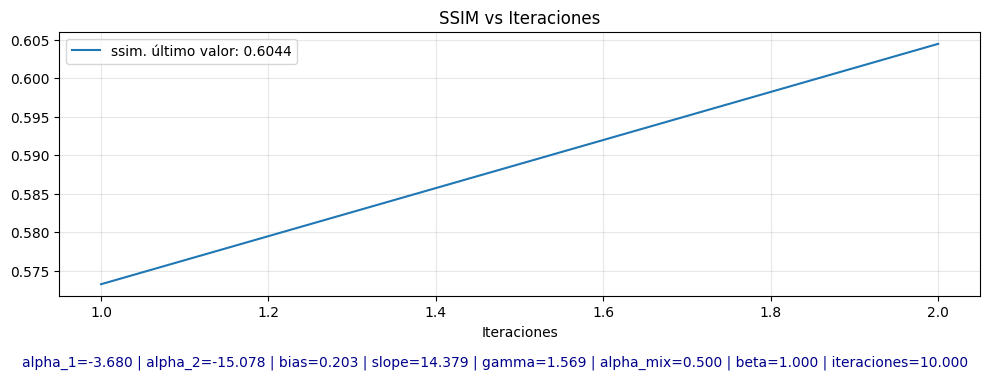

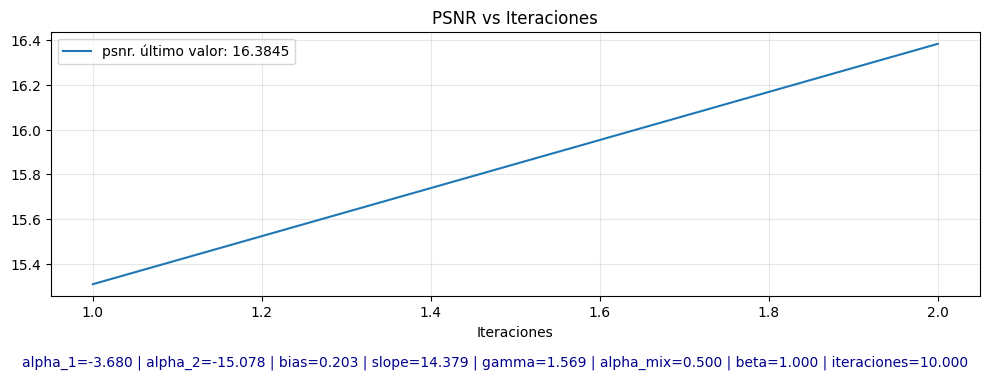


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.384  std:1.861
mask_bpsnr       : mean: 11.614  std:1.628
ssim             : mean: 0.604  std:0.086
acc_at_least_one : 0.910
acc_both         : 0.387



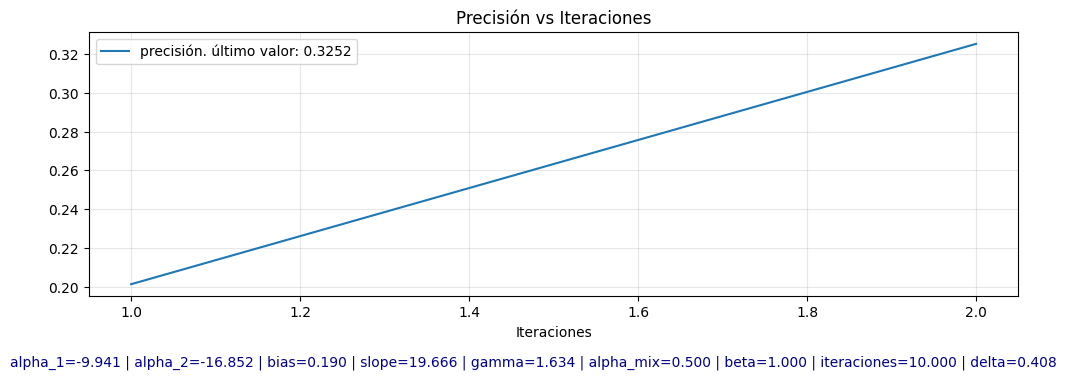

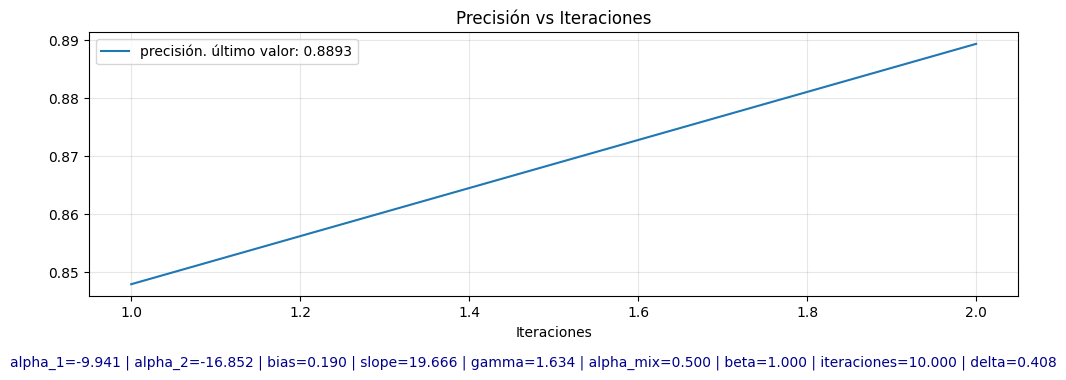

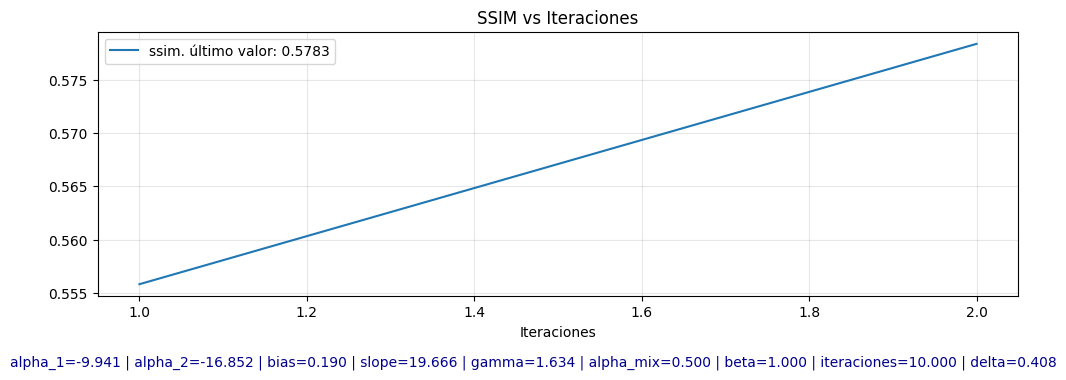

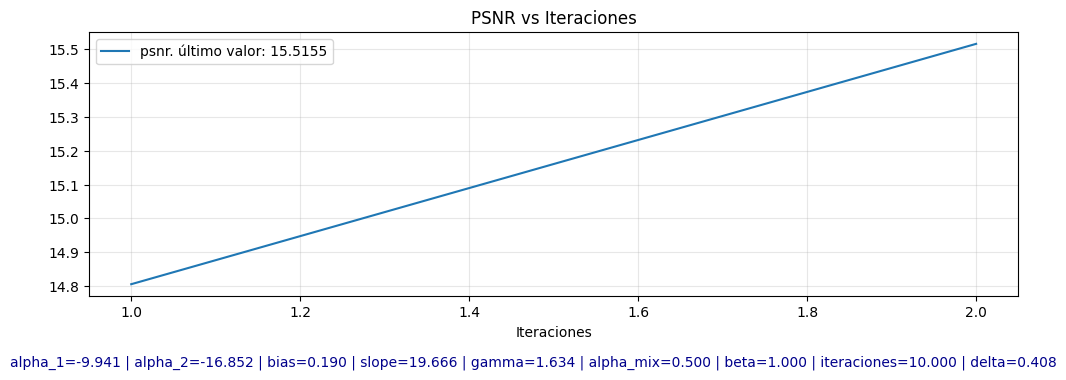


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.516  std:2.026
mask_bpsnr       : mean: 9.727  std:1.570
ssim             : mean: 0.578  std:0.089
acc_at_least_one : 0.889
acc_both         : 0.325

Run 16/20


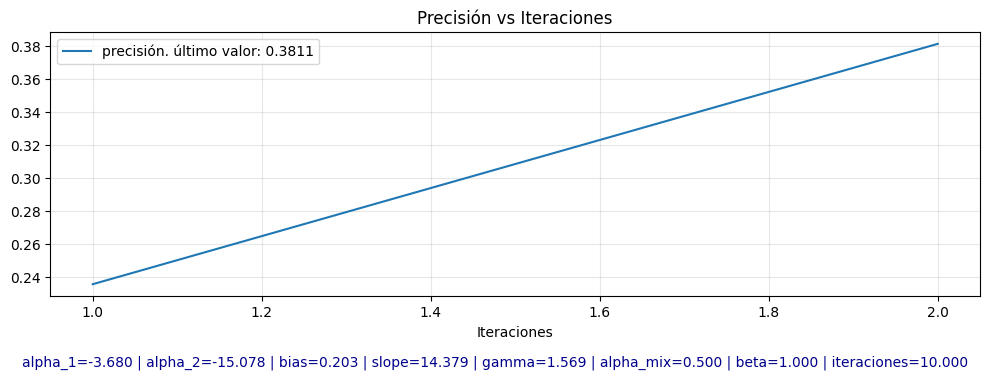

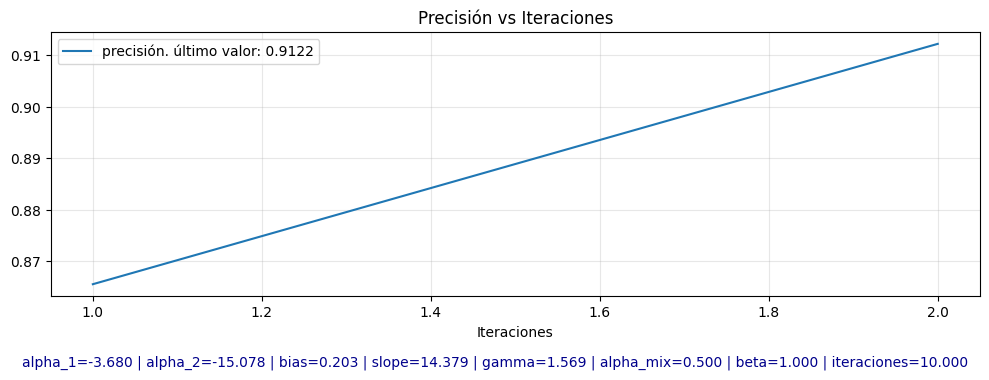

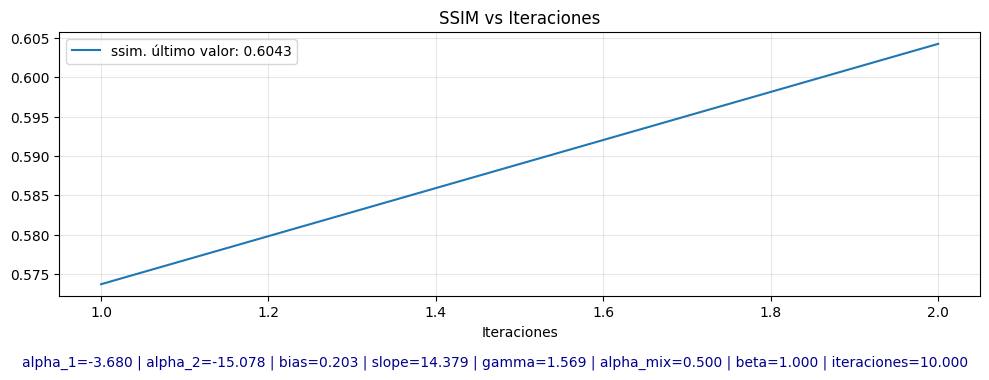

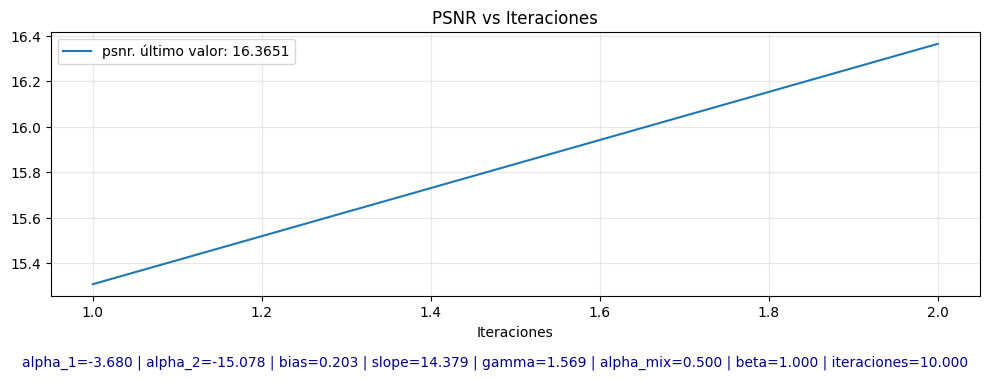


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.365  std:1.839
mask_bpsnr       : mean: 11.591  std:1.623
ssim             : mean: 0.604  std:0.087
acc_at_least_one : 0.912
acc_both         : 0.381



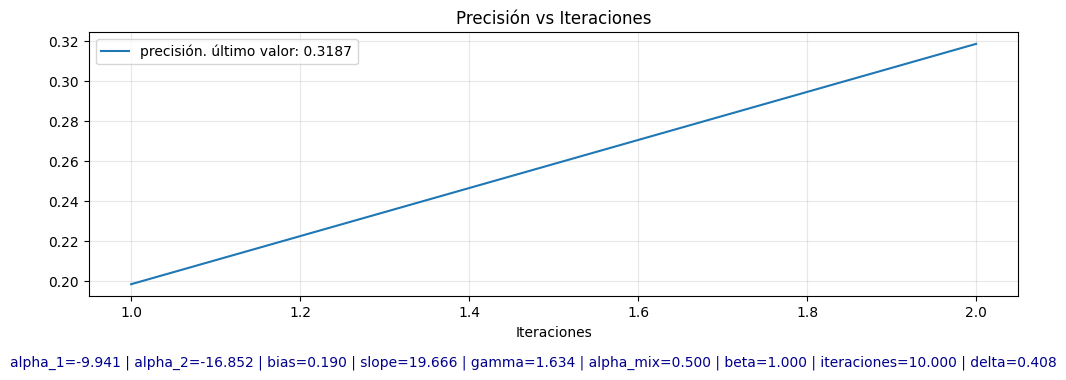

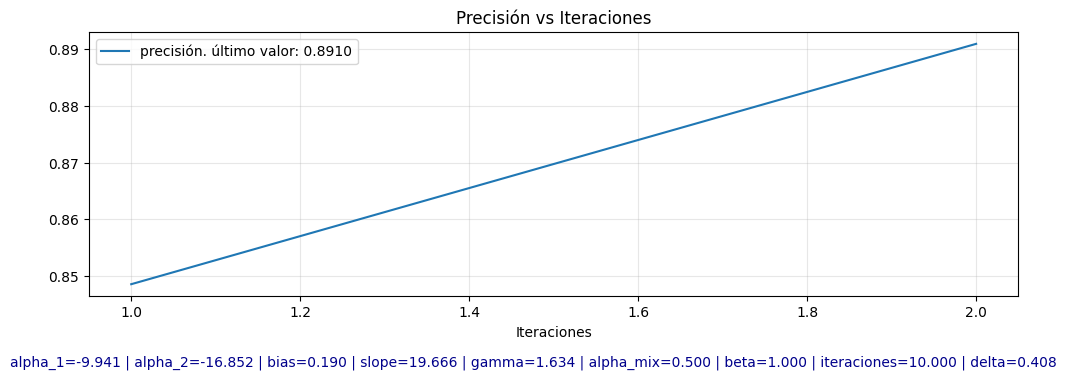

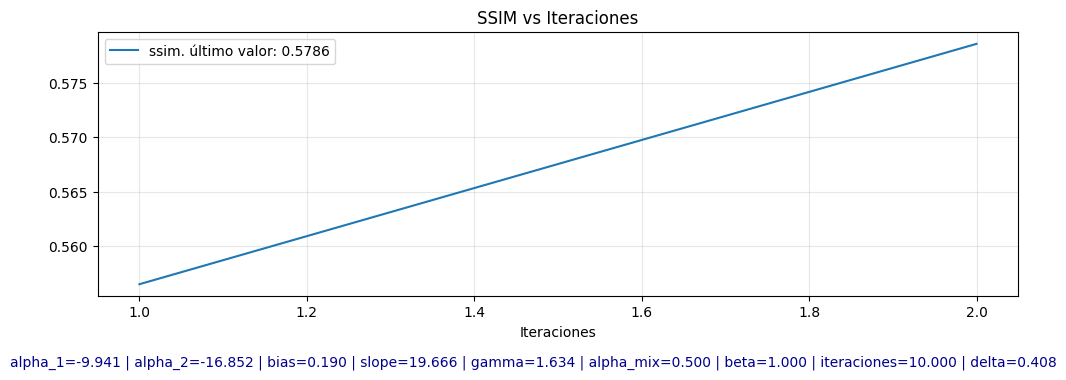

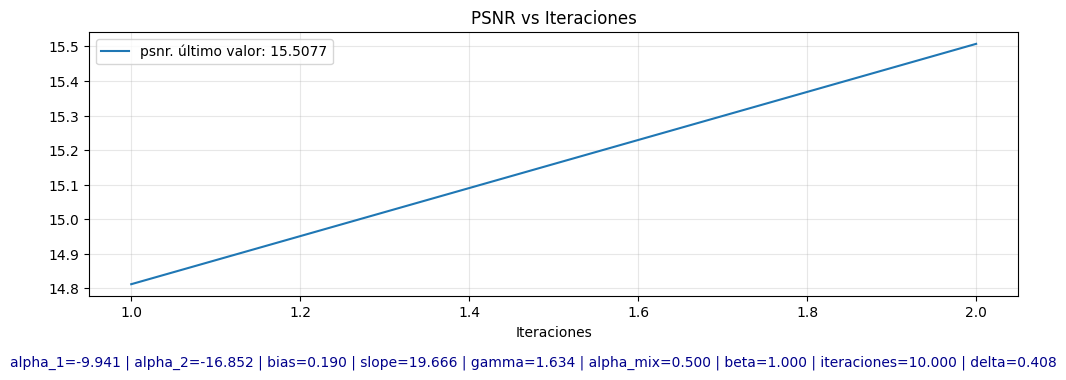


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.508  std:1.998
mask_bpsnr       : mean: 9.730  std:1.566
ssim             : mean: 0.579  std:0.090
acc_at_least_one : 0.891
acc_both         : 0.319

Run 17/20


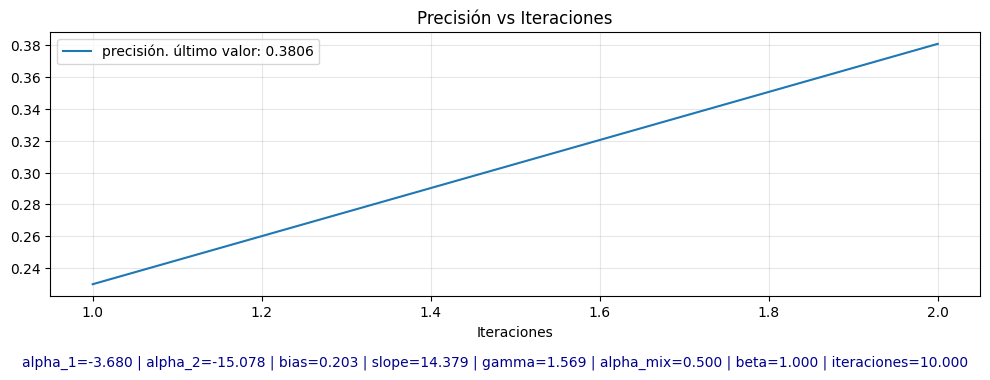

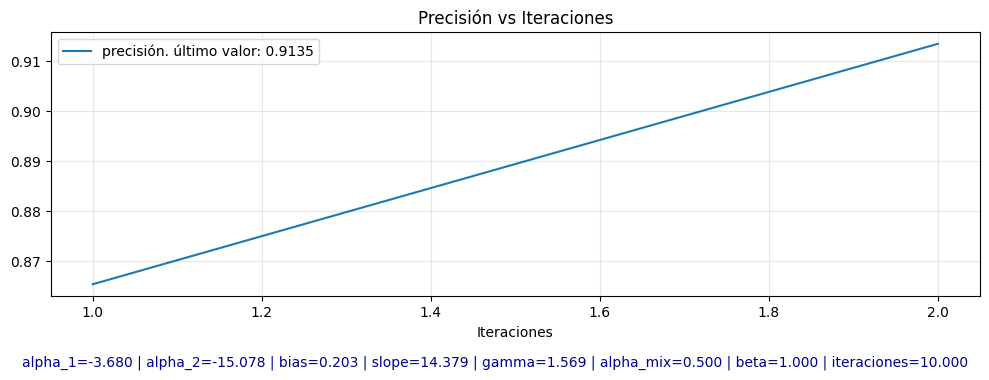

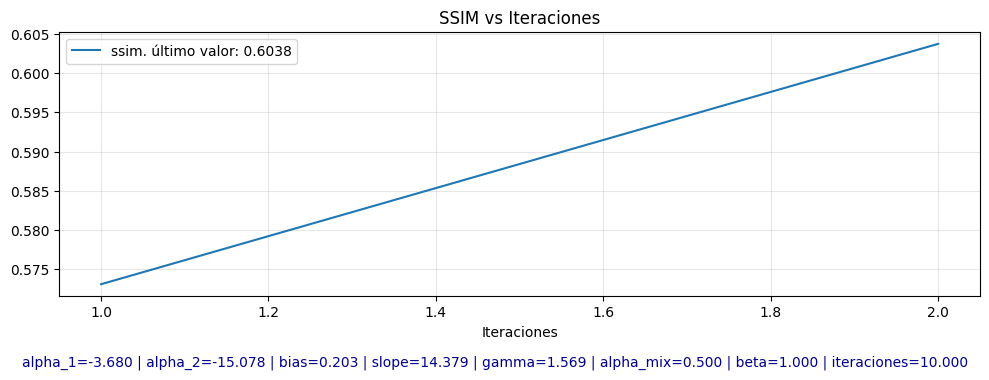

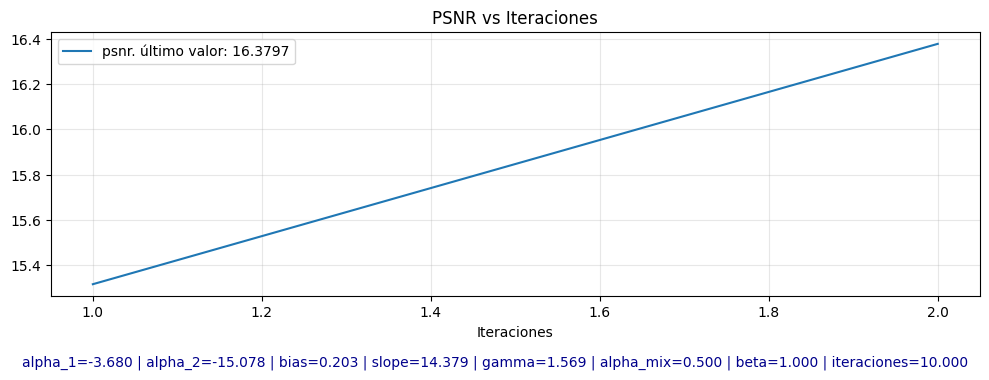


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.380  std:1.851
mask_bpsnr       : mean: 11.602  std:1.634
ssim             : mean: 0.604  std:0.088
acc_at_least_one : 0.913
acc_both         : 0.381



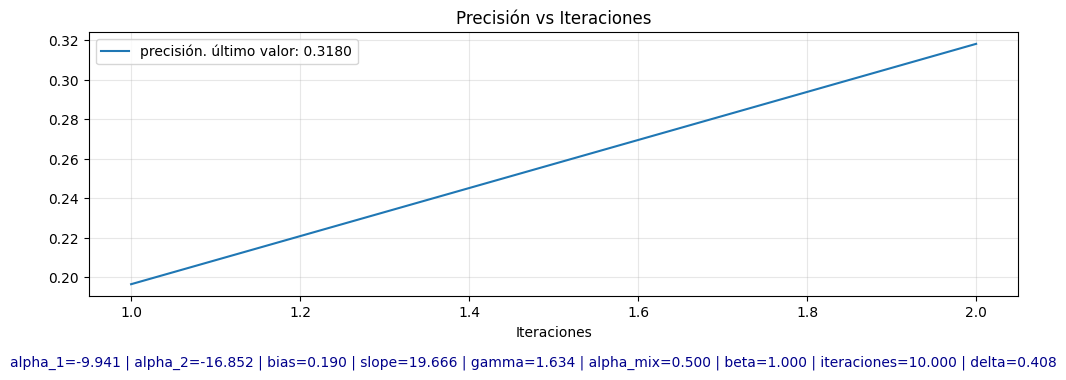

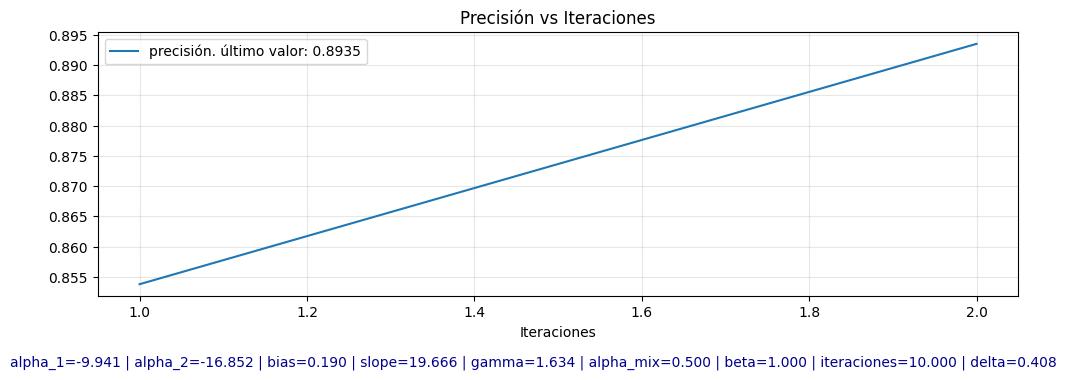

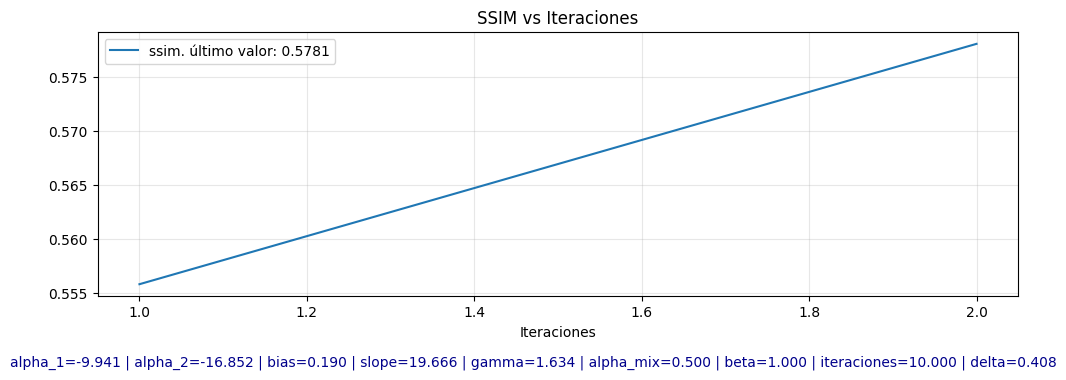

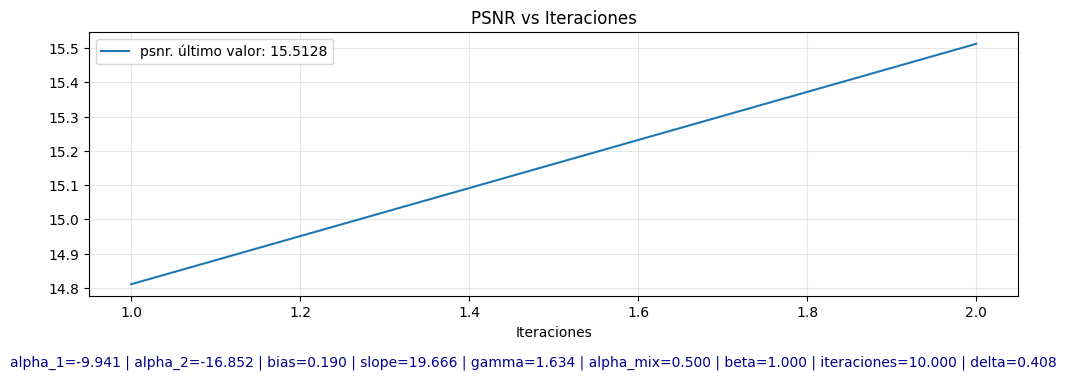


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.513  std:2.000
mask_bpsnr       : mean: 9.730  std:1.582
ssim             : mean: 0.578  std:0.090
acc_at_least_one : 0.893
acc_both         : 0.318

Run 18/20


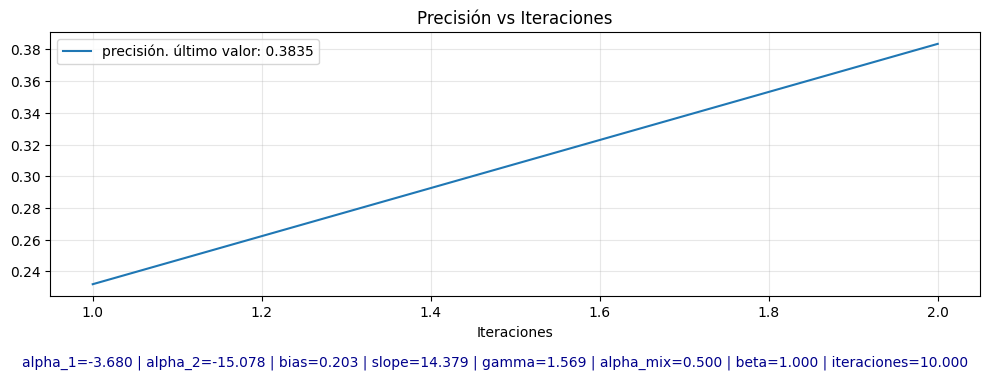

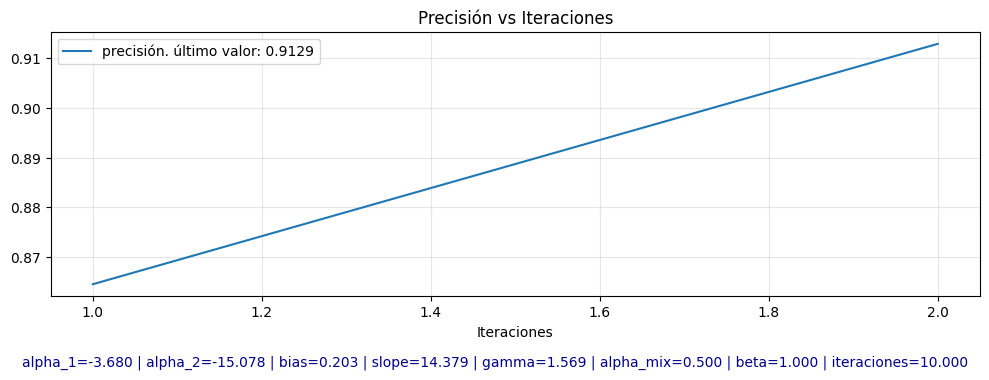

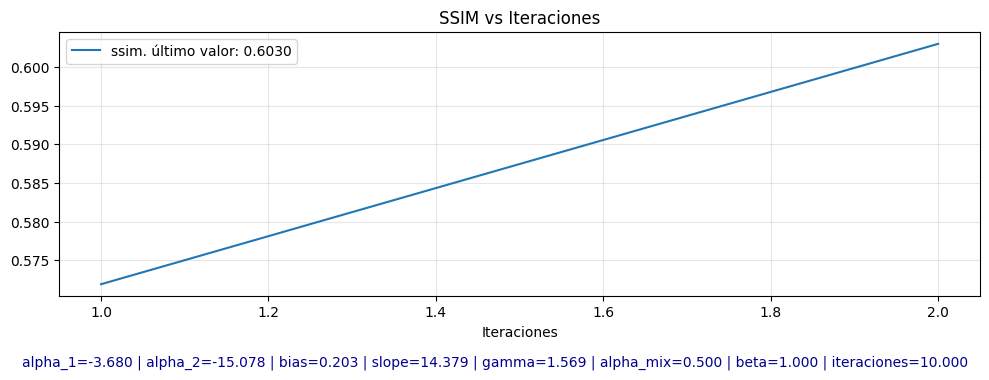

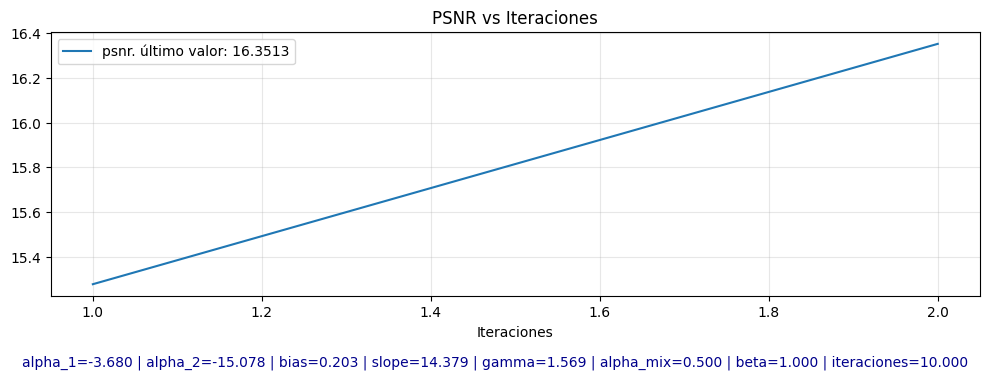


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.351  std:1.877
mask_bpsnr       : mean: 11.587  std:1.642
ssim             : mean: 0.603  std:0.087
acc_at_least_one : 0.913
acc_both         : 0.384



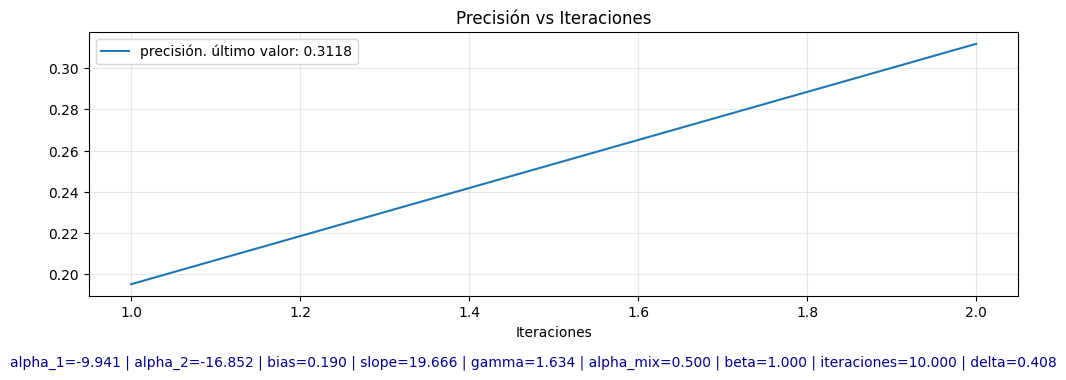

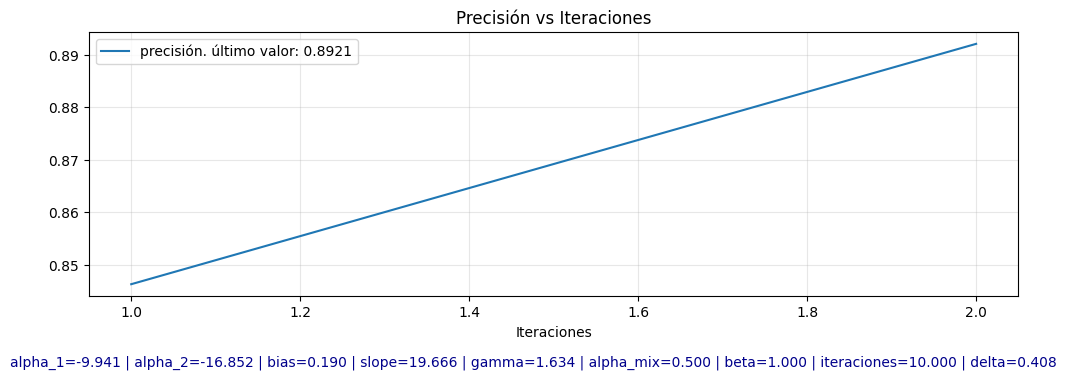

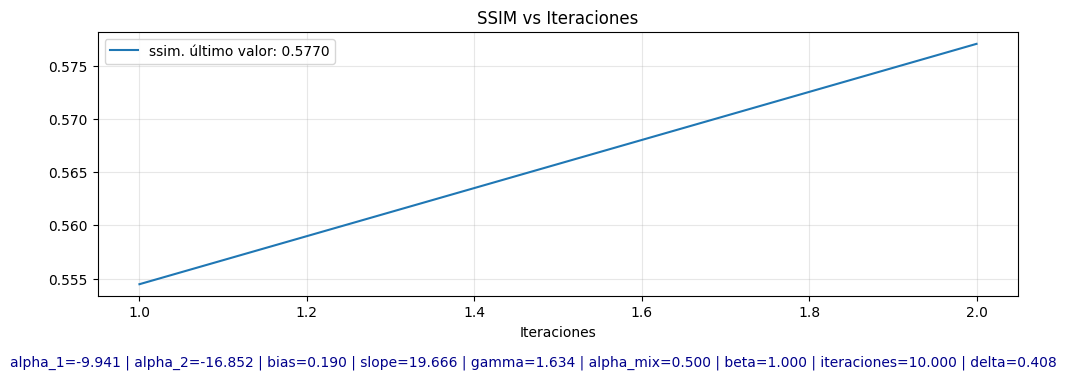

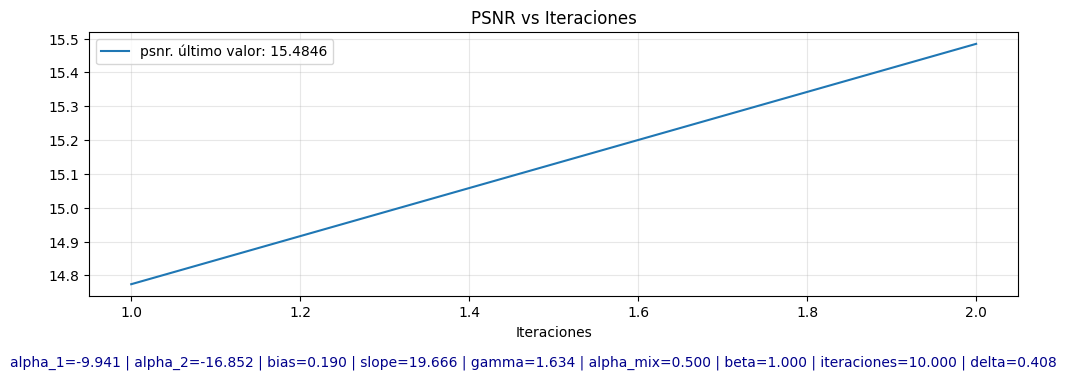


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.485  std:2.022
mask_bpsnr       : mean: 9.717  std:1.572
ssim             : mean: 0.577  std:0.089
acc_at_least_one : 0.892
acc_both         : 0.312

Run 19/20


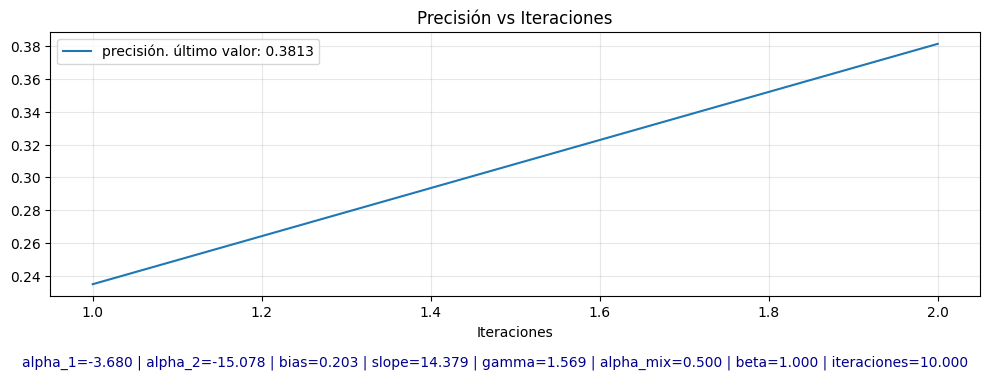

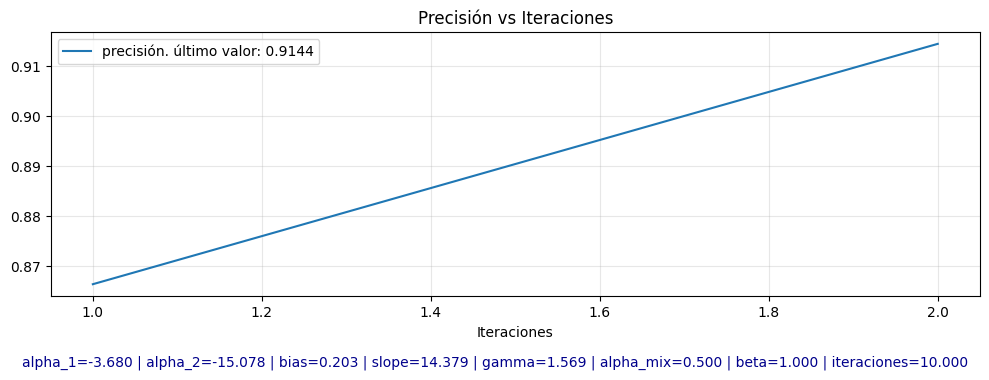

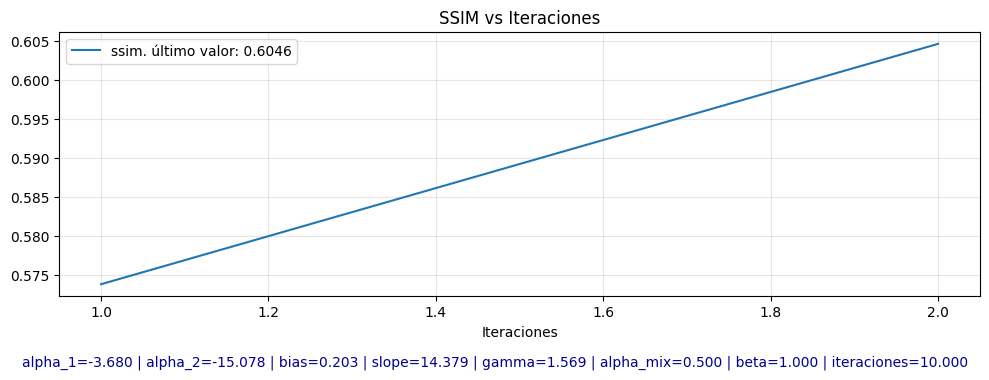

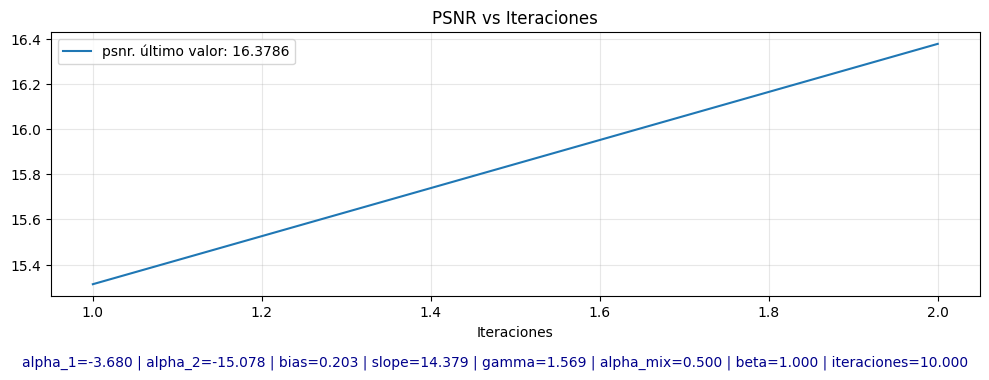


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.379  std:1.867
mask_bpsnr       : mean: 11.590  std:1.627
ssim             : mean: 0.605  std:0.088
acc_at_least_one : 0.914
acc_both         : 0.381



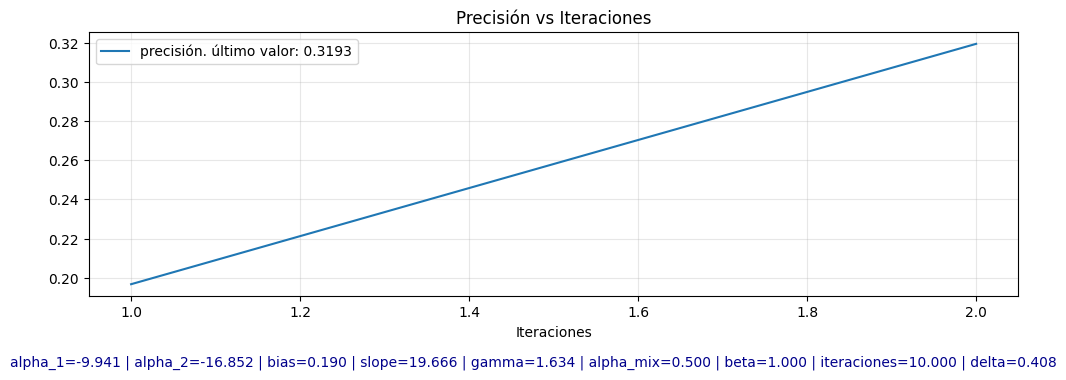

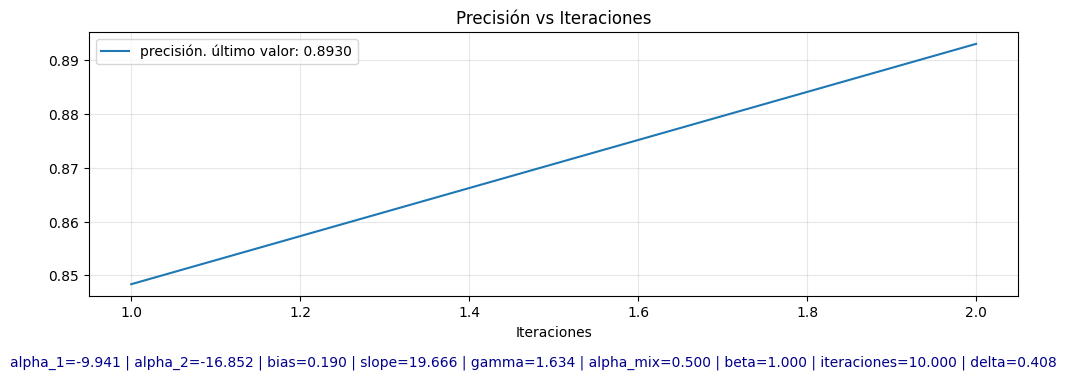

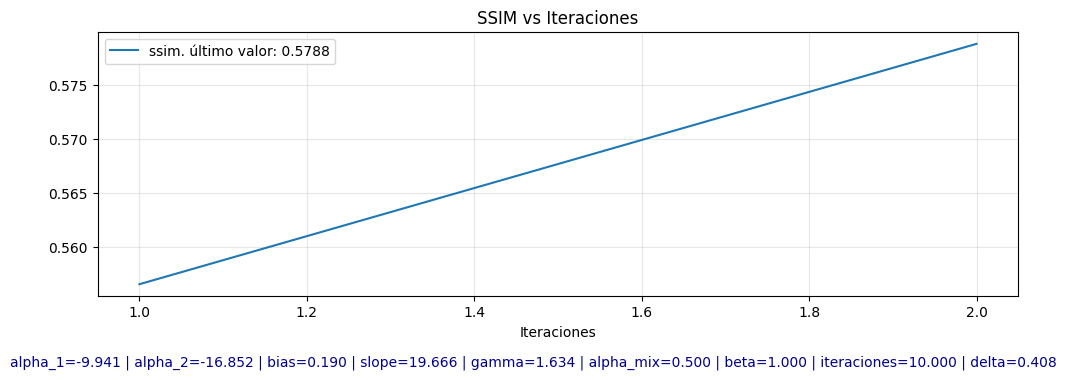

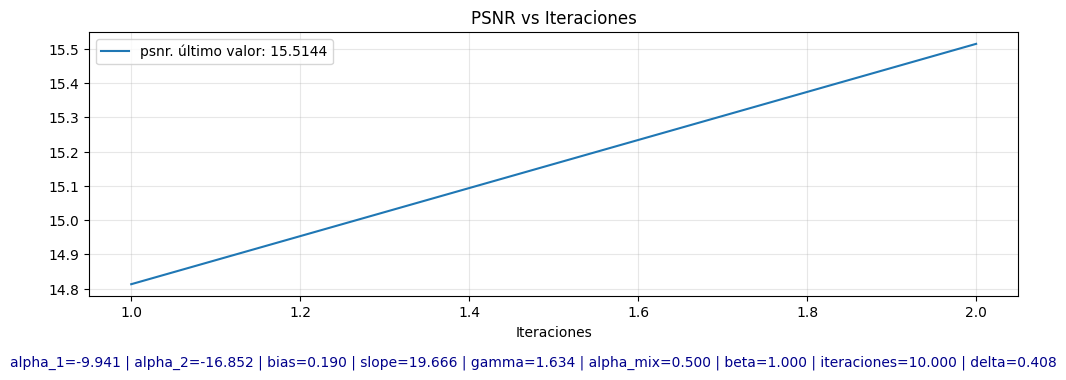


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.514  std:2.030
mask_bpsnr       : mean: 9.719  std:1.589
ssim             : mean: 0.579  std:0.091
acc_at_least_one : 0.893
acc_both         : 0.319

Run 20/20


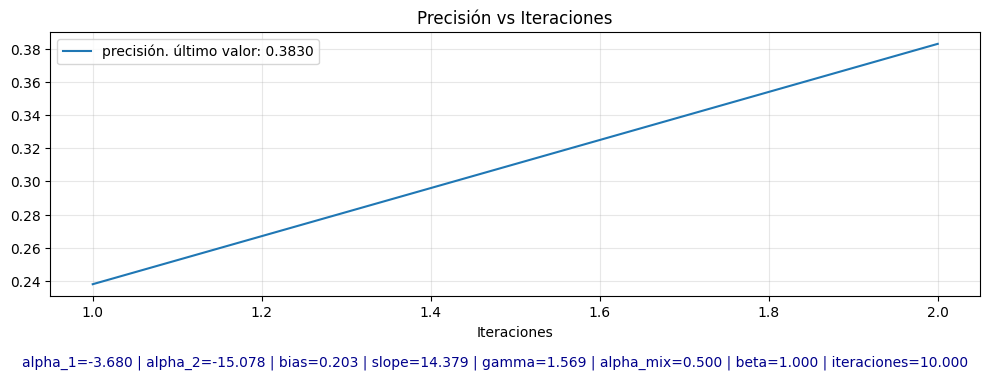

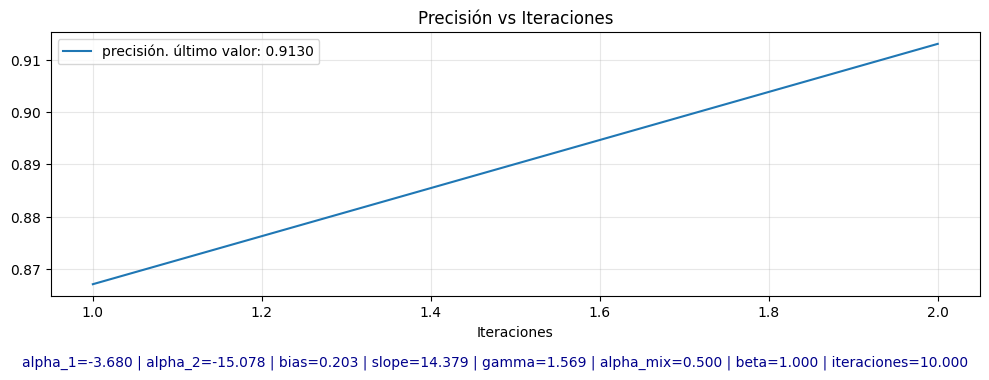

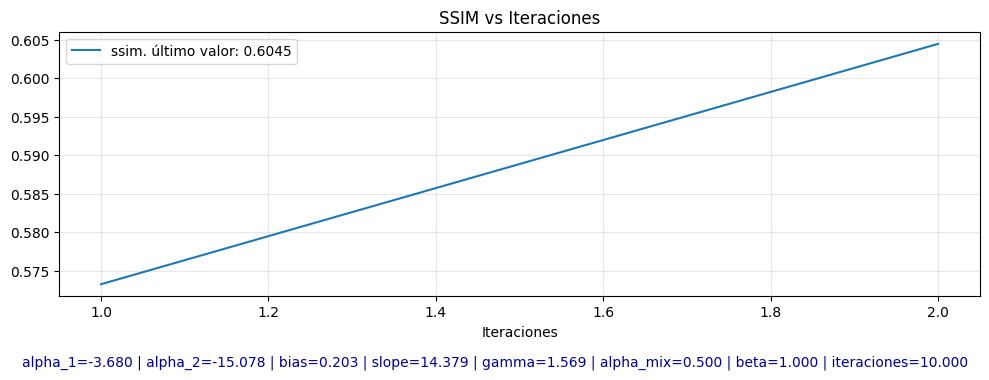

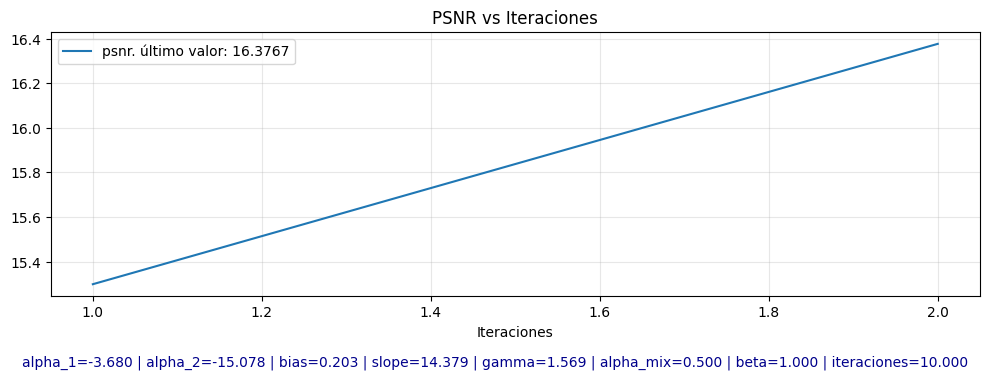


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.377  std:1.830
mask_bpsnr       : mean: 11.608  std:1.631
ssim             : mean: 0.604  std:0.086
acc_at_least_one : 0.913
acc_both         : 0.383



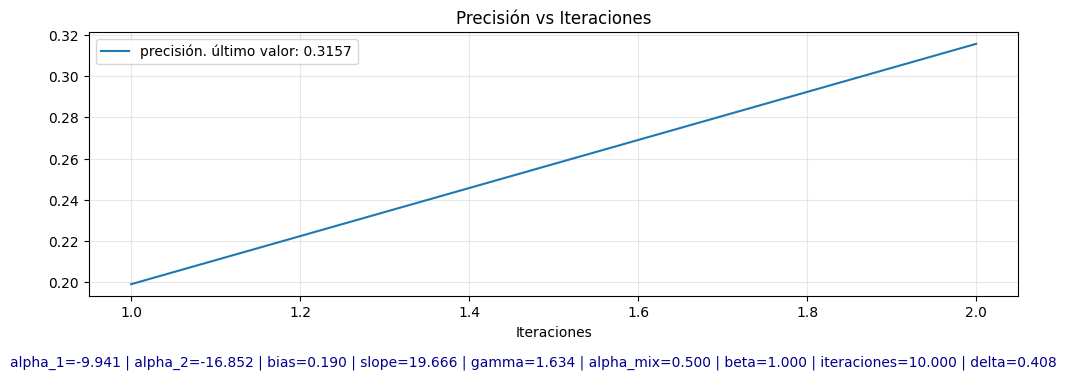

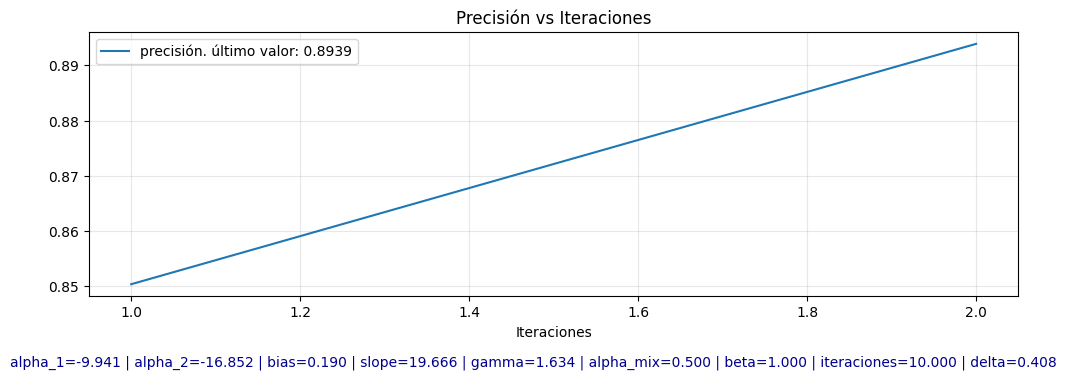

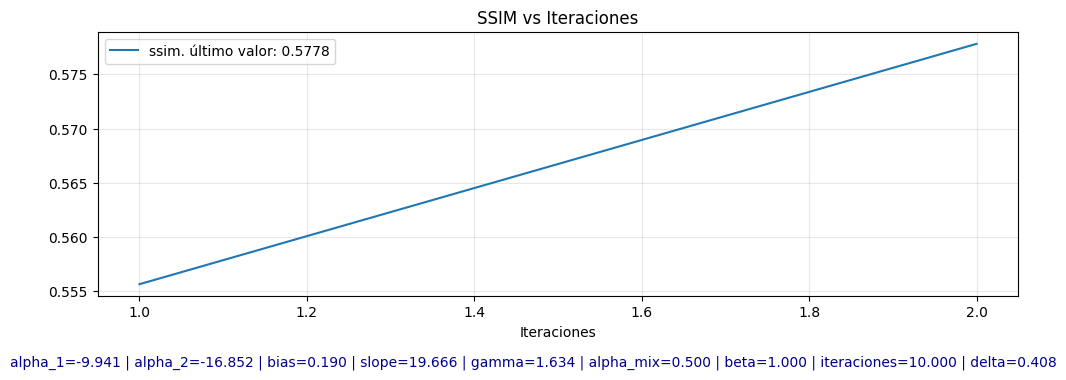

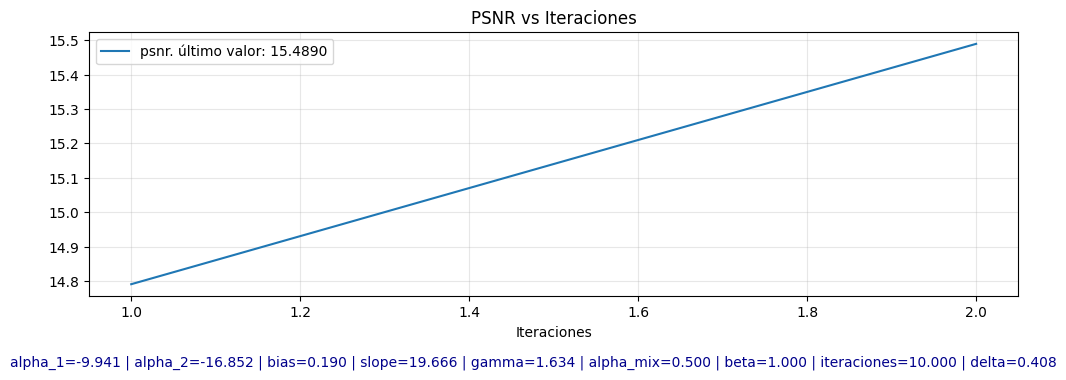


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.489  std:1.989
mask_bpsnr       : mean: 9.710  std:1.573
ssim             : mean: 0.578  std:0.089
acc_at_least_one : 0.894
acc_both         : 0.316



In [36]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random



DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 256

MNIST_PARAMS={'alpha_1': -1.061219644037281, 
        'alpha_2': -5.93265175032368, 
        'bias': 0.2181251530229756, 
        'slope': 12.884957541103851, 
        'gamma': 0.3294146902334417}

FASHION_PARAMS={'alpha_1': -0.19868397094671308, 
        'alpha_2': -13.487772584723764, 
        'bias': 0.2025587756051315, 
        'slope': 12.603926712541048, 
        'gamma': 1.348637346498534}
#optimizando ssim

FASHION_PARAMS_SSIM={'alpha_1': -3.67958442342705, 
        'alpha_2': -15.077895121548808, 
        'bias': 0.20255676463340044, 
        'slope': 14.379147657210677, 
        'gamma': 1.569064516257034}


MNIST_PARAMS_SSIM={'alpha_1': -1.9353908509805846, 
                   'alpha_2': -5.702371423422697,
                     'bias': 0.25485332997650295,
                       'slope': 18.19613632092573,
                         'gamma': 1.2494901799145723}
#--------------------------------------------------------

FASHION_PARAMS_CROP3={**FASHION_PARAMS, 'delta':  0.477}

cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

N_RUNS = 20
ITERATIONS=2

results_crop2 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}

results_crop3 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}

for run in range(N_RUNS):

    print(f"Run {run+1}/{N_RUNS}")

    # --------------------------
    # Randomización grupo 1
    # --------------------------
    idx0 = np.random.permutation(len(x_test))

    X0 = x_test[idx0][:N_PICTURES]
    Y0 = y_test[idx0][:N_PICTURES]

    # --------------------------
    # Randomización grupo 2
    # --------------------------
    idx1 = np.random.permutation(len(x_test_1))

    X1 = x_test_1[idx1][:N_PICTURES]
    Y1 = y_test_1[idx1][:N_PICTURES]

    # ==================================================
    # Crop2
    # ==================================================
    c2 = Crop2(
        cvae=cvae,
        predictor=predictor
    )

    metrics2 = c2.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        params=FASHION_PARAMS_SSIM,
        show_all_curves=True
    )

    results_crop2["acc"].append(metrics2["acc_both_plot"])
    results_crop2["ssim"].append(metrics2["ssim_plot"])
    results_crop2["psnr"].append(metrics2["psnr_plot"])

    # ==================================================
    # Crop3 Estimation Correction
    # ==================================================
    c3 = Crop3EstimationCorrection(
        cvae=cvae,
        predictor=predictor
    )

    metrics3 = c3.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        params={'alpha_1': -9.941125499313165, 'alpha_2': -16.852458549802762, 'bias': 0.18973246824243017, 'slope': 19.666498382269456, 'gamma': 1.6344295866300675, 'delta': 0.40844153736349087},
        #{'alpha_1': -1.0837446661347714, 'alpha_2': -9.488241278272092, 'bias': 0.1559648766444004, 'slope': 18.869899587059923, 'gamma': 1.3990861311565848, 'delta': 0.24497809943065196},
        show_all_curves=True
    )

    results_crop3["acc"].append(metrics3["acc_both_plot"])
    results_crop3["ssim"].append(metrics3["ssim_plot"])
    results_crop3["psnr"].append(metrics3["psnr_plot"])


# ======================================================
# Conversión a arrays
# ======================================================

for results in [results_crop2, results_crop3]:

    results["acc"] = np.asarray(results["acc"])
    results["ssim"] = np.asarray(results["ssim"])
    results["psnr"] = np.asarray(results["psnr"])

    results["mean_acc"] = results["acc"].mean(axis=0)
    results["std_acc"] = results["acc"].std(axis=0)

    results["mean_ssim"] = results["ssim"].mean(axis=0)
    results["std_ssim"] = results["ssim"].std(axis=0)

    results["mean_psnr"] = results["psnr"].mean(axis=0)
    results["std_psnr"] = results["psnr"].std(axis=0)




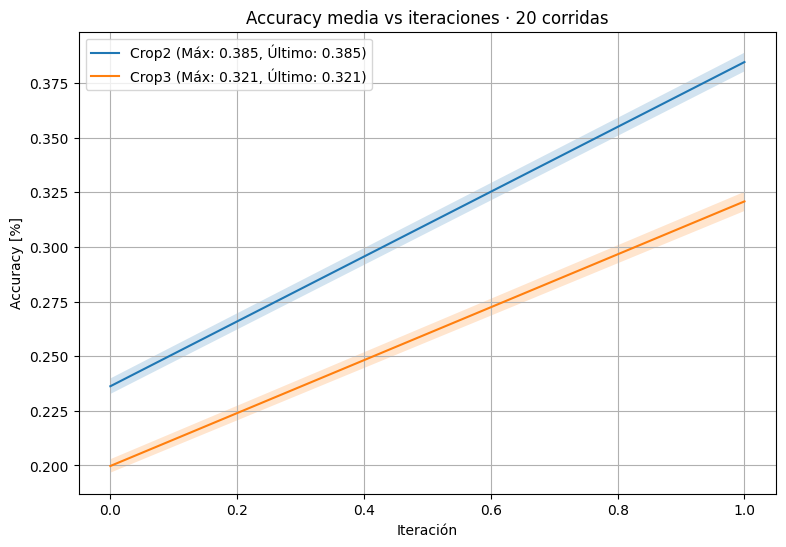

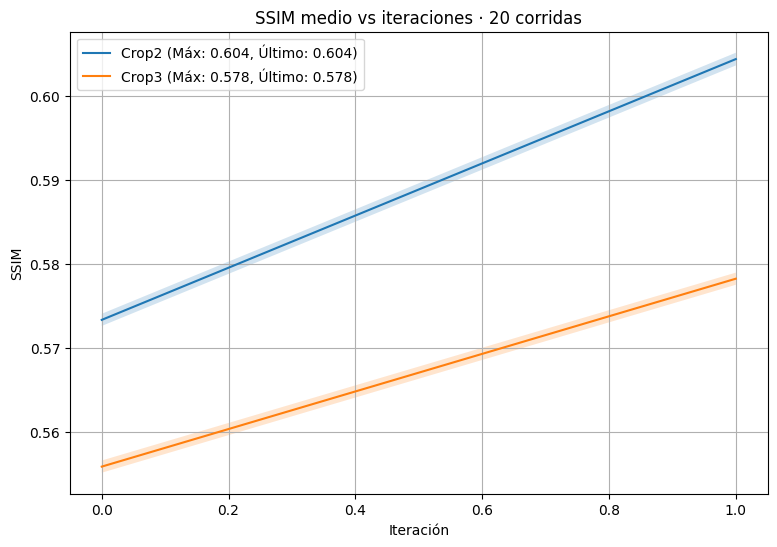

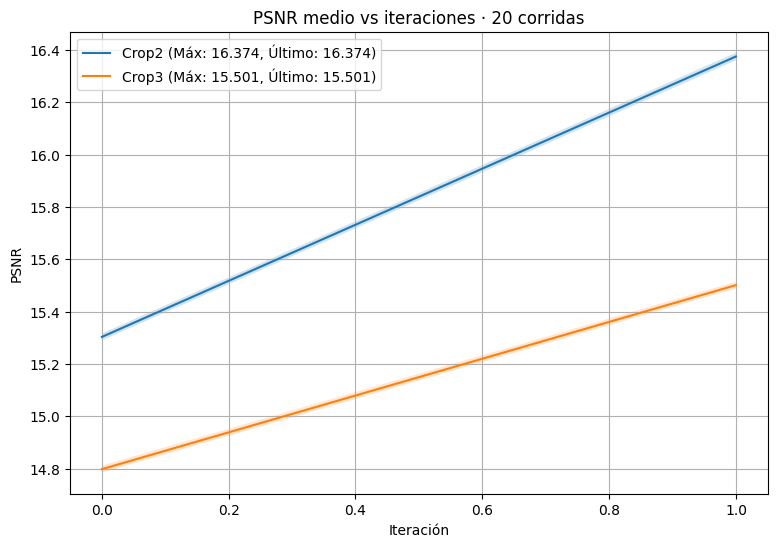

In [ ]:
plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    acc = results["mean_acc"]
    std = results["std_acc"]

    x = np.arange(len(acc))

    plt.plot(
        x,
        acc,
        label=f"{name} (Máx: {acc.max():.3f}, Último: {acc[-1]:.3f})"
    )

    plt.fill_between(
        x,
        acc - std,
        acc + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"Exactitud media vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("Exactitud [%]")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    ssim = results["mean_ssim"]
    std = results["std_ssim"]

    x = np.arange(len(ssim))

    plt.plot(
        x,
        ssim,
        label=f"{name} (Máx: {ssim.max():.3f}, Último: {ssim[-1]:.3f})"
    )

    plt.fill_between(
        x,
        ssim - std,
        ssim + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"SSIM medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    psnr = results["mean_psnr"]
    std = results["std_psnr"]

    x = np.arange(len(psnr))

    plt.plot(
        x,
        psnr,
        label=f"{name} (Máx: {psnr.max():.3f}, Último: {psnr[-1]:.3f})"
    )

    plt.fill_between(
        x,
        psnr - std,
        psnr + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"PSNR medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()